# Frequency-counter stability and frequency-noise analysis

K+K channels use one-based numbering: `channels: [1, 2]` selects the first two frequency columns. The frequency-noise plot is the amplitude spectral density (ASD) of linearly detrended frequency data, in Hz/$\sqrt{\mathrm{Hz}}$.

In [1]:
from pathlib import Path

import allantools
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch
# =============================================================================
# 0. Matplotlib基本设置
# =============================================================================
plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei',
    'Arial Unicode MS',
    'sans-serif'
]

plt.rcParams['axes.unicode_minus'] = False


def detect_notebook_directory(notebook_name='plot_allen_with_freq_counter.ipynb'):
    """Locate this notebook without depending on the Jupyter launch directory."""
    current_directory = Path.cwd().resolve()
    for parent in (current_directory, *current_directory.parents):
        for candidate in (parent / notebook_name, parent / 'frequency_counter' / notebook_name):
            if candidate.is_file():
                return candidate.parent.resolve()
    raise FileNotFoundError(
        f'Cannot locate {notebook_name!r} from {current_directory}. '
        'Start Jupyter from the project directory or one of its subdirectories.'
    )


def find_parent_directory(start_directory, directory_name):
    """Find a named synchronization root above start_directory."""
    start_directory = Path(start_directory).resolve()
    for candidate in (start_directory, *start_directory.parents):
        if candidate.name == directory_name:
            return candidate
    raise FileNotFoundError(
        f'Cannot find parent directory {directory_name!r} above {start_directory}'
    )


SCRIPT_DIR = detect_notebook_directory()
SYNC_ROOT = find_parent_directory(SCRIPT_DIR, 'USL_DLOCK')
FREQUENCY_COUNTER_DATA_ROOT = (
    SYNC_ROOT / '1.Data' / '杨正光上传' / '拍频数据' / '频率计数器'
)
print(f'Notebook directory: {SCRIPT_DIR}')

Notebook directory: C:\Users\WangYu\USTCDrive\USL_DLOCK\3.Code\PDH_data_process\frequency_counter


In [2]:
def load_frequency_channels(config):
    """Load the requested frequency channels from one counter data file.

    K+K format is: date, time, status/sync flag, channel 1, channel 2, ...
    Channel numbers in the configuration are one-based.
    """
    file_path = Path(config['file'])
    raw = np.loadtxt(file_path)
    data_format = config.get('format', 'single').lower()

    if data_format == 'kk':
        if raw.ndim != 2 or raw.shape[1] < 4:
            raise ValueError(f'{file_path} is not a valid K+K multi-channel file')
        channel_count = raw.shape[1] - 3
        requested = config.get('channels', list(range(1, channel_count + 1)))
        if not requested:
            raise ValueError('K+K channels cannot be empty')

        series = []
        for channel in requested:
            if not isinstance(channel, (int, np.integer)) or not 1 <= channel <= channel_count:
                raise ValueError(
                    f'K+K channel {channel!r} is invalid; available channels are 1..{channel_count}'
                )
            series.append({
                'channel': int(channel),
                'label': f"{config['label']} CH{channel}",
                'frequency': raw[:, channel + 2],
            })
        return series

    if data_format == 'single':
        if raw.ndim == 1:
            frequency = raw
        elif raw.ndim == 2:
            column = int(config.get('column', 1))
            if not 1 <= column <= raw.shape[1]:
                raise ValueError(f'Column {column} is outside 1..{raw.shape[1]}')
            frequency = raw[:, column - 1]
        else:
            raise ValueError(f'Unsupported data shape: {raw.shape}')
        return [{'channel': None, 'label': config['label'], 'frequency': frequency}]

    raise ValueError(f"Unknown data format: {config.get('format')!r}")


def crop_and_validate(frequency, lower=0.0, upper=1.0):
    frequency = np.asarray(frequency, dtype=float)
    if not 0.0 <= lower < upper <= 1.0:
        raise ValueError('Cut ratios must satisfy 0 <= lower < upper <= 1')
    start = int(len(frequency) * lower)
    stop = int(len(frequency) * upper)
    frequency = frequency[start:stop]
    if len(frequency) < 8:
        raise ValueError('At least 8 samples are required after cropping')
    if not np.all(np.isfinite(frequency)):
        raise ValueError('Frequency data contain NaN or infinite values')
    return frequency


def process_frequency_data(freq_raw, tau0, reference_frequency_hz):
    """Remove a linear drift and form optical fractional-frequency data."""
    if tau0 <= 0 or reference_frequency_hz <= 0:
        raise ValueError('tau0 and reference_frequency_hz must be positive')
    time_axis = np.arange(len(freq_raw), dtype=float) * tau0
    drift_params = np.polyfit(time_axis, freq_raw, 1)
    freq_drift = np.polyval(drift_params, time_axis)
    freq_detrended = freq_raw - freq_drift
    return {
        'time': time_axis,
        'freq_raw': freq_raw,
        'freq_drift': freq_drift,
        'freq_detrended': freq_detrended,
        'y_original': (freq_raw - np.mean(freq_raw)) / reference_frequency_hz,
        'y_detrended': freq_detrended / reference_frequency_hz,
        'drift_params': drift_params,
    }


DEVIATION_TYPES = {
    'adev': {
        'function': allantools.adev,
        'name': 'Allan deviation',
        'short_name': 'ADEV',
        'ylabel': r'Allan deviation $\sigma_y(\tau)$',
    },
    'mdev': {
        'function': allantools.mdev,
        'name': 'Modified Allan deviation',
        'short_name': 'MDEV',
        'ylabel': r'Modified Allan deviation $\sigma_y^{mod}(\tau)$',
    },
}


def calculate_allan_deviation(y_data, tau0, deviation_type='mdev'):
    deviation_type = str(deviation_type).lower()
    if deviation_type not in DEVIATION_TYPES:
        raise ValueError("deviation_type must be 'adev' or 'mdev'")
    function = DEVIATION_TYPES[deviation_type]['function']
    taus, deviation, errors, sample_counts = function(
        y_data, rate=1.0 / tau0, data_type='freq', taus='decade'
    )
    return taus, deviation, errors, sample_counts


def calculate_frequency_asd(freq_detrended, tau0, nperseg=4096):
    """Welch frequency-noise ASD in Hz/sqrt(Hz), excluding the DC bin."""
    segment_length = min(int(nperseg), len(freq_detrended))
    if segment_length < 8:
        raise ValueError('PSD segment length must be at least 8 samples')
    frequencies, psd = welch(
        freq_detrended,
        fs=1.0 / tau0,
        window='hann',
        nperseg=segment_length,
        noverlap=segment_length // 2,
        detrend='constant',
        scaling='density',
    )
    positive = frequencies > 0
    return frequencies[positive], np.sqrt(psd[positive]), segment_length


def plot_time_domain(processed, label, color):
    time = processed['time']
    slope = processed['drift_params'][0]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), dpi=150, sharex=True)
    ax1.plot(time, processed['freq_raw'], color=color, alpha=0.65, label='Original data')
    ax1.plot(time, processed['freq_drift'], 'k--', linewidth=1.5,
             label=f'Linear drift: {slope:.4e} Hz/s')
    ax1.set_ylabel('Frequency (Hz)')
    ax1.set_title(f'Frequency vs time: {label}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.plot(time, processed['freq_detrended'], color=color, label='Linearly detrended')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel(r'$\Delta f$ (Hz)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    fig.tight_layout()


def plot_allan_deviation_comparison(results, title, deviation_type):
    info = DEVIATION_TYPES[deviation_type]
    fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
    for result in results:
        deviation = result['deviation']
        label = result['label']
        color = result['color']
        index = np.argmin(np.abs(deviation['tau_detrended'] - 1.0))
        tau = deviation['tau_detrended'][index]
        value = deviation['detrended'][index]
        ax.loglog(deviation['tau_raw'], deviation['raw'], 'd--', color=color, alpha=0.45,
                  linewidth=1.5, label=f'{label} (raw)')
        ax.loglog(
            deviation['tau_detrended'], deviation['detrended'], 'd-', color=color,
            markersize=4, linewidth=1.8,
            label=f"{label} (detrended, {tau:g} s {info['short_name']}={value:.2e})",
        )
        ax.plot(tau, value, 'o', color=color, markersize=7)
    ax.set_xlabel(r'Averaging time $\tau$ (s)')
    ax.set_ylabel(info['ylabel'])
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()


def plot_frequency_asd(results, title):
    fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
    for result in results:
        ax.loglog(result['asd']['frequency'], result['asd']['value'],
                  color=result['color'], linewidth=1.5, label=result['label'])
    ax.set_xlabel('Fourier frequency (Hz)')
    ax.set_ylabel(r'Frequency-noise ASD (Hz/$\sqrt{\mathrm{Hz}}$)')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
    fig.tight_layout()


def run_frequency_counter_analysis(
    data_configs,
    plot_title,
    optical_reference_hz=None,
    wavelength_nm=None,
    deviation_type='mdev',
    show_plots=True,
):
    """Run loading, channel analysis, ADEV/MDEV, ASD and plotting.

    Every config['file'] must be an absolute path. If a directory and file
    name are stored separately, join them in the calling cell before calling
    this function.
    Supply optical_reference_hz directly, or supply wavelength_nm and let
    the function calculate c / wavelength. If both are supplied, they must
    describe the same optical reference frequency.
    """
    deviation_type = str(deviation_type).lower()
    if deviation_type not in DEVIATION_TYPES:
        raise ValueError("deviation_type must be 'adev' or 'mdev'")
    deviation_info = DEVIATION_TYPES[deviation_type]
    if optical_reference_hz is None:
        if wavelength_nm is None:
            raise ValueError('Provide optical_reference_hz or wavelength_nm')
        optical_reference_hz = 299792458.0 / (float(wavelength_nm) * 1e-9)
    else:
        optical_reference_hz = float(optical_reference_hz)
        if wavelength_nm is not None:
            frequency_from_wavelength = 299792458.0 / (float(wavelength_nm) * 1e-9)
            if not np.isclose(optical_reference_hz, frequency_from_wavelength, rtol=1e-12):
                print('optical_reference_hz and wavelength_nm are inconsistent')
    if optical_reference_hz <= 0:
        raise ValueError('optical_reference_hz must be positive')

    results = []
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for input_config in data_configs:
        if not input_config.get('enabled', True):
            continue

        config = dict(input_config)
        file_path = Path(config['file']).expanduser()
        if not file_path.is_absolute():
            raise ValueError(
                f"config['file'] must be an absolute path, got: {file_path}. "
                "Join DATA_DIR and the file name in the calling cell first."
            )
        file_path = file_path.resolve()
        if not file_path.is_file():
            raise FileNotFoundError(f'Frequency-counter data file not found: {file_path}')
        config['file'] = file_path
        tau0 = float(config['tau'])
        loaded_series = load_frequency_channels(config)
        colors = config.get('colors', default_colors)
        if not colors:
            raise ValueError(f"No plotting colors configured for {config['label']}")

        for series_index, series in enumerate(loaded_series):
            frequency = crop_and_validate(
                series['frequency'],
                config.get('cut_ratio_lower', 0.0),
                config.get('cut_ratio_upper', 1.0),
            )
            color = colors[series_index % len(colors)]
            processed = process_frequency_data(frequency, tau0, optical_reference_hz)
            tau_raw, deviation_raw, error_raw, count_raw = calculate_allan_deviation(
                processed['y_original'], tau0, deviation_type
            )
            tau_detr, deviation_detr, error_detr, count_detr = calculate_allan_deviation(
                processed['y_detrended'], tau0, deviation_type
            )
            asd_frequency, asd_value, actual_nperseg = calculate_frequency_asd(
                processed['freq_detrended'], tau0, config.get('psd_nperseg', 4096)
            )
            result = {
                'label': series['label'],
                'channel': series['channel'],
                'color': color,
                'config': config,
                'processed': processed,
                'deviation_type': deviation_type,
                'deviation': {
                    'tau_raw': tau_raw, 'raw': deviation_raw,
                    'error_raw': error_raw, 'count_raw': count_raw,
                    'tau_detrended': tau_detr, 'detrended': deviation_detr,
                    'error_detrended': error_detr, 'count_detrended': count_detr,
                },
                'asd': {
                    'frequency': asd_frequency, 'value': asd_value,
                    'nperseg': actual_nperseg,
                },
            }
            # Keep result['adev'] or result['mdev'] as a convenient compatibility alias.
            result[deviation_type] = result['deviation']
            results.append(result)
            one_second_index = np.argmin(np.abs(tau_detr - 1.0))
            print(
                f"{series['label']}: {len(frequency)} points, "
                f"tau={tau0:g} s, {deviation_info['short_name']}"
                f"({tau_detr[one_second_index]:g} s)="
                f"{deviation_detr[one_second_index]:.3e}, PSD nperseg={actual_nperseg}"
            )
            plot_time_domain(processed, series['label'], color)

    if results:
        plot_allan_deviation_comparison(
            results, f"{plot_title}: {deviation_info['name']}", deviation_type
        )
        plot_frequency_asd(
            results, f'{plot_title}: frequency-noise amplitude spectral density'
        )
        if show_plots:
            plt.show()
    return results

K+K CH1: 69664 points, tau=0.01 s, MDEV(1 s)=1.359e-15, PSD nperseg=4096
Keysight: 60117 points, tau=0.01 s, MDEV(1 s)=5.507e-15, PSD nperseg=4096


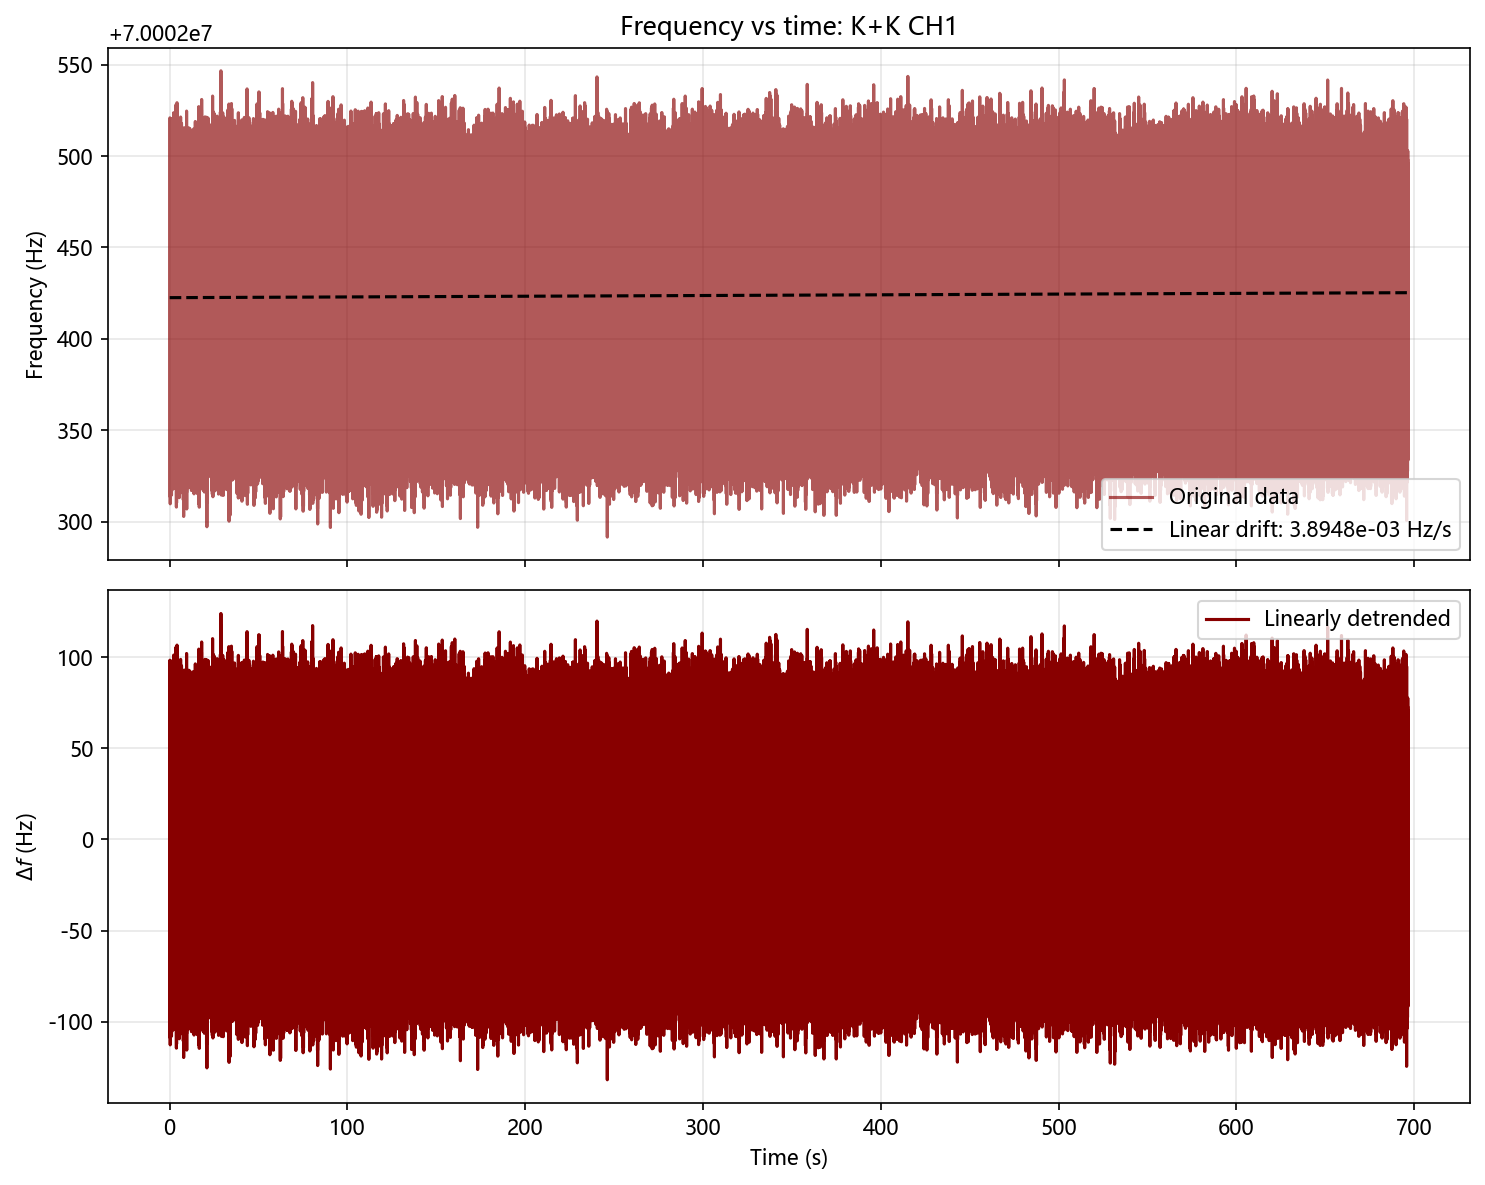

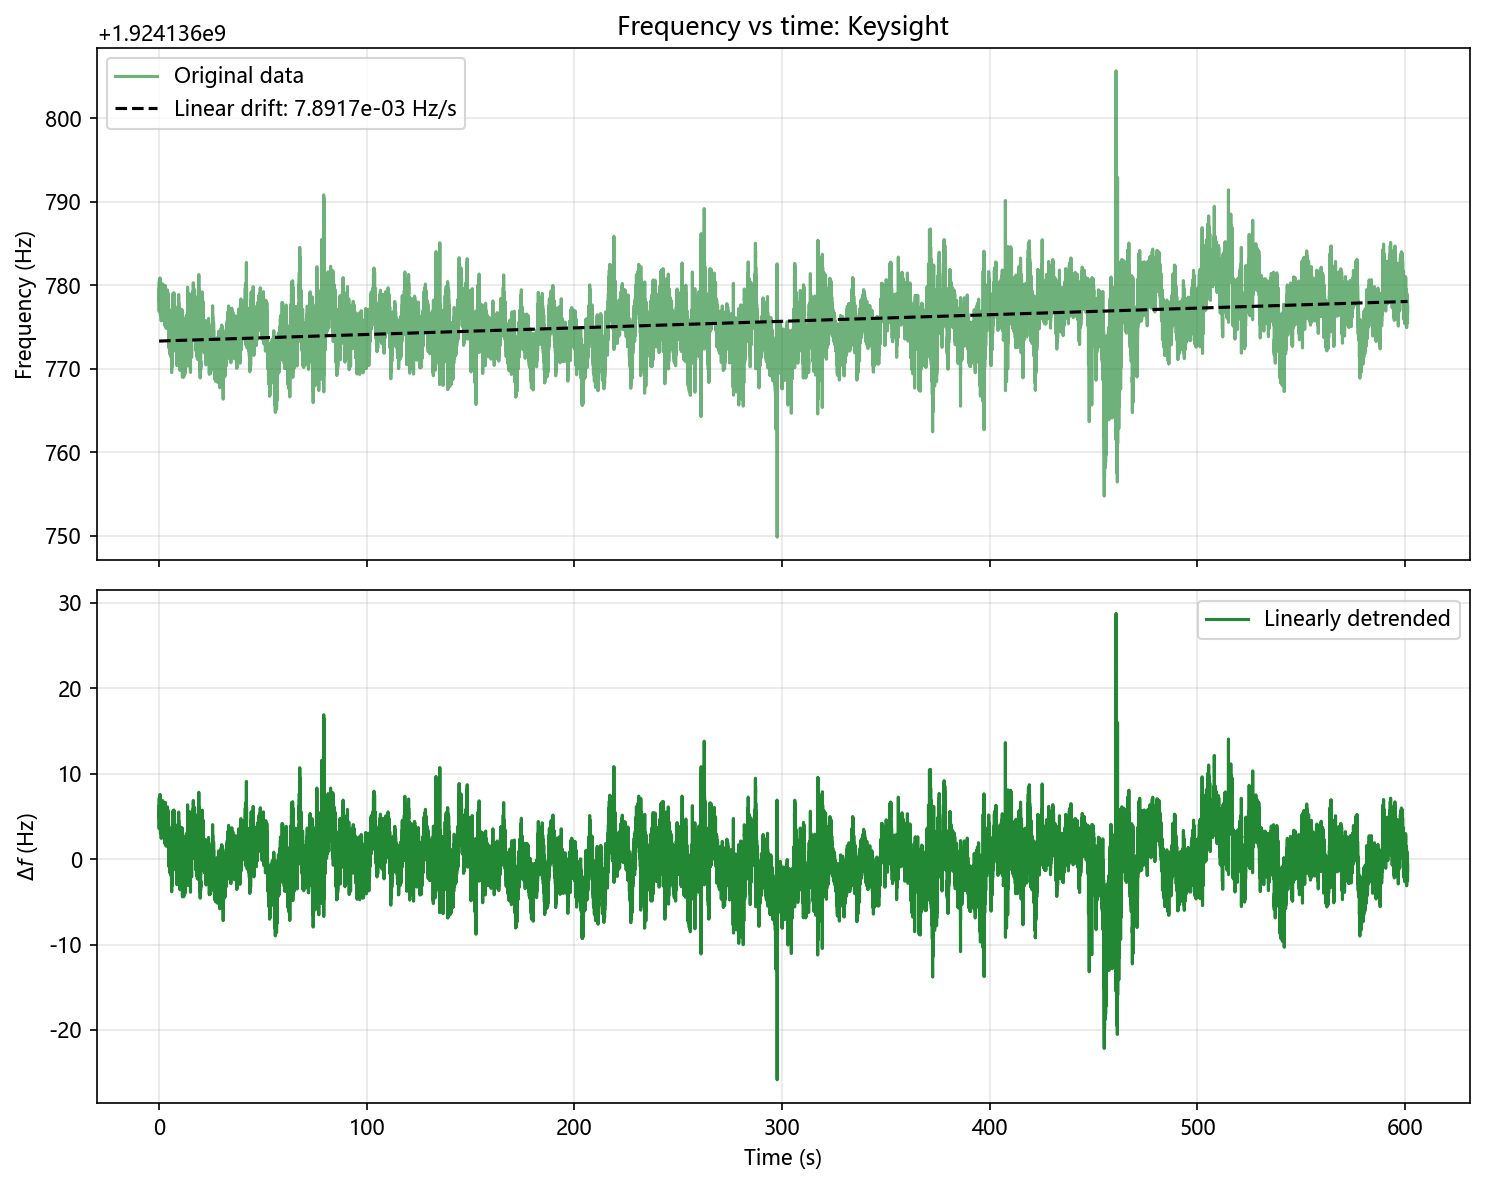

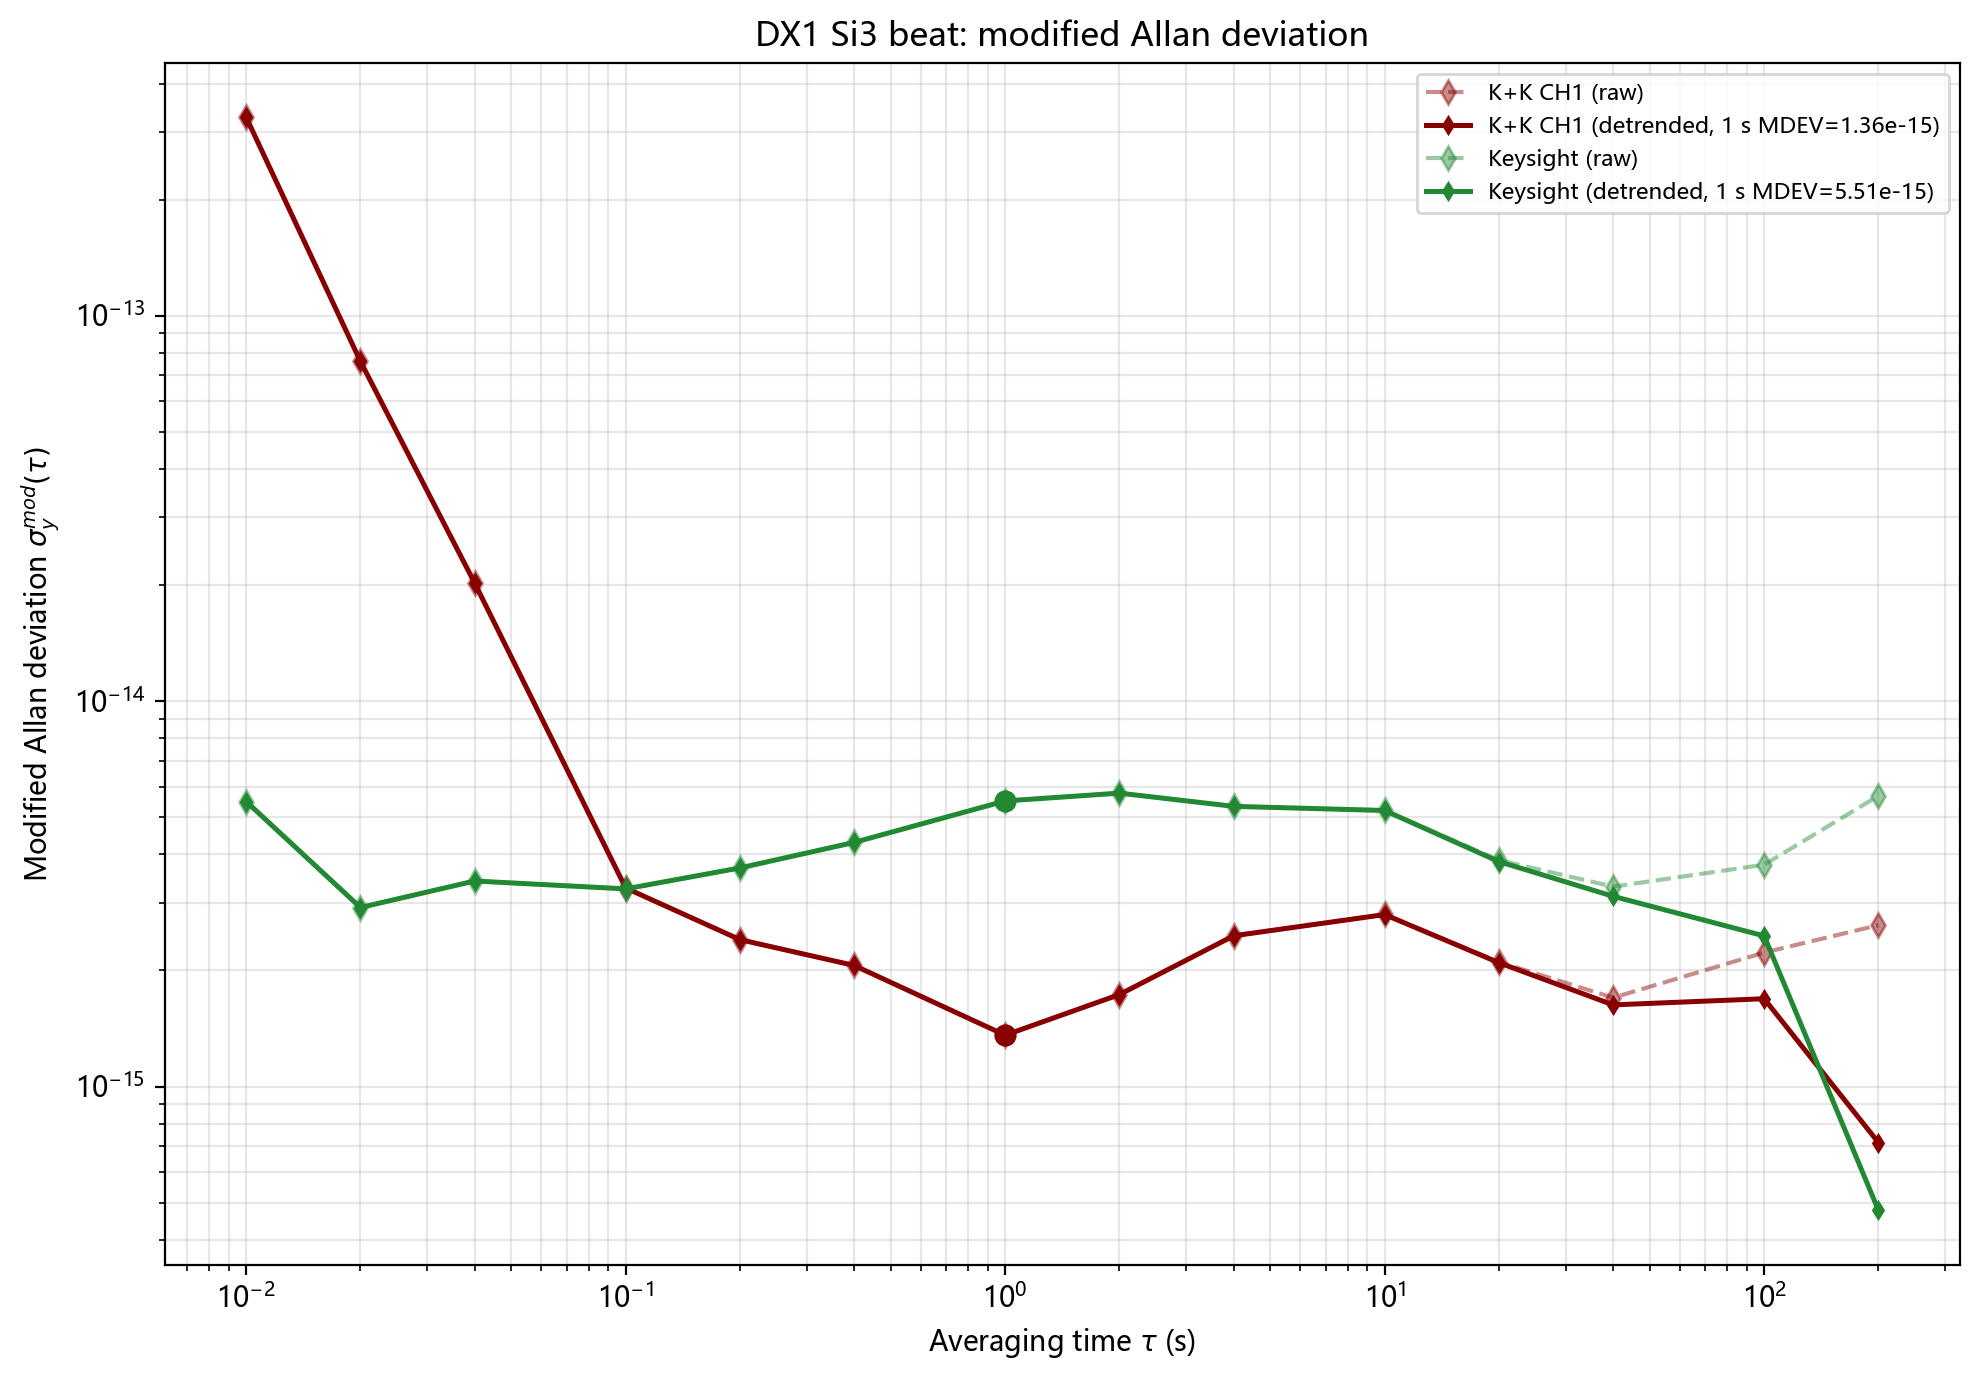

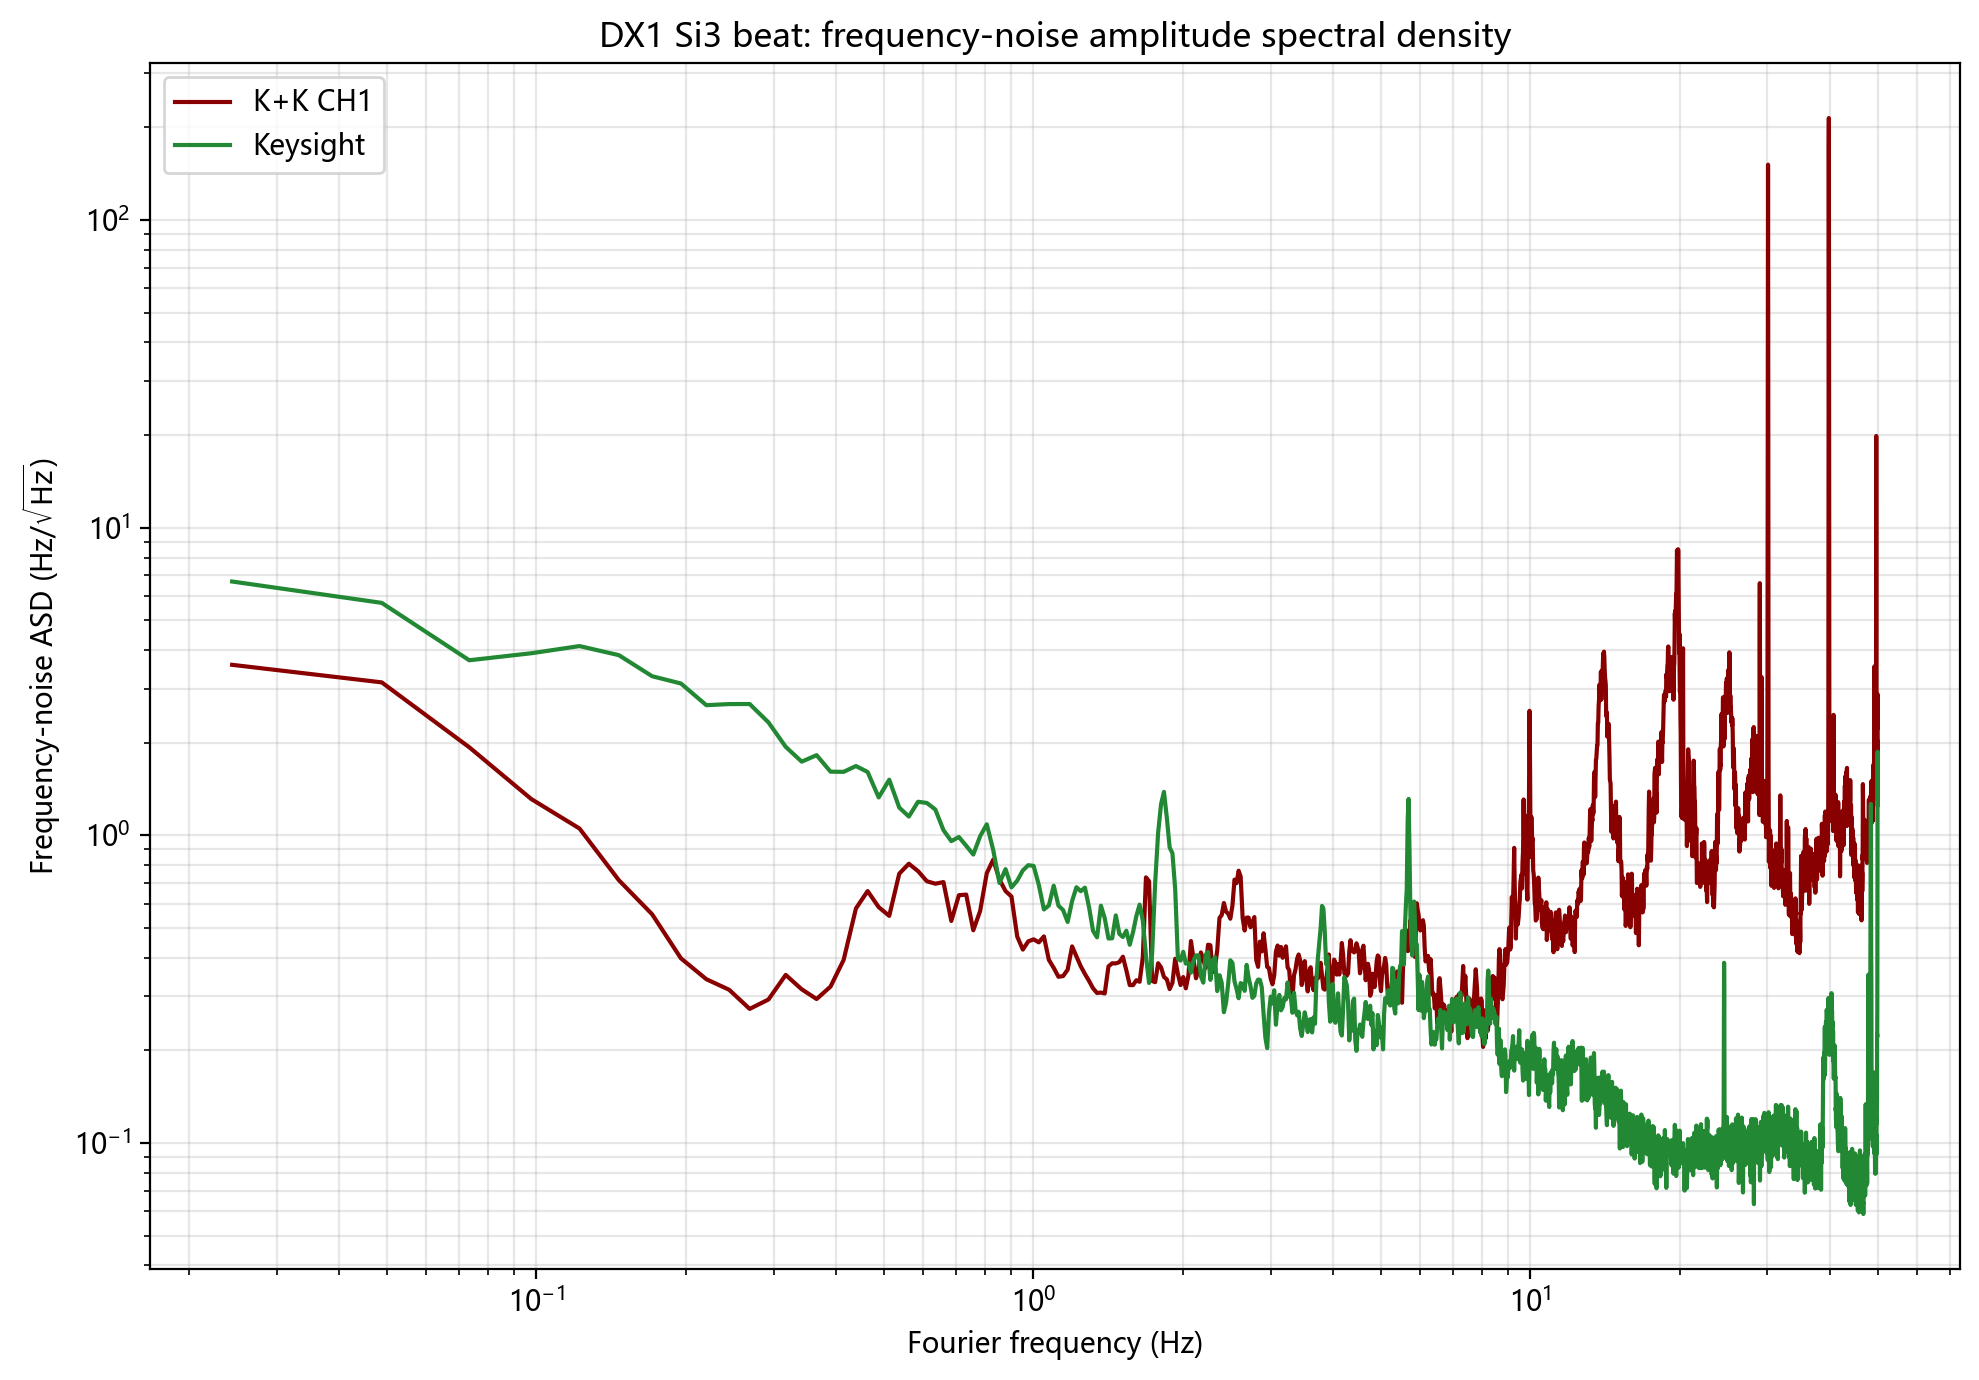

In [10]:
# Only this cell needs to be edited when analyzing new files.
DATA_DIR = (SCRIPT_DIR / 'data').resolve()
wavelength_nm = 1397.0

wavelength_nm = 1397.0
optical_reference_hz = 299792458.0 / (wavelength_nm * 1e-9)
plot_title = 'DX1 Si3 beat'
deviation_type = 'mdev'  # Choose 'adev' or 'mdev'.

data_configs = [
    {
        'file': DATA_DIR / 'Freq_A_1_260710_Si3_DX1.txt',
        'format': 'kk',
        'channels': [1],  # Use [1, 2] to analyze both K+K channels.
        'label': 'K+K',
        'colors': ['#880000', '#004488'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    {
        'file': DATA_DIR / '20260429——电1电2拍频，采样率100Hz.csv',
        'format': 'single',
        'label': 'Keysight',
        'colors': ['#228833'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
]

results = run_frequency_counter_analysis(
    data_configs=data_configs,
    plot_title=plot_title,
    optical_reference_hz=optical_reference_hz,
    wavelength_nm=wavelength_nm,
    deviation_type=deviation_type,
)

2026-07-14 22:38:11 - 2026-07-15 00:42:32 CH1: 746226 points, tau=0.01 s, MDEV(1 s)=8.401e-16, PSD nperseg=4096
2026-07-15 00:43:46 - 2026-07-15 01:03:37 CH1: 119119 points, tau=0.01 s, MDEV(1 s)=8.015e-16, PSD nperseg=4096
2026-07-15 01:03:37 - 2026-07-15 06:47:46 CH1: 2064889 points, tau=0.01 s, MDEV(1 s)=7.443e-16, PSD nperseg=4096


C:\Users\WangYu\AppData\Local\Temp\ipykernel_34788\2334418168.py:121: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


2026-07-15 06:47:46 - 2026-07-15 09:11:46 CH1: 691163 points, tau=0.01 s, MDEV(1 s)=7.612e-16, PSD nperseg=4096


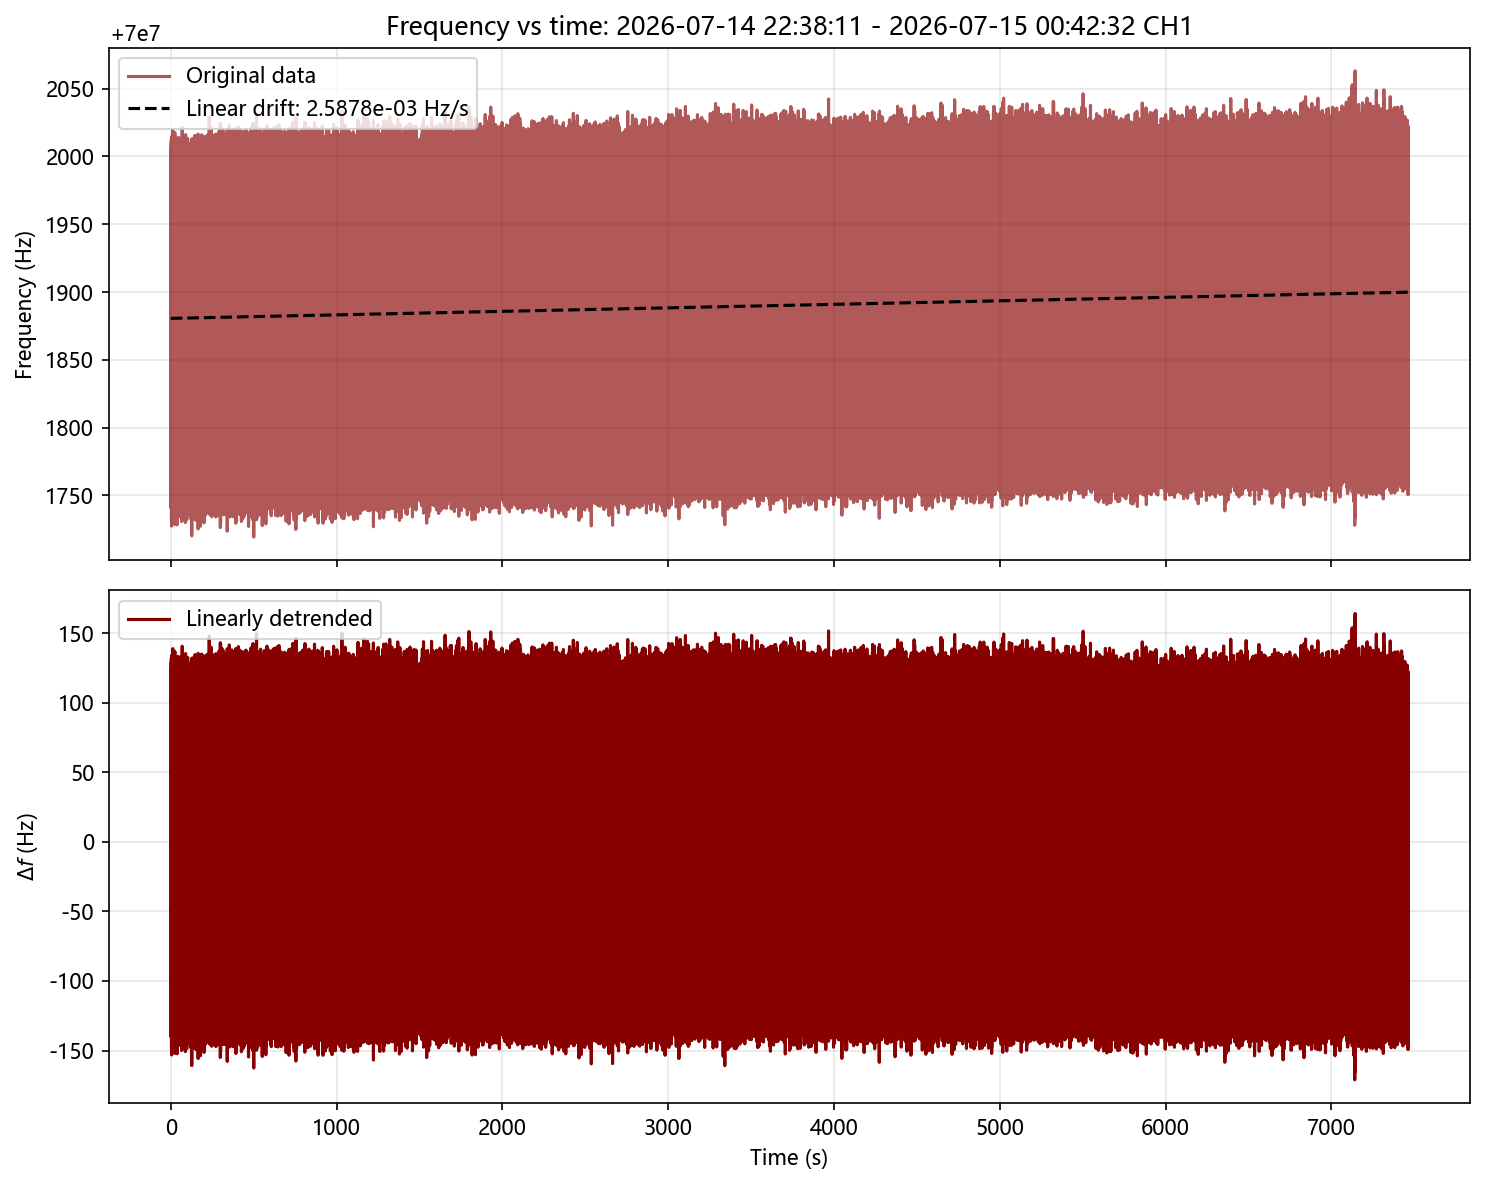

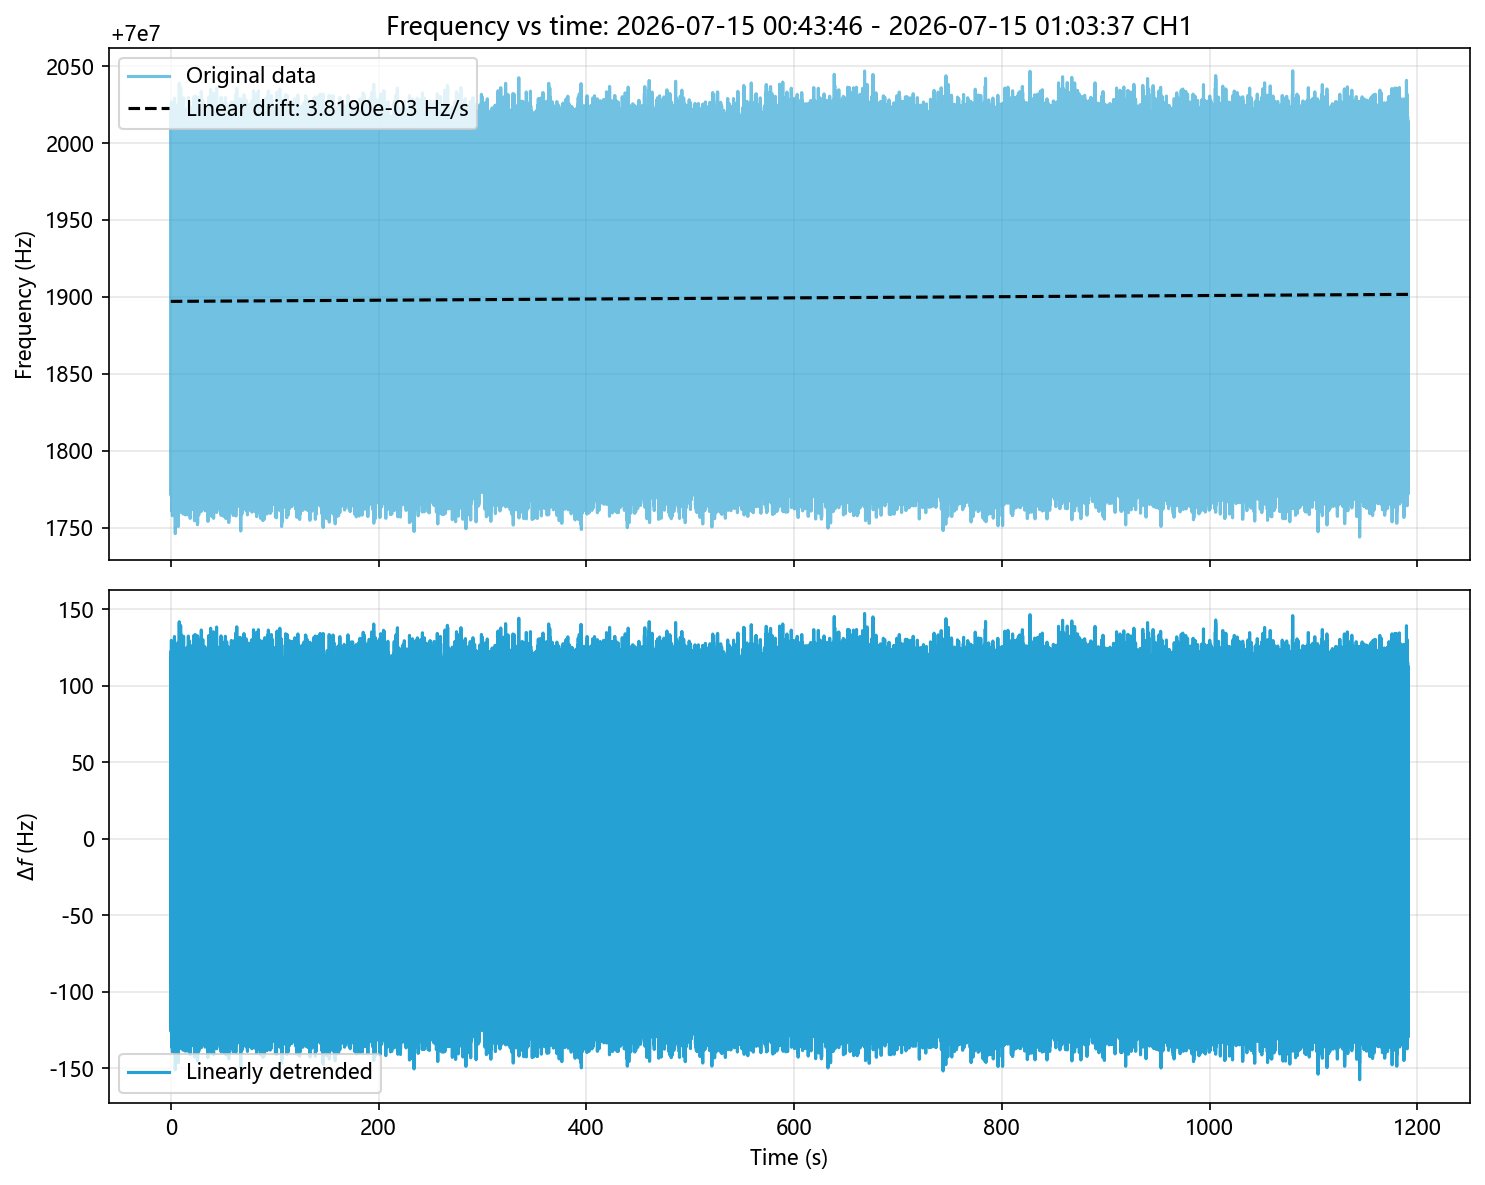

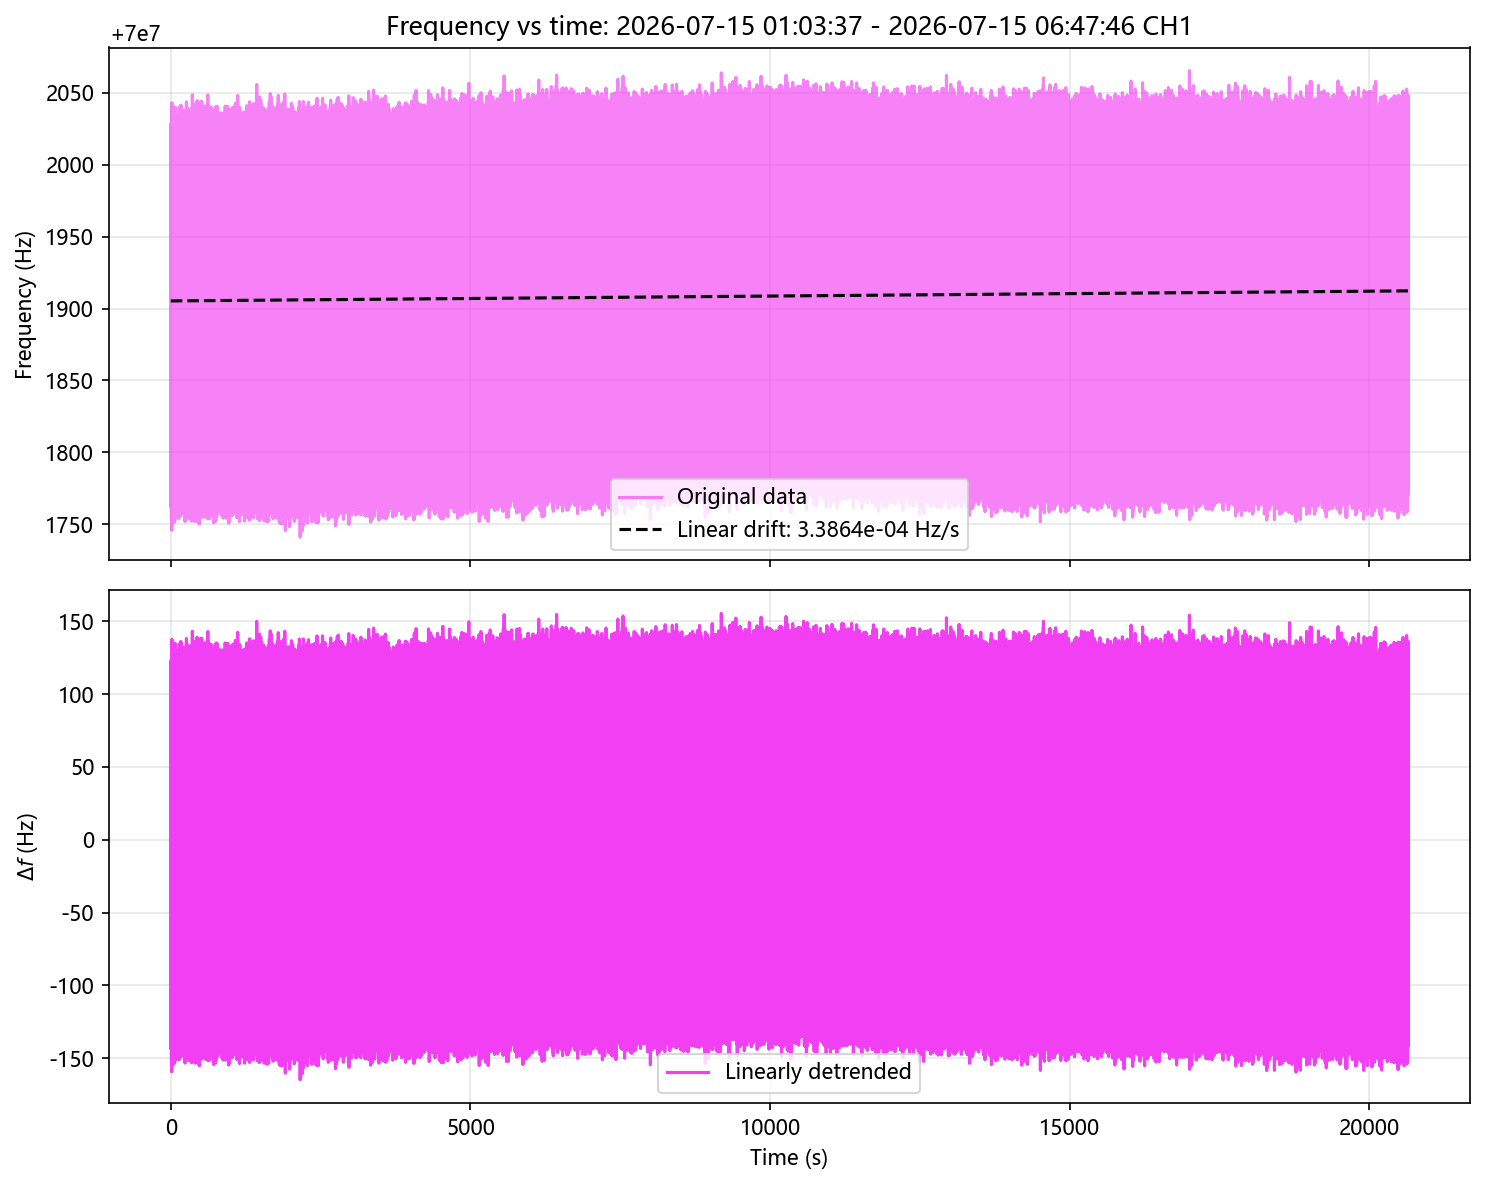

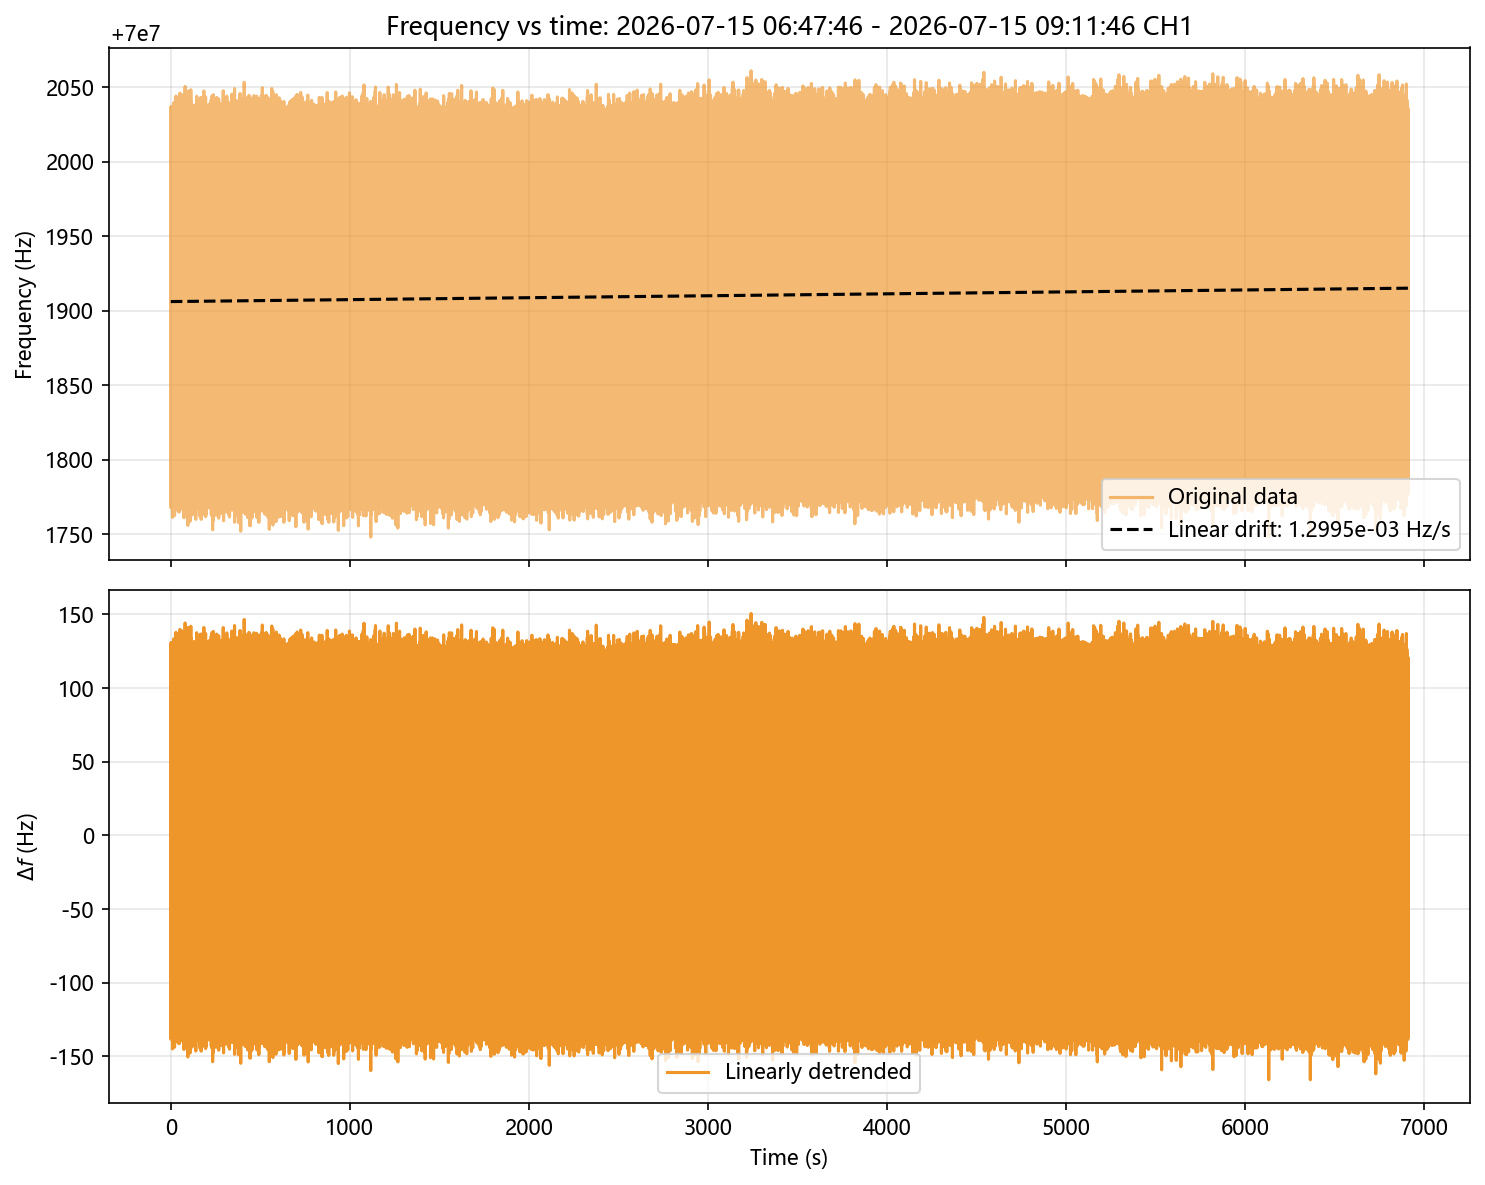

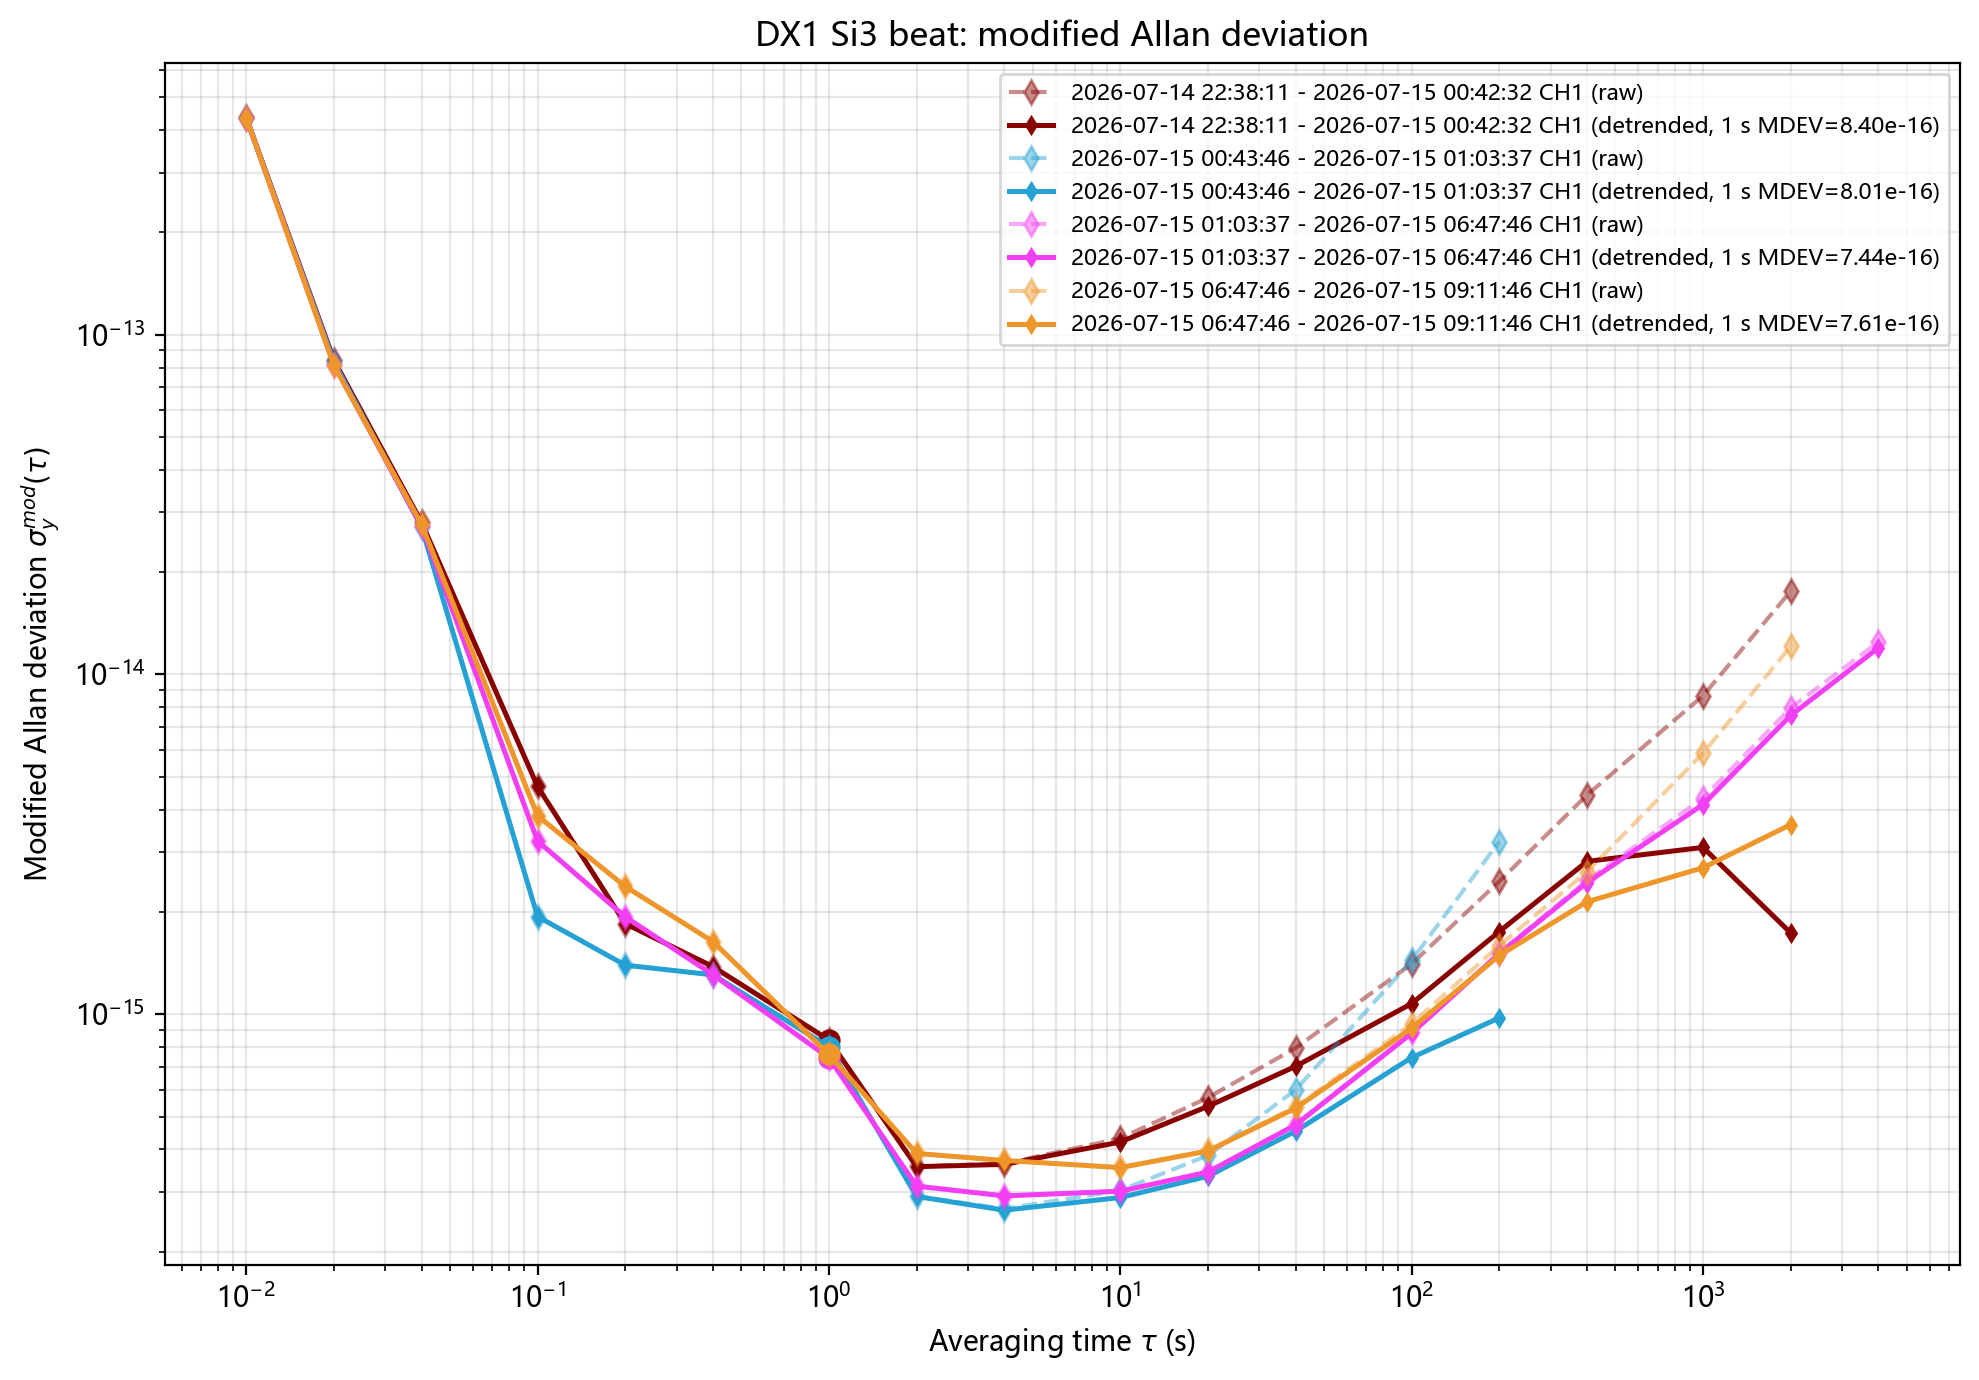

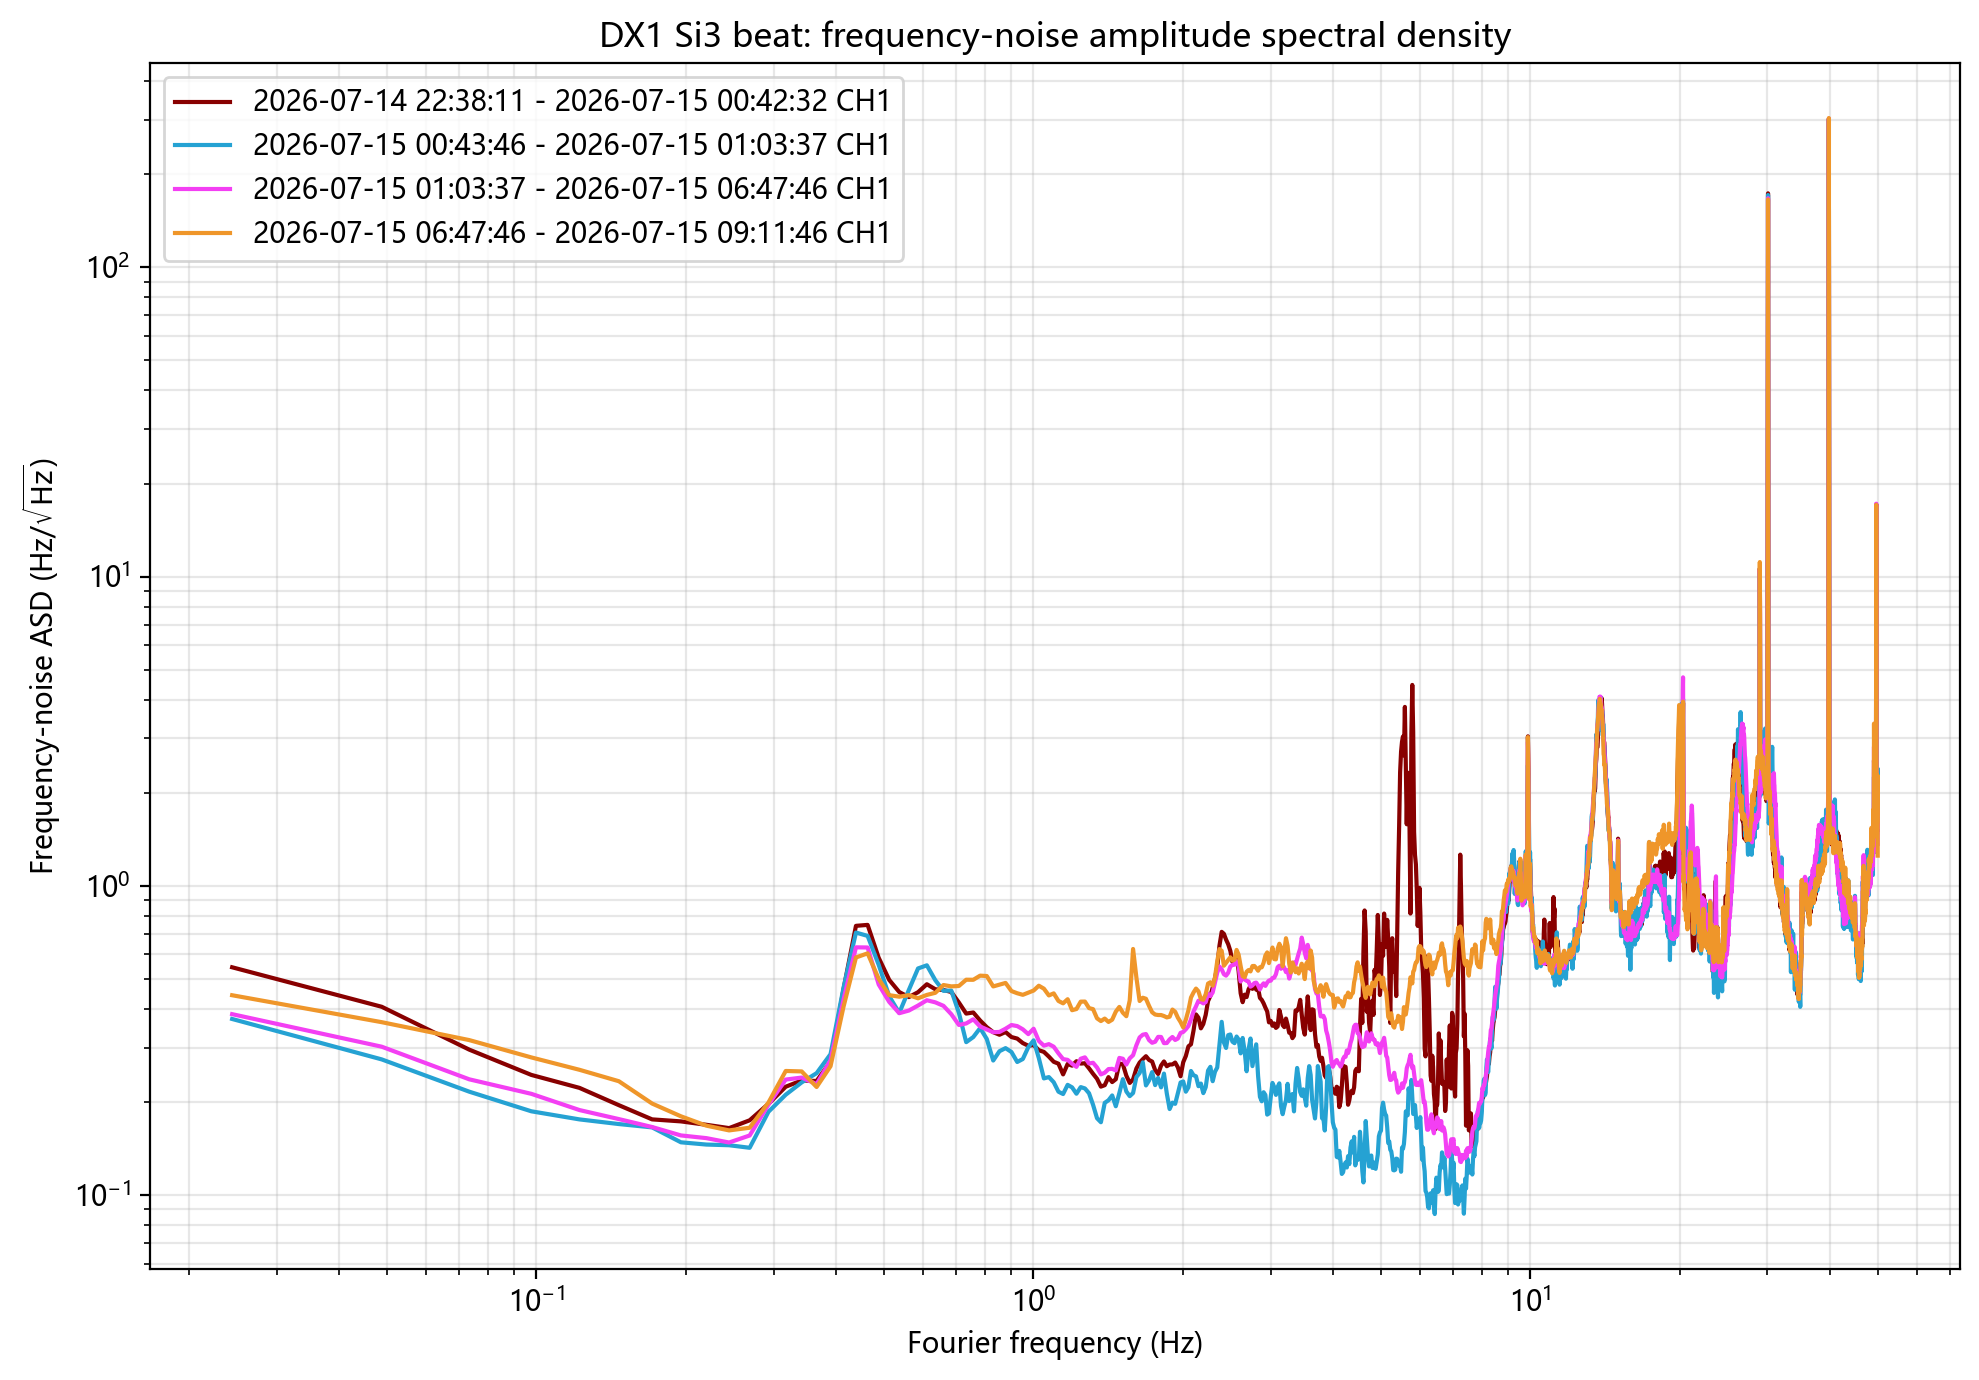

In [15]:
# Only this cell needs to be edited when analyzing new files.
DATA_DIR = FREQUENCY_COUNTER_DATA_ROOT / '20260714-15DX1_Si3_beat'
wavelength_nm = 1397.0
optical_reference_hz = 299792458.0 / (wavelength_nm * 1e-9)
plot_title = 'DX1 Si3 beat'
deviation_type = 'mdev'  # Choose 'adev' or 'mdev'.

data_configs = [
    {
        'file': DATA_DIR / 'Freq_A_1_260714_5.txt',
        'format': 'kk',
        'channels': [1],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-14 22:38:11 - 2026-07-15 00:42:32',
        'colors': ['#880000', '#004488'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    # {
    #     'file': DATA_DIR / 'Freq_A_1_260714_6.txt',
    #     'format': 'kk',
    #     'channels': [1],  # Use [1, 2] to analyze both K+K channels.
    #     'label': '2026-07-15 00:42:35 - 2026-07-15 00:42:38',
    #     'colors': ["#1D0088", '#004488'],
    #     'tau': 0.01,
    #     'cut_ratio_lower': 0.0,
    #     'cut_ratio_upper': 1.0,
    #     'psd_nperseg': 4096,
    # },
    {
        'file': DATA_DIR / 'Freq_A_1_260714_7.txt',
        'format': 'kk',
        'channels': [1],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-15 00:43:46 - 2026-07-15 01:03:37',
        'colors': ["#25A2D3", '#004488'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    {
        'file': DATA_DIR / 'Freq_A_1_260715_1.txt',
        'format': 'kk',
        'channels': [1],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-15 01:03:37 - 2026-07-15 06:47:46',
        'colors': ["#F33FF3", '#004488'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    {
        'file': DATA_DIR / 'Freq_A_1_260715_2.txt',
        'format': 'kk',
        'channels': [1],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-15 06:47:46 - 2026-07-15 09:11:46',
        'colors': ["#EF962A", '#004488'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 0.8,
        'psd_nperseg': 4096,
    }
]

results = run_frequency_counter_analysis(
    data_configs=data_configs,
    plot_title=plot_title,
    optical_reference_hz=optical_reference_hz,
    wavelength_nm=wavelength_nm,
    deviation_type=deviation_type,
)

2026-07-14 22:38:21 - 2026-07-15 00:00:00 CH1: 489850 points, tau=0.01 s, ADEV(1 s)=1.306e-17, PSD nperseg=4096
2026-07-15 00:00:00 - 2026-07-15 05:44:08 CH1: 2064889 points, tau=0.01 s, ADEV(1 s)=1.277e-17, PSD nperseg=4096


C:\Users\WangYu\AppData\Local\Temp\ipykernel_19644\2689313365.py:141: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


2026-07-15 05:44:08 - 2026-07-15 11:06:52 CH1: 1355467 points, tau=0.01 s, ADEV(1 s)=1.287e-17, PSD nperseg=4096


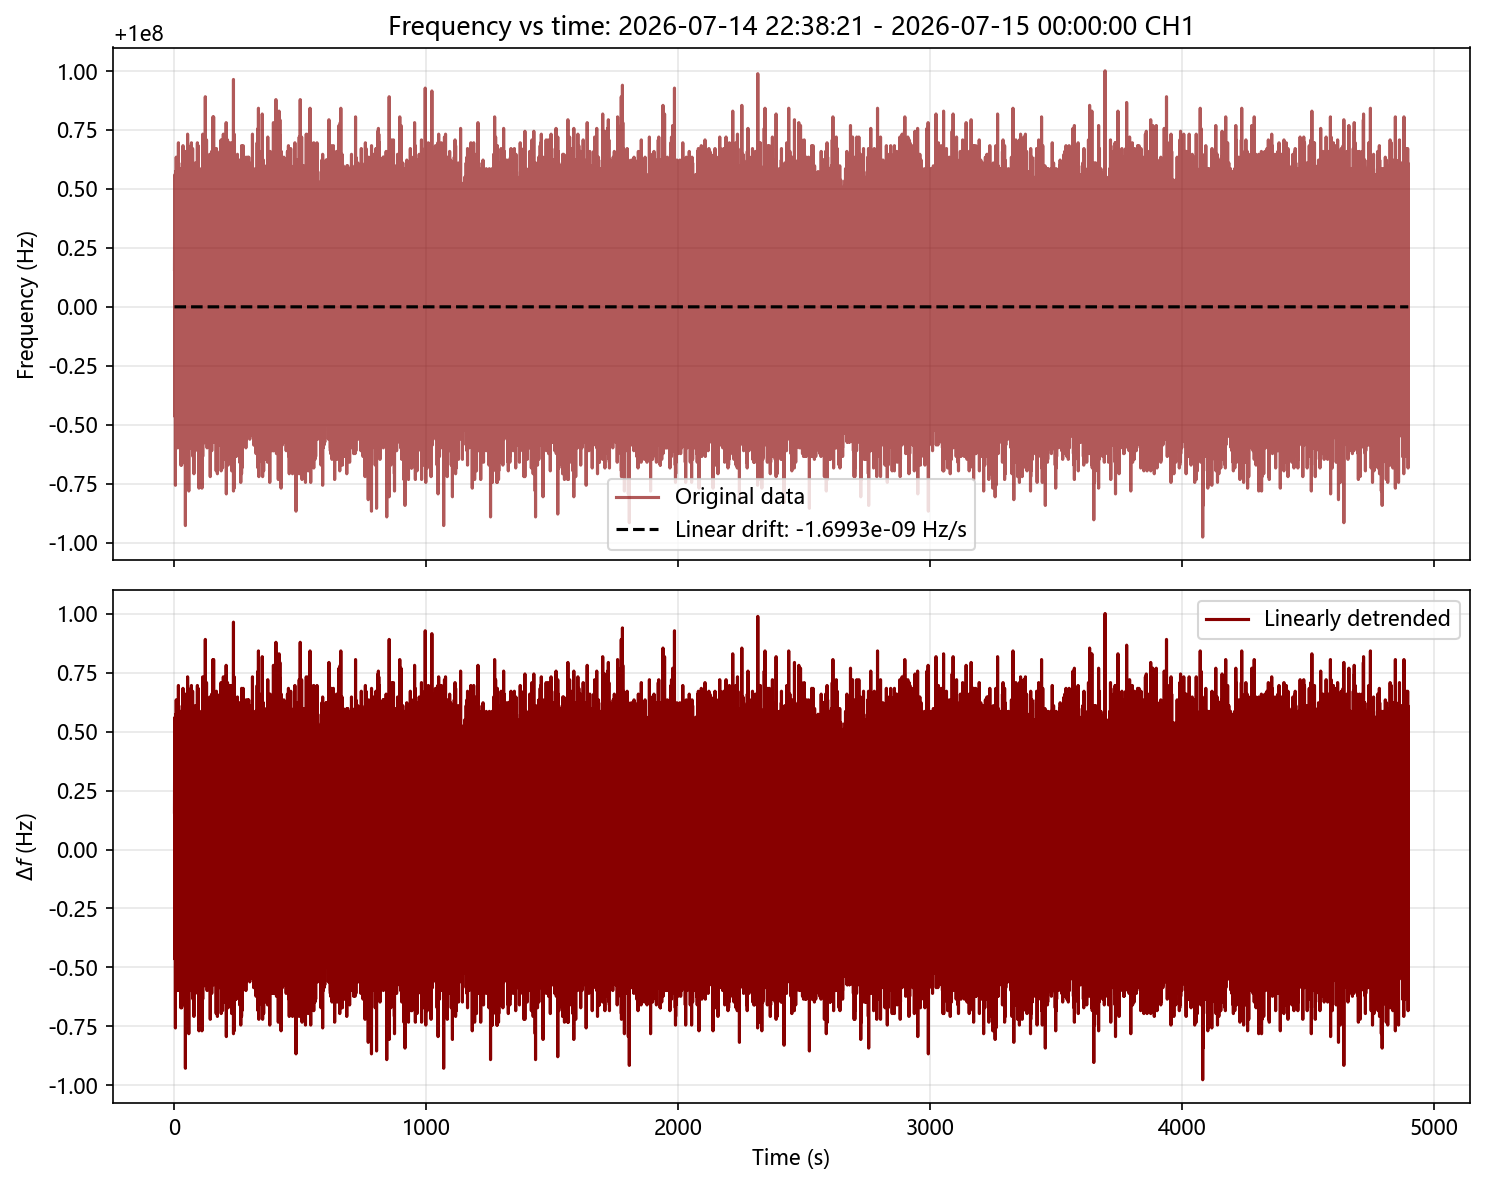

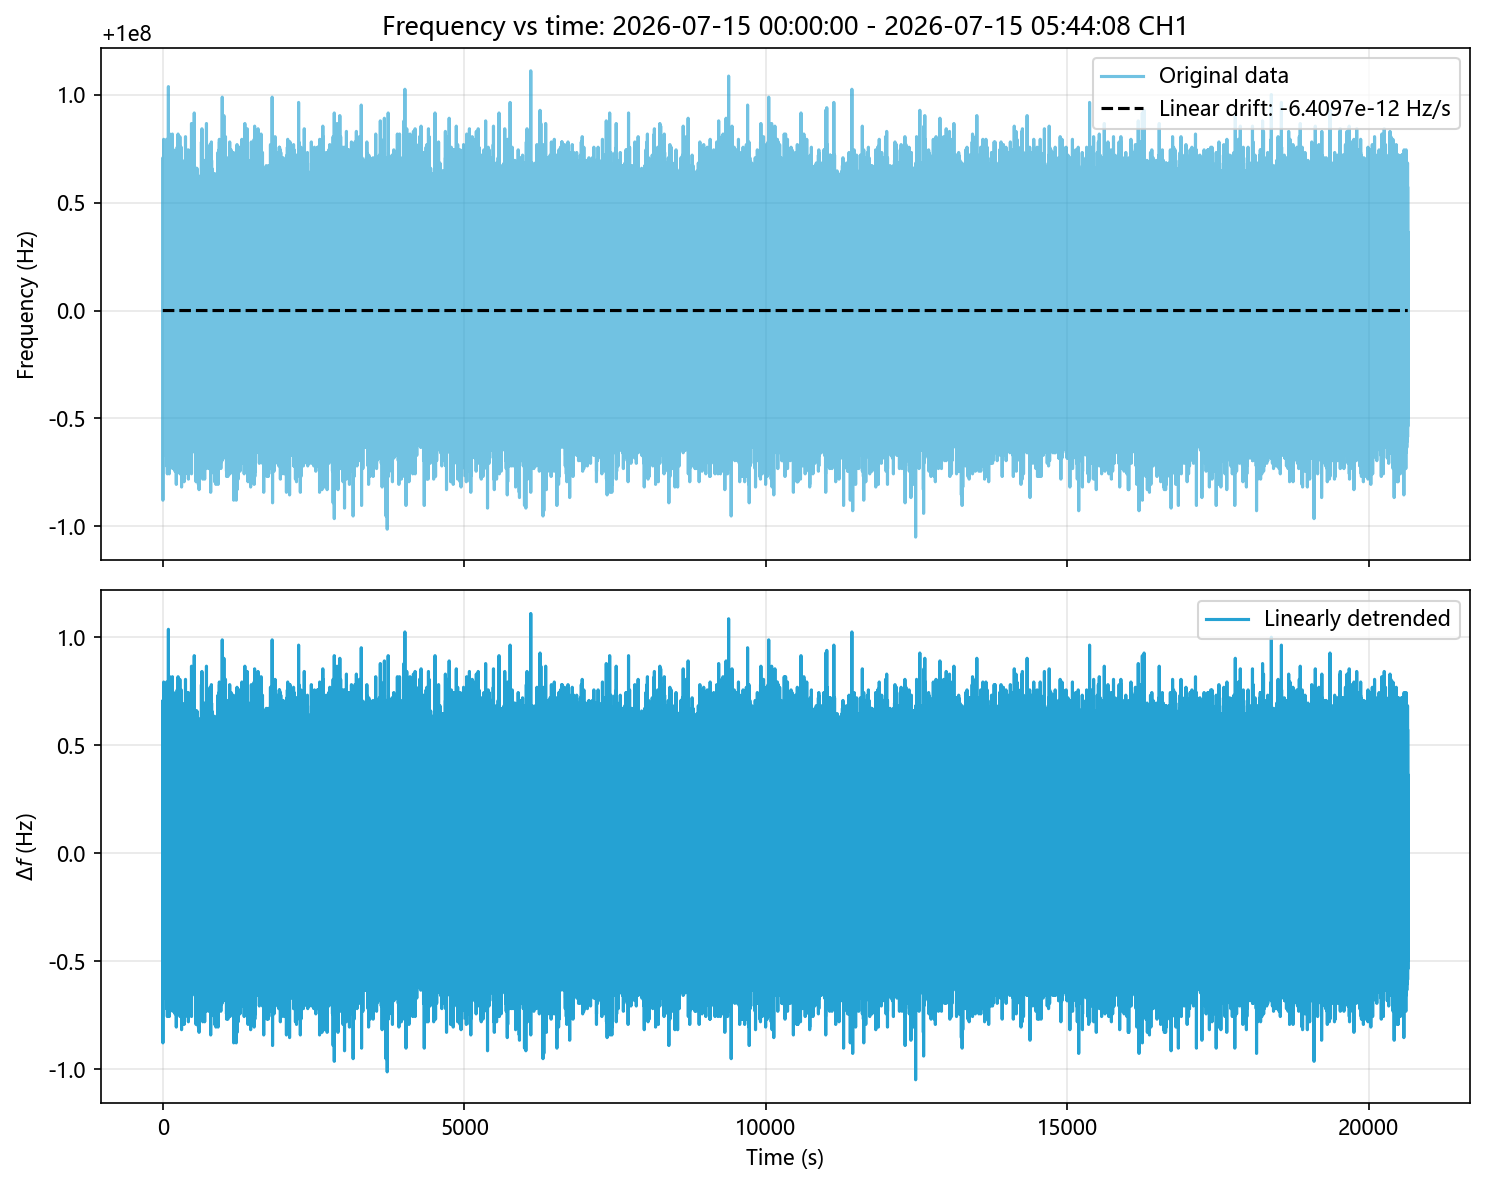

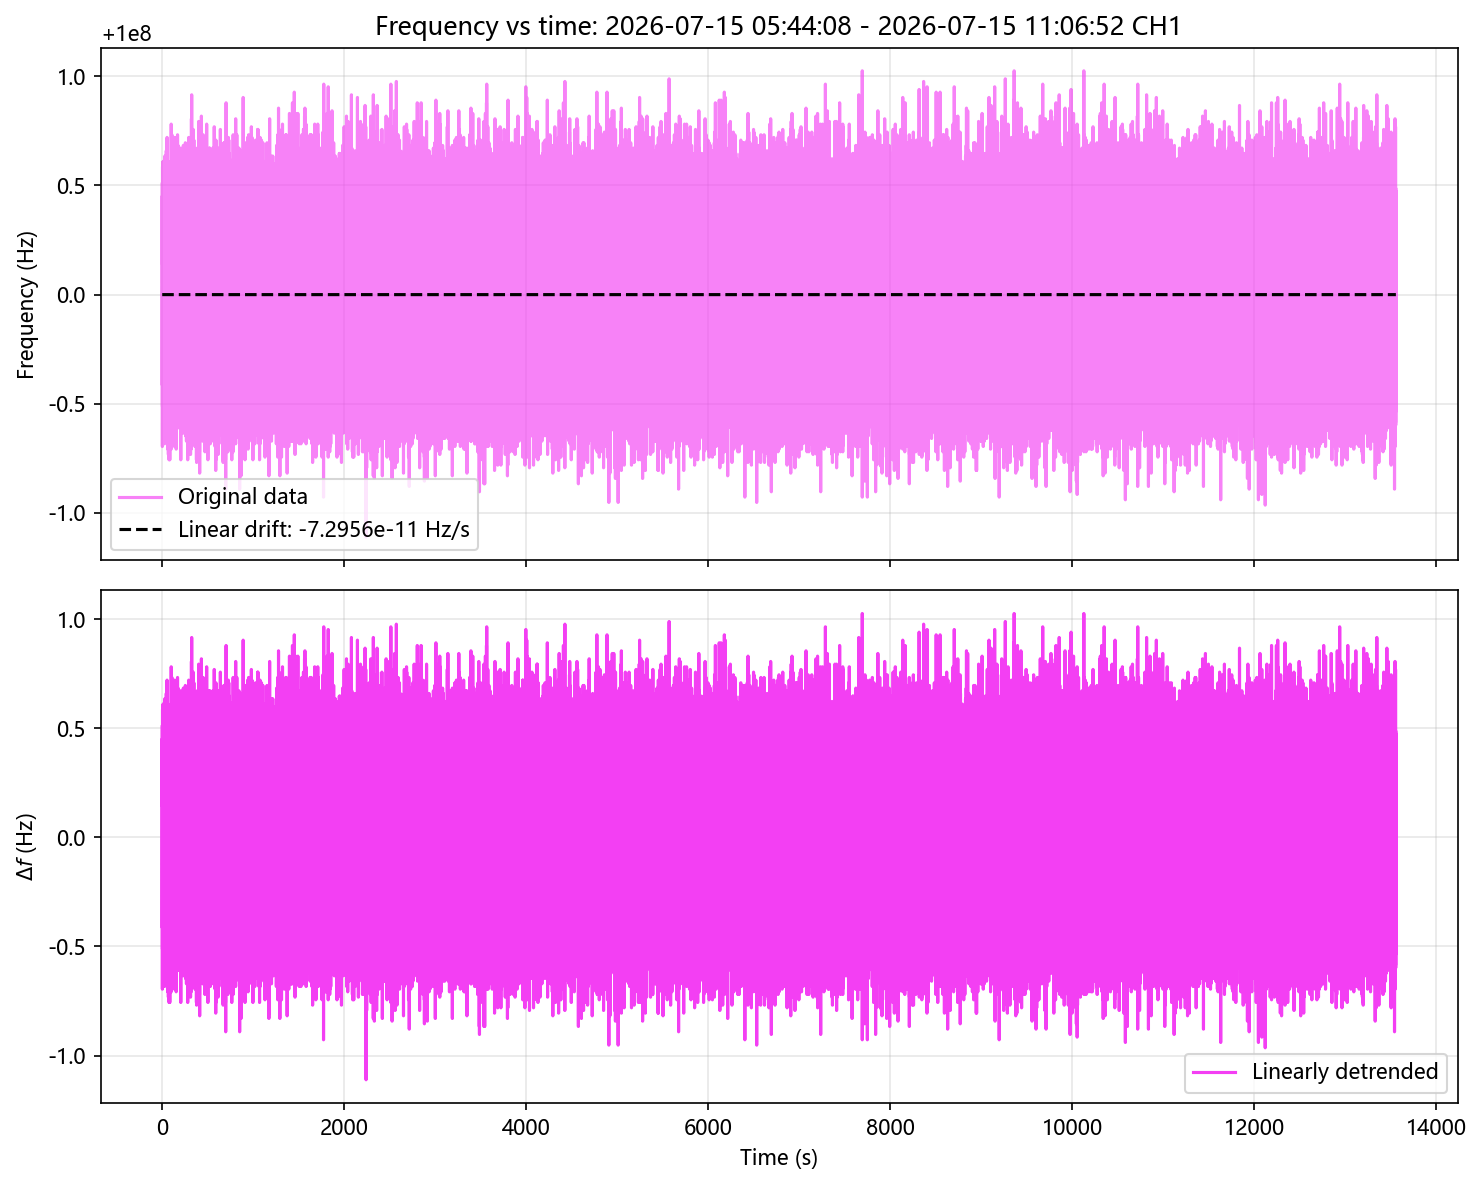

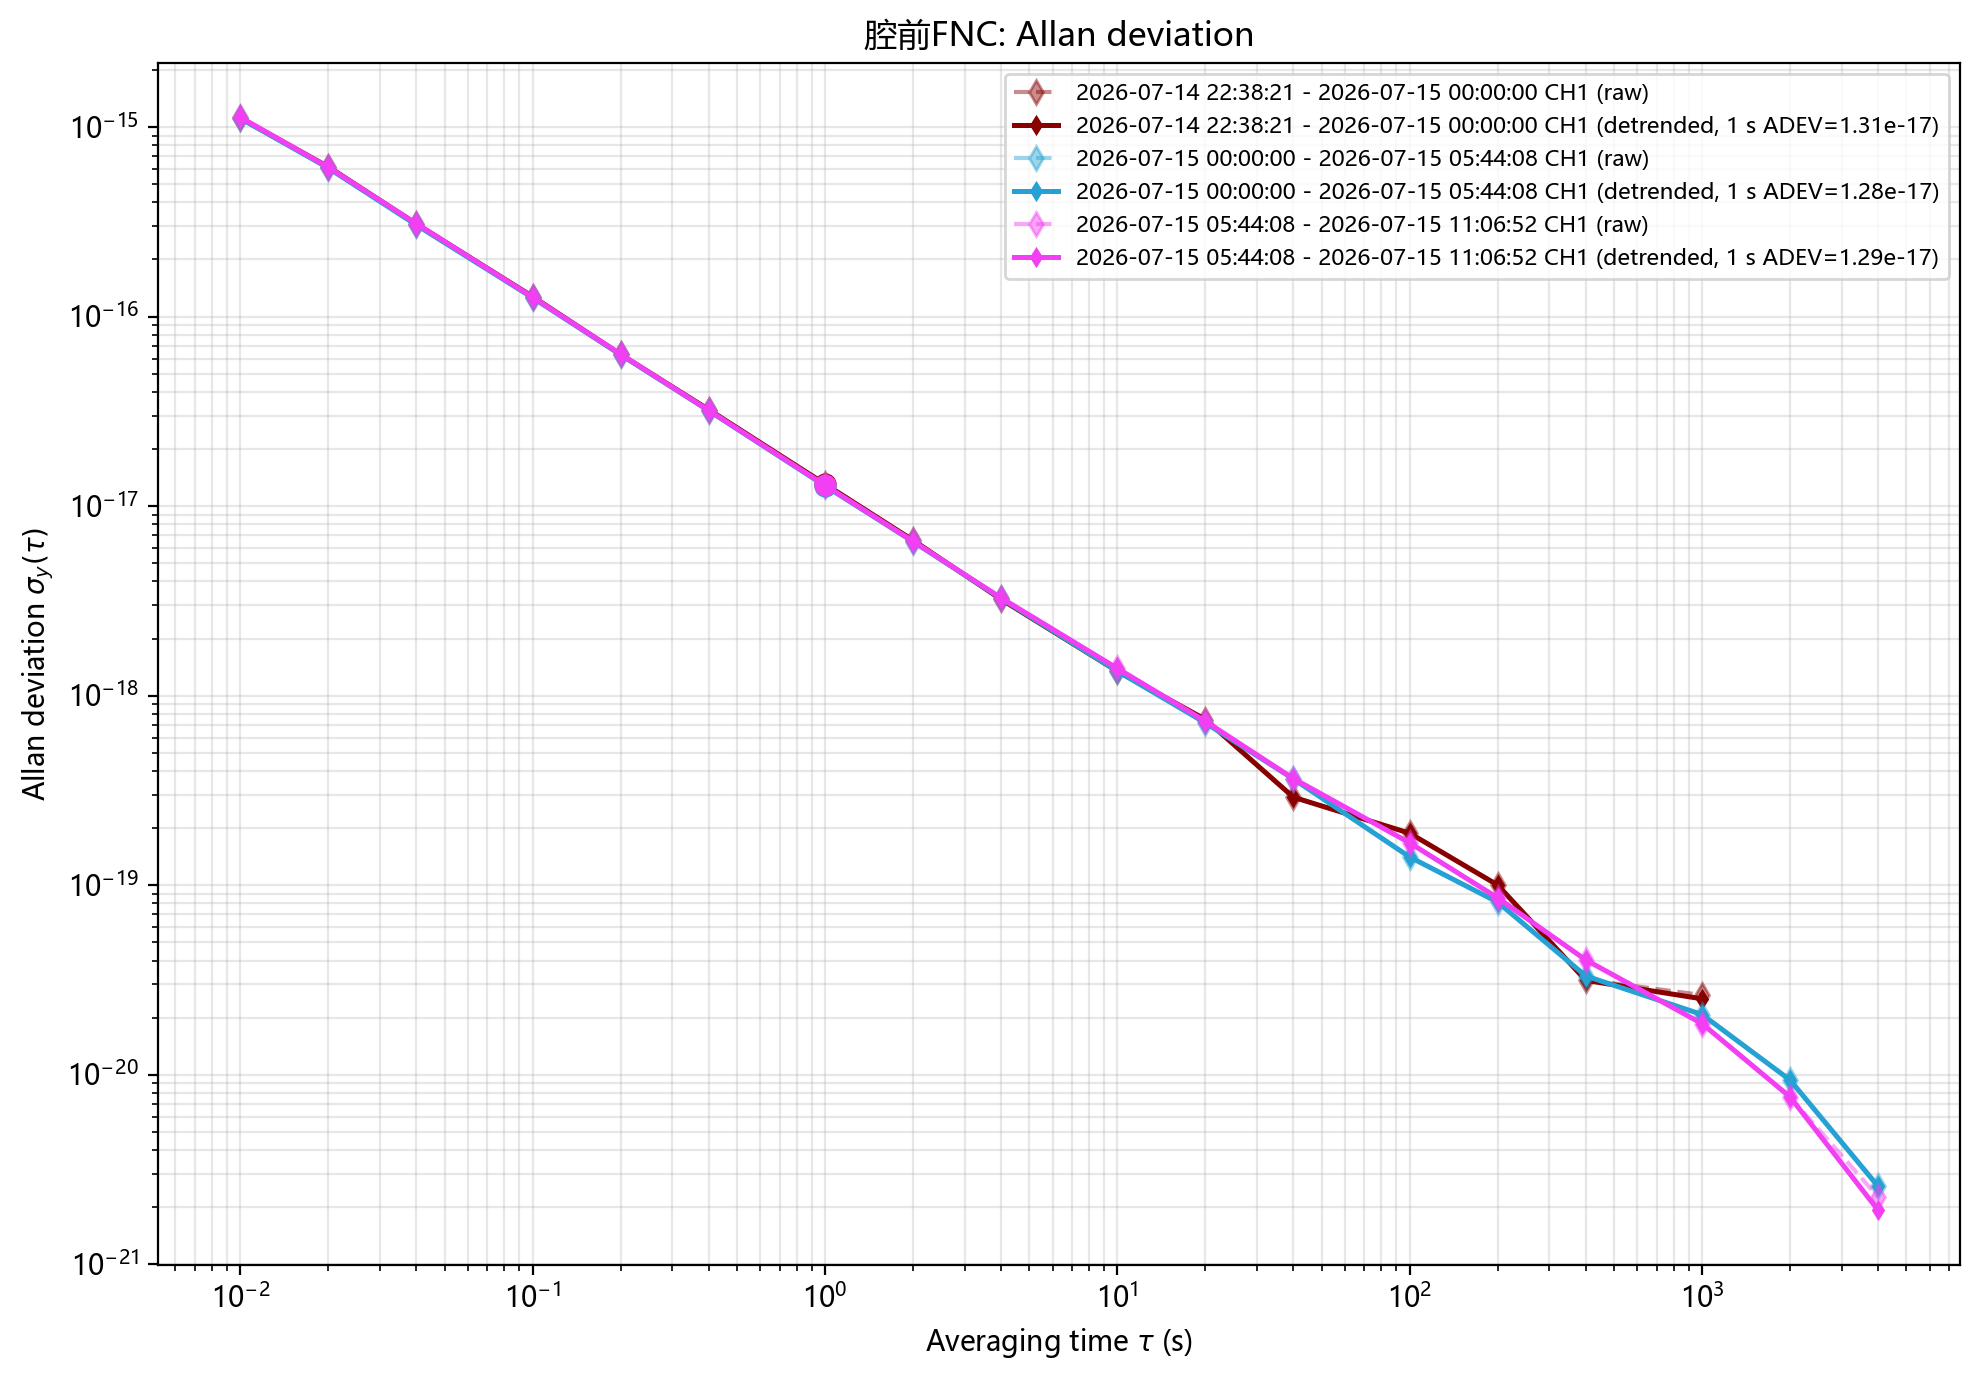

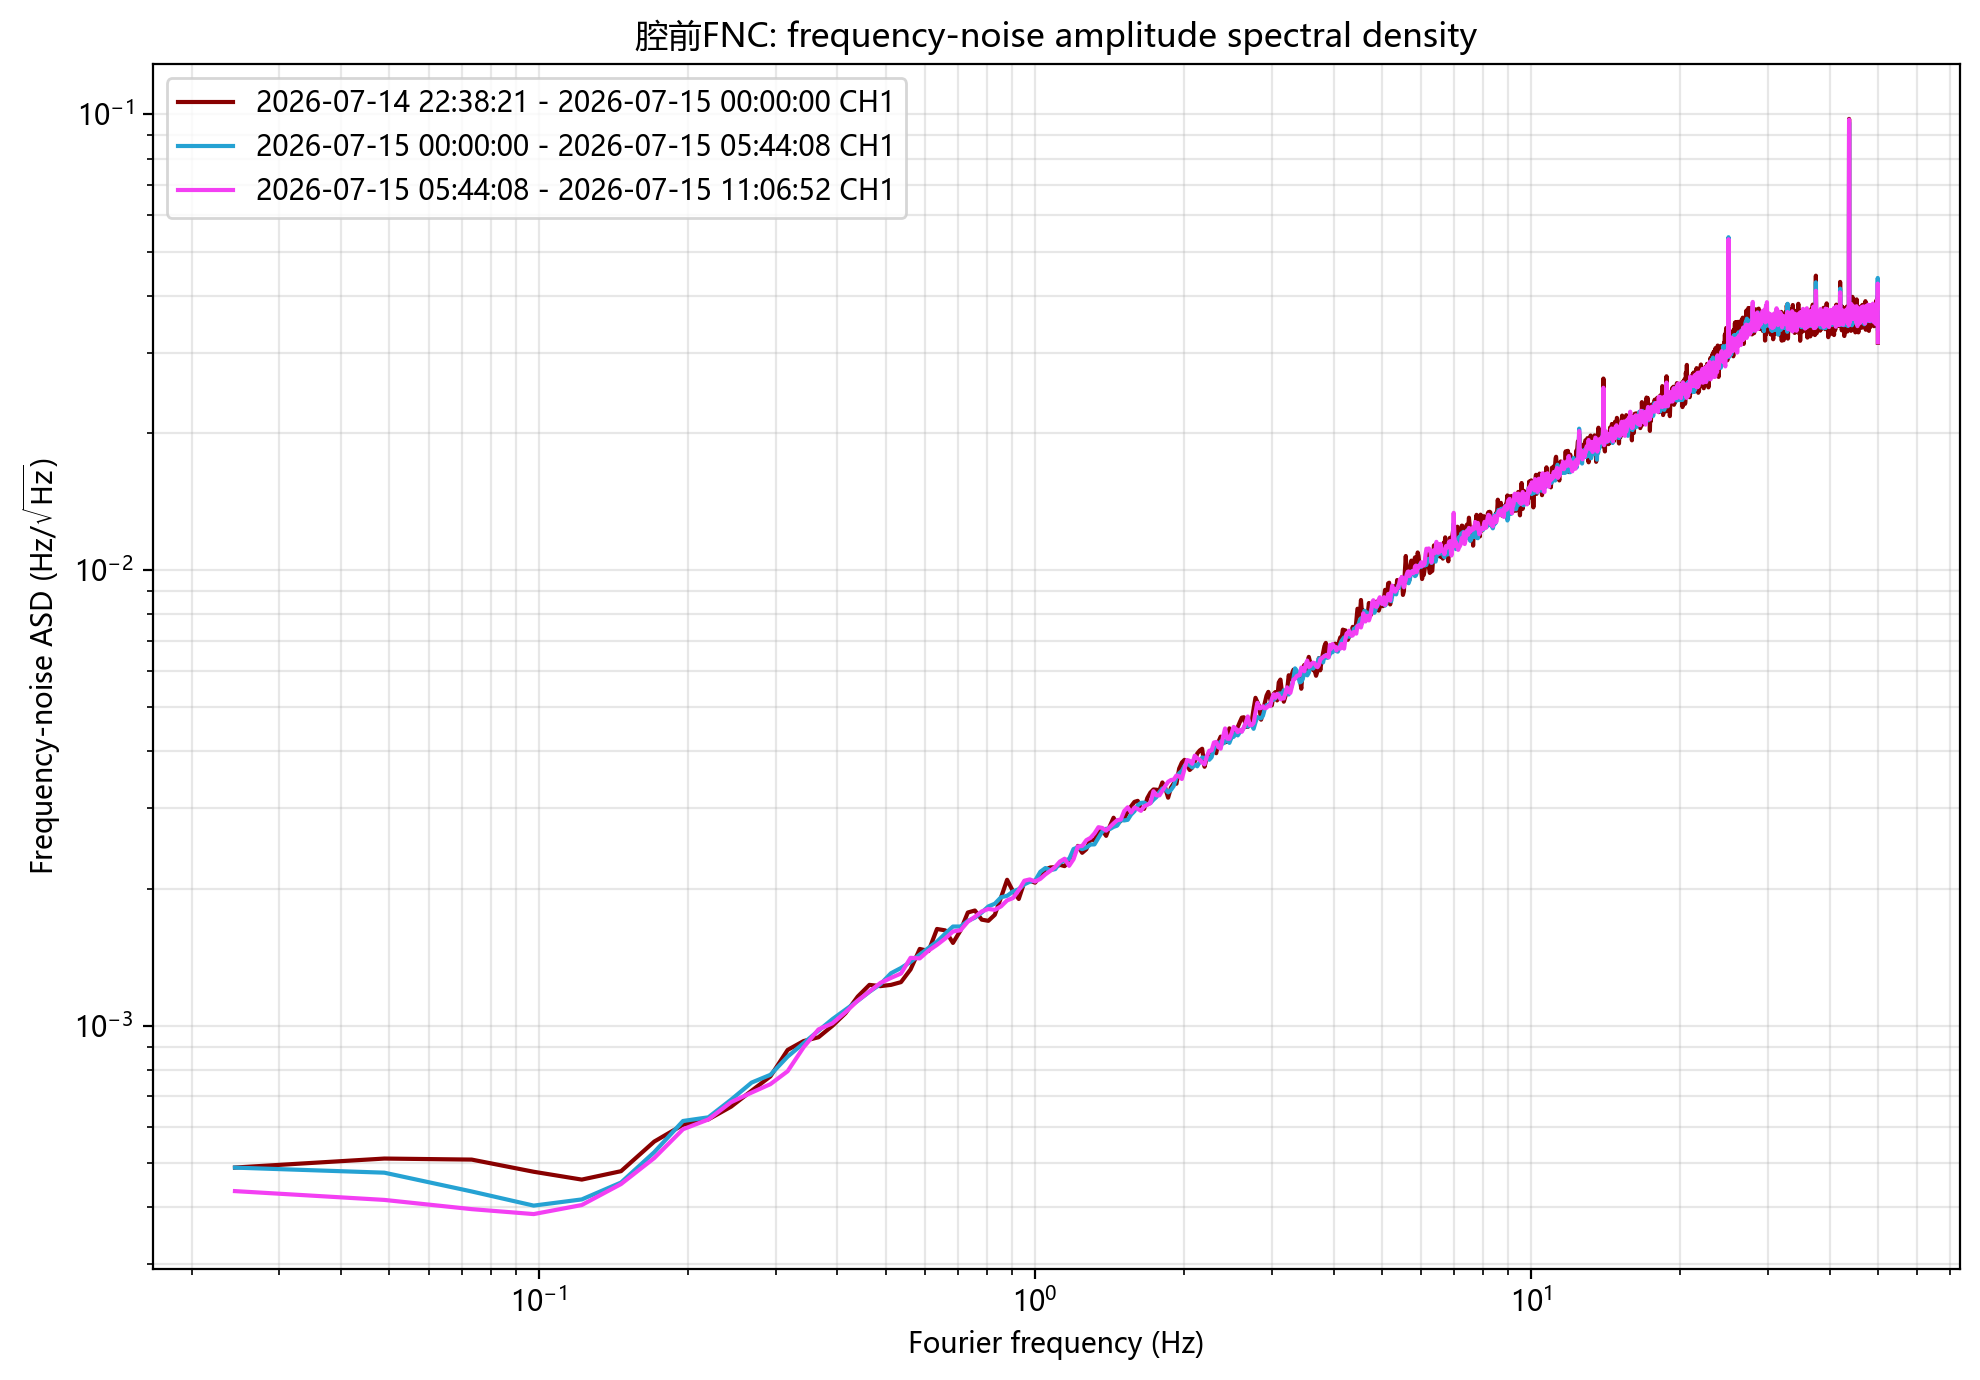

In [14]:
DATA_DIR = FREQUENCY_COUNTER_DATA_ROOT / '20260714-15_FNC'
wavelength_nm = 1397.0
# optical_reference_hz = 299792458.0 / (wavelength_nm * 1e-9)
# Freq_B_3_260714_2.txt  2026/07/14 22:38:21 — 2026/07/15 00:00:00
# Freq_B_3_260715_1.txt  2026/07/15 00:00:00 — 2026/07/15 05:44:08
# Freq_B_3_260715_2.txt  2026/07/15 05:44:08 — 2026/07/15 11:06:52
# optical_reference_hz = 100e6  # 100 MHz reference frequency for the Keysight counter
optical_reference_hz = 299792458.0 / (wavelength_nm * 1e-9)
plot_title = '腔前FNC'
deviation_type = 'adev'  # Choose 'adev' or 'mdev'.

data_configs = [
    {
        'file': DATA_DIR / 'Freq_B_3_260714_2.txt',
        'format': 'kk',
        'channels': [1],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-14 22:38:21 - 2026-07-15 00:00:00',
        'colors': ['#880000', '#004488'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    {
        'file': DATA_DIR / 'Freq_B_3_260715_1.txt',
        'format': 'kk',
        'channels': [1],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-15 00:00:00 - 2026-07-15 05:44:08',
        'colors': ["#25A2D3", '#004488'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    {
        'file': DATA_DIR / 'Freq_B_3_260715_2.txt',
        'format': 'kk',
        'channels': [1],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-15 05:44:08 - 2026-07-15 11:06:52',
        'colors': ["#F33FF3", '#004488'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 0.7,
        'psd_nperseg': 4096,
    }
]

results = run_frequency_counter_analysis(
    data_configs=data_configs,
    plot_title=plot_title,
    optical_reference_hz=optical_reference_hz,
    wavelength_nm=wavelength_nm,
    deviation_type=deviation_type,
)

# 20260721断电后加了隔音罩
只加了隔音箱框架，未贴外部的隔音棉

2026-07-22 00:21:00 - 2026-07-22 01:03:38 CH1: 255842 points, tau=0.01 s, MDEV(1 s)=5.760e-16, PSD nperseg=4096
2026-07-22 00:21:00 - 2026-07-22 01:03:38 CH2: 255842 points, tau=0.01 s, MDEV(1 s)=5.760e-16, PSD nperseg=4096
2026-07-22 01:03:38 - 2026-07-22 06:47:47 CH1: 2064889 points, tau=0.01 s, MDEV(1 s)=7.977e-16, PSD nperseg=4096
2026-07-22 01:03:38 - 2026-07-22 06:47:47 CH2: 2064889 points, tau=0.01 s, MDEV(1 s)=7.977e-16, PSD nperseg=4096
2026-07-22 06:47:47 - 2026-07-22 09:04:44 CH1: 821705 points, tau=0.01 s, MDEV(1 s)=6.654e-16, PSD nperseg=4096
2026-07-22 06:47:47 - 2026-07-22 09:04:44 CH2: 821705 points, tau=0.01 s, MDEV(1 s)=6.654e-16, PSD nperseg=4096


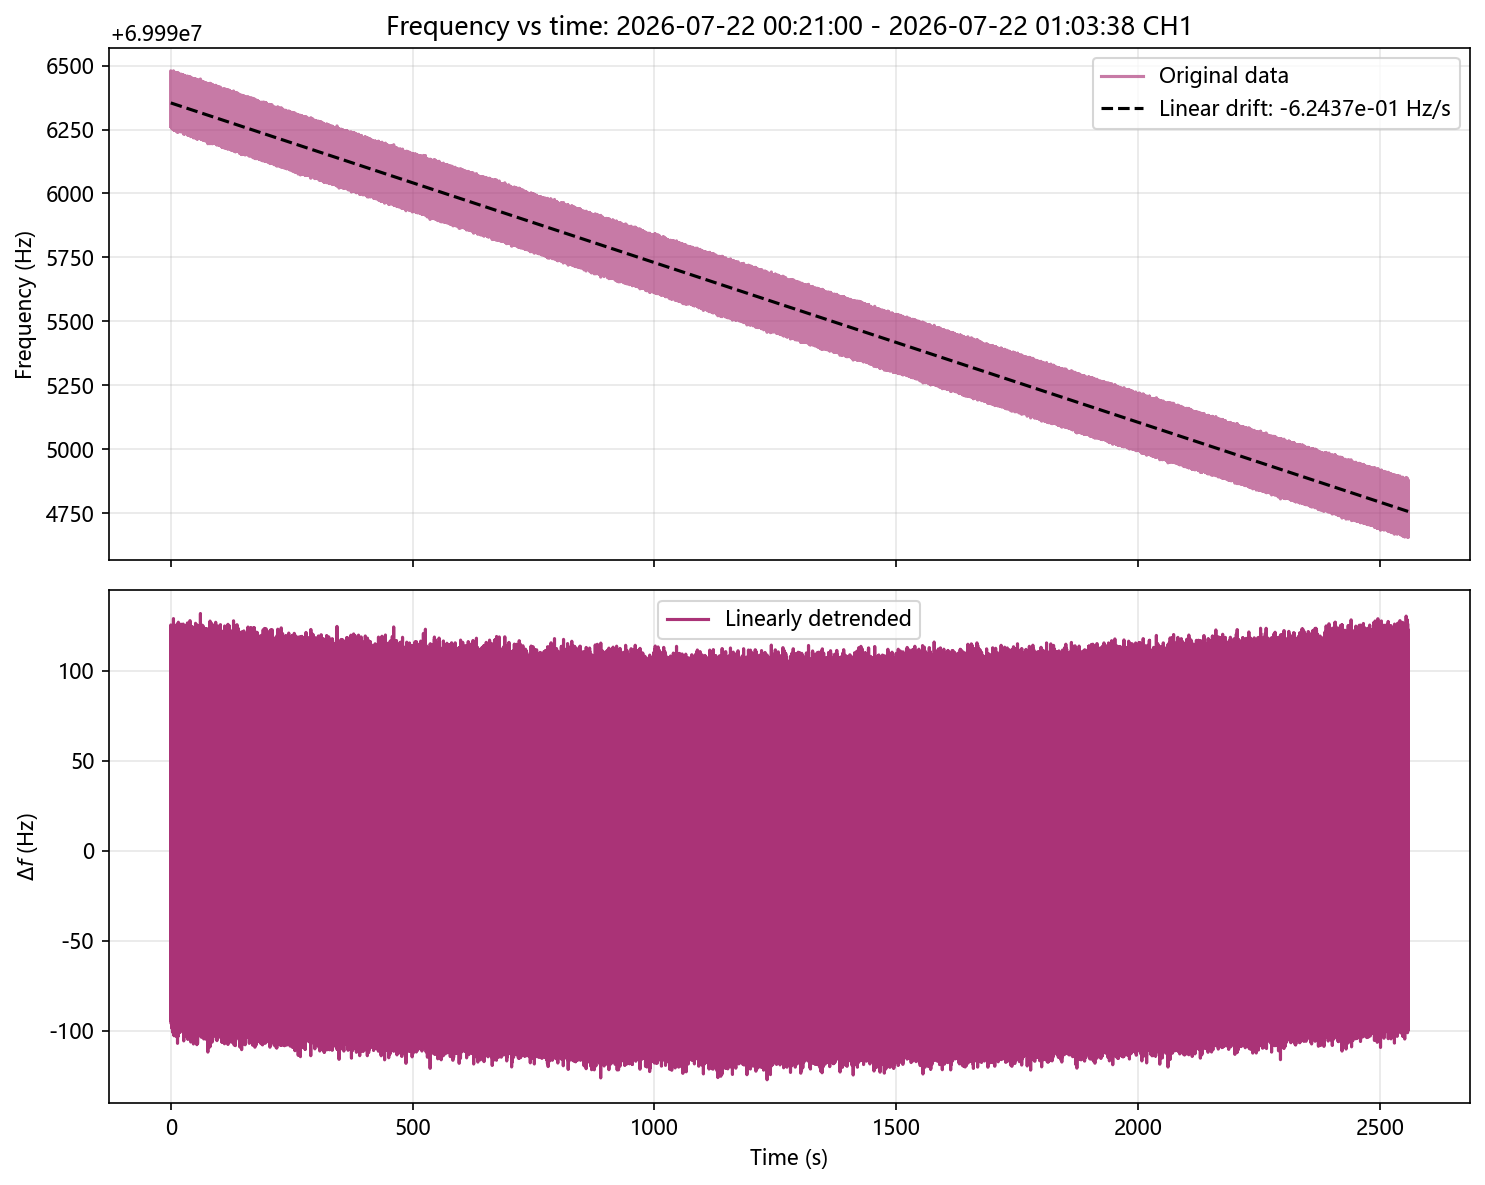

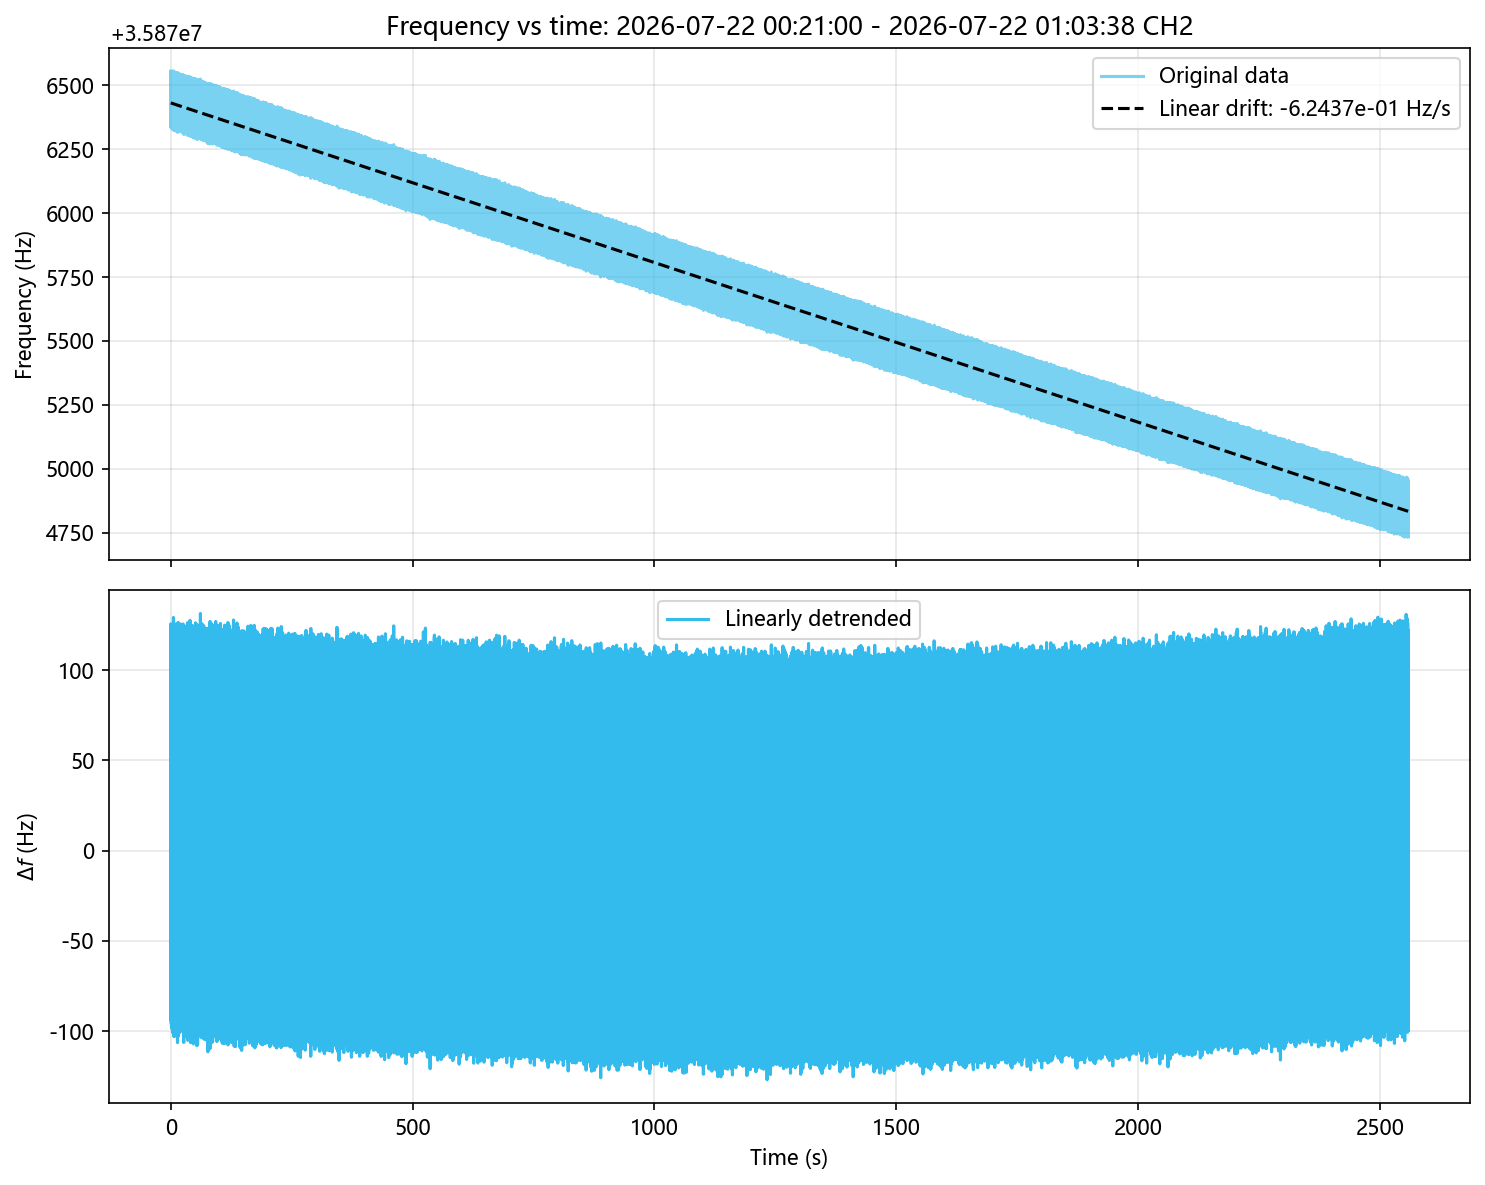

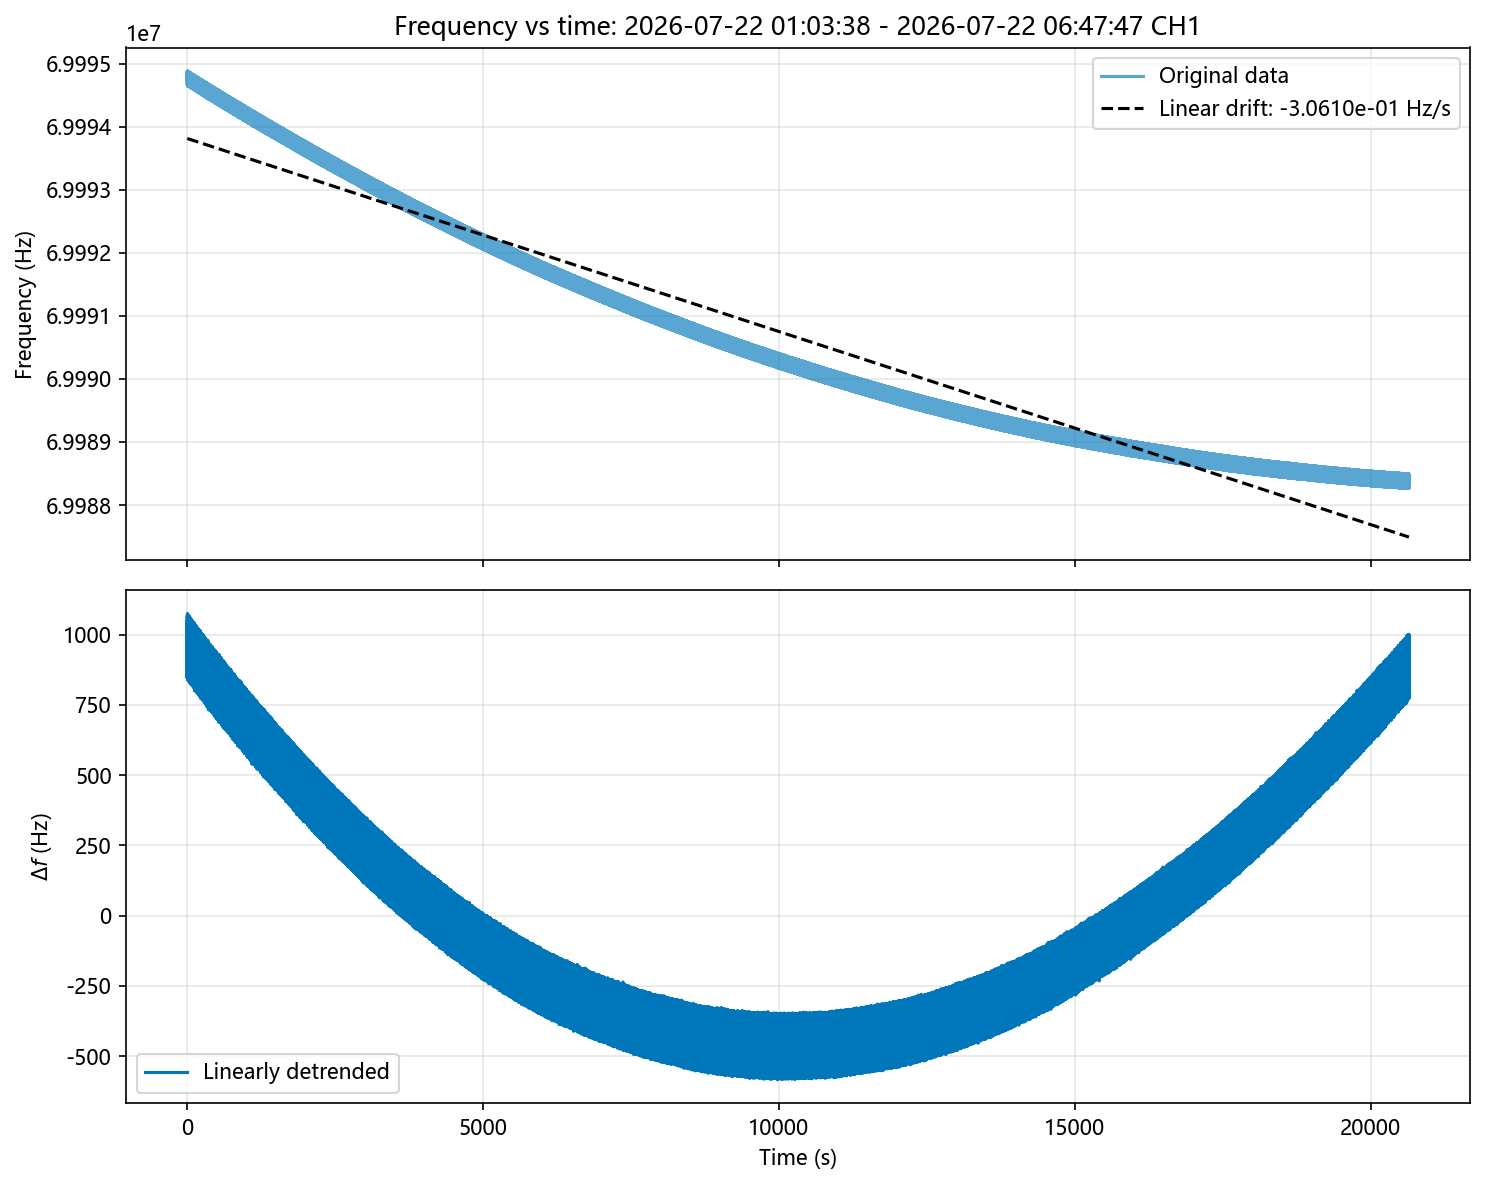

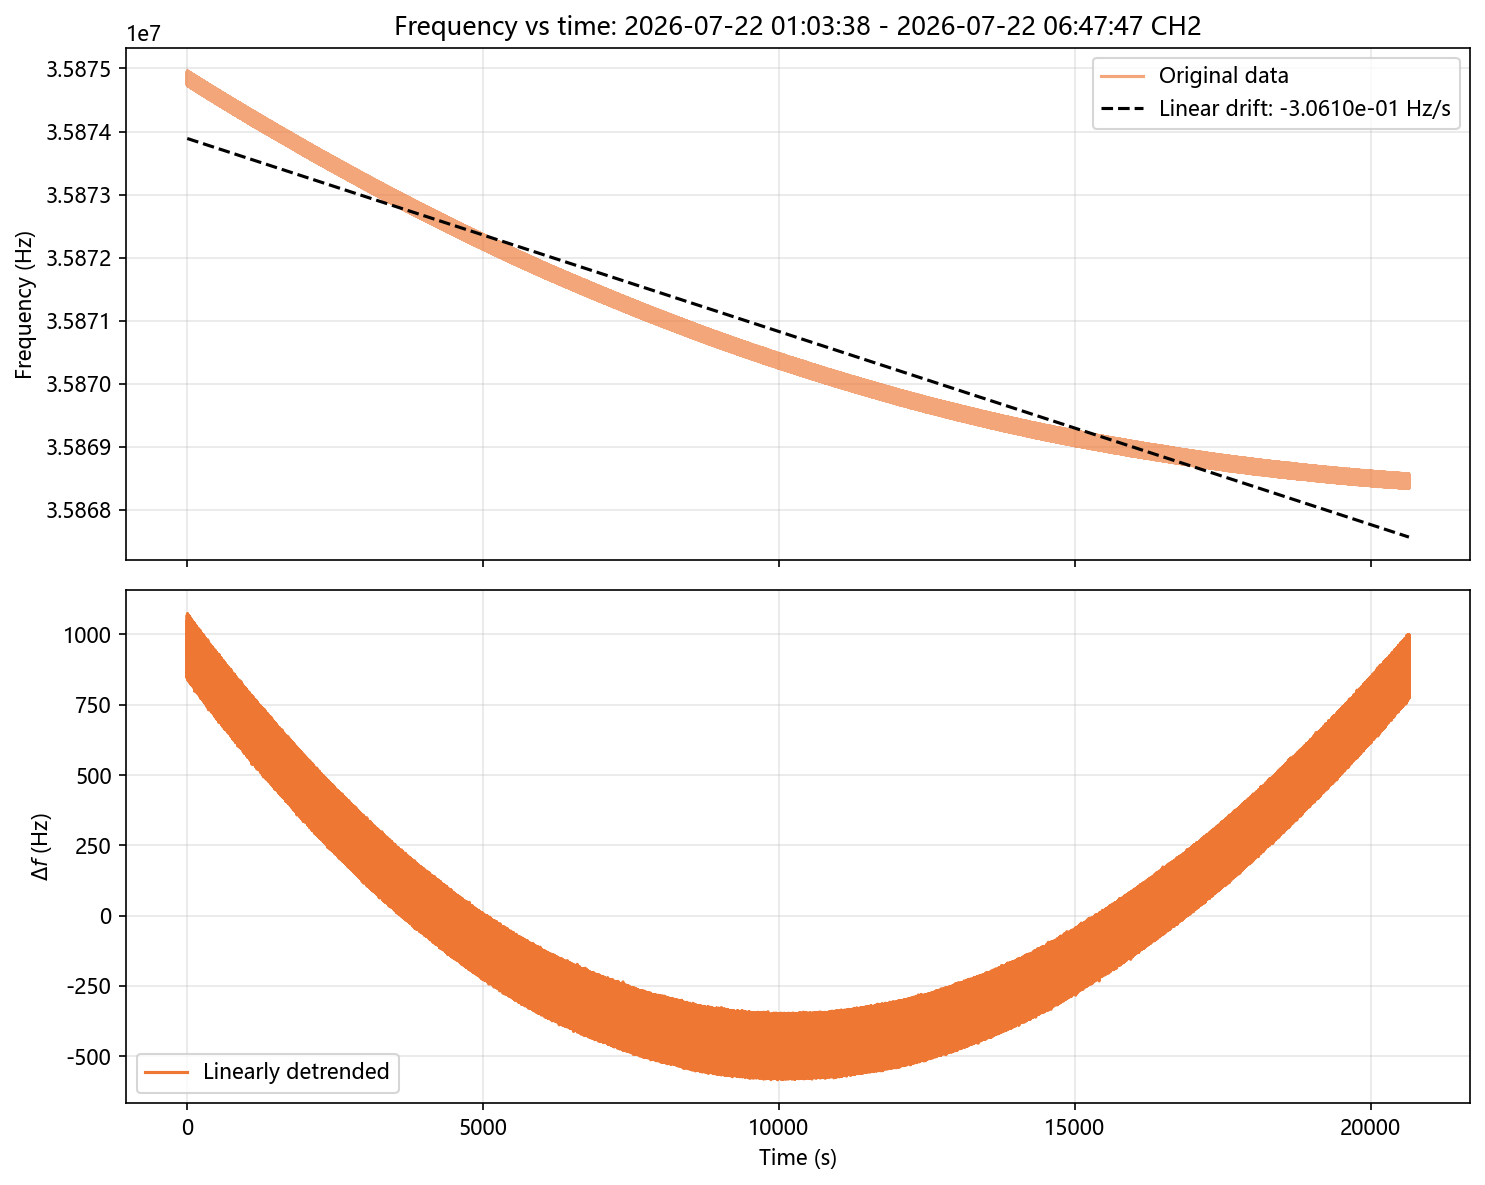

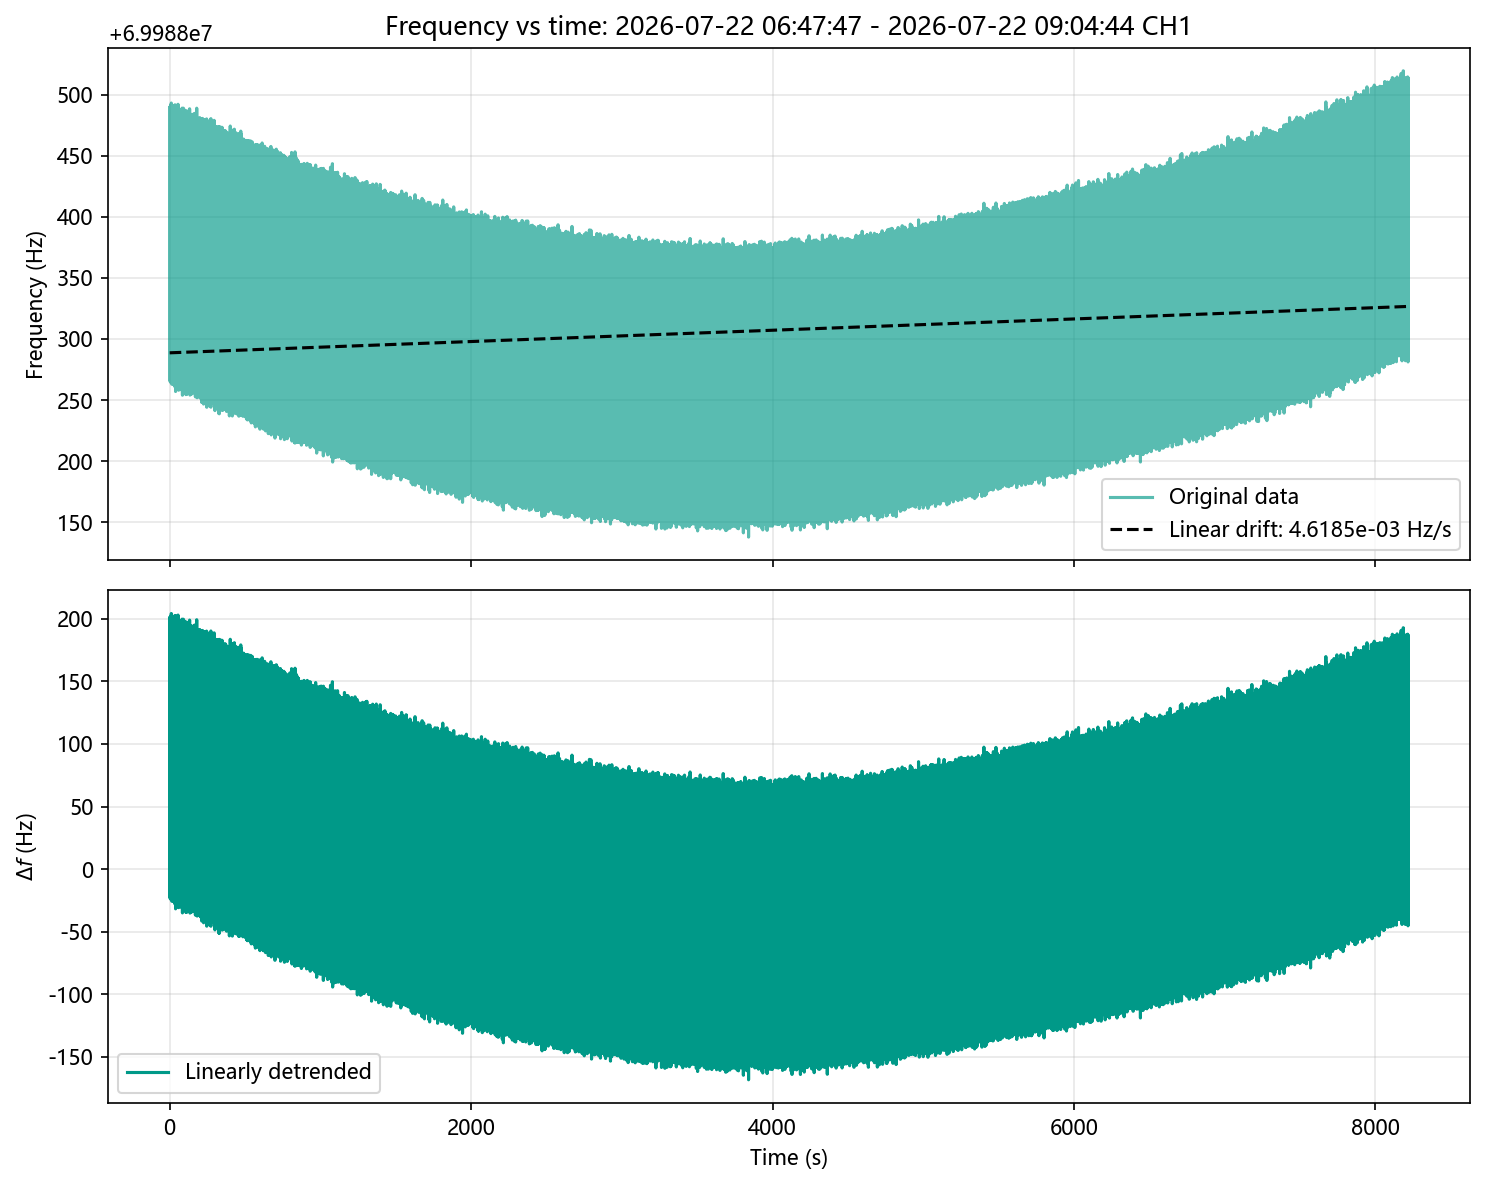

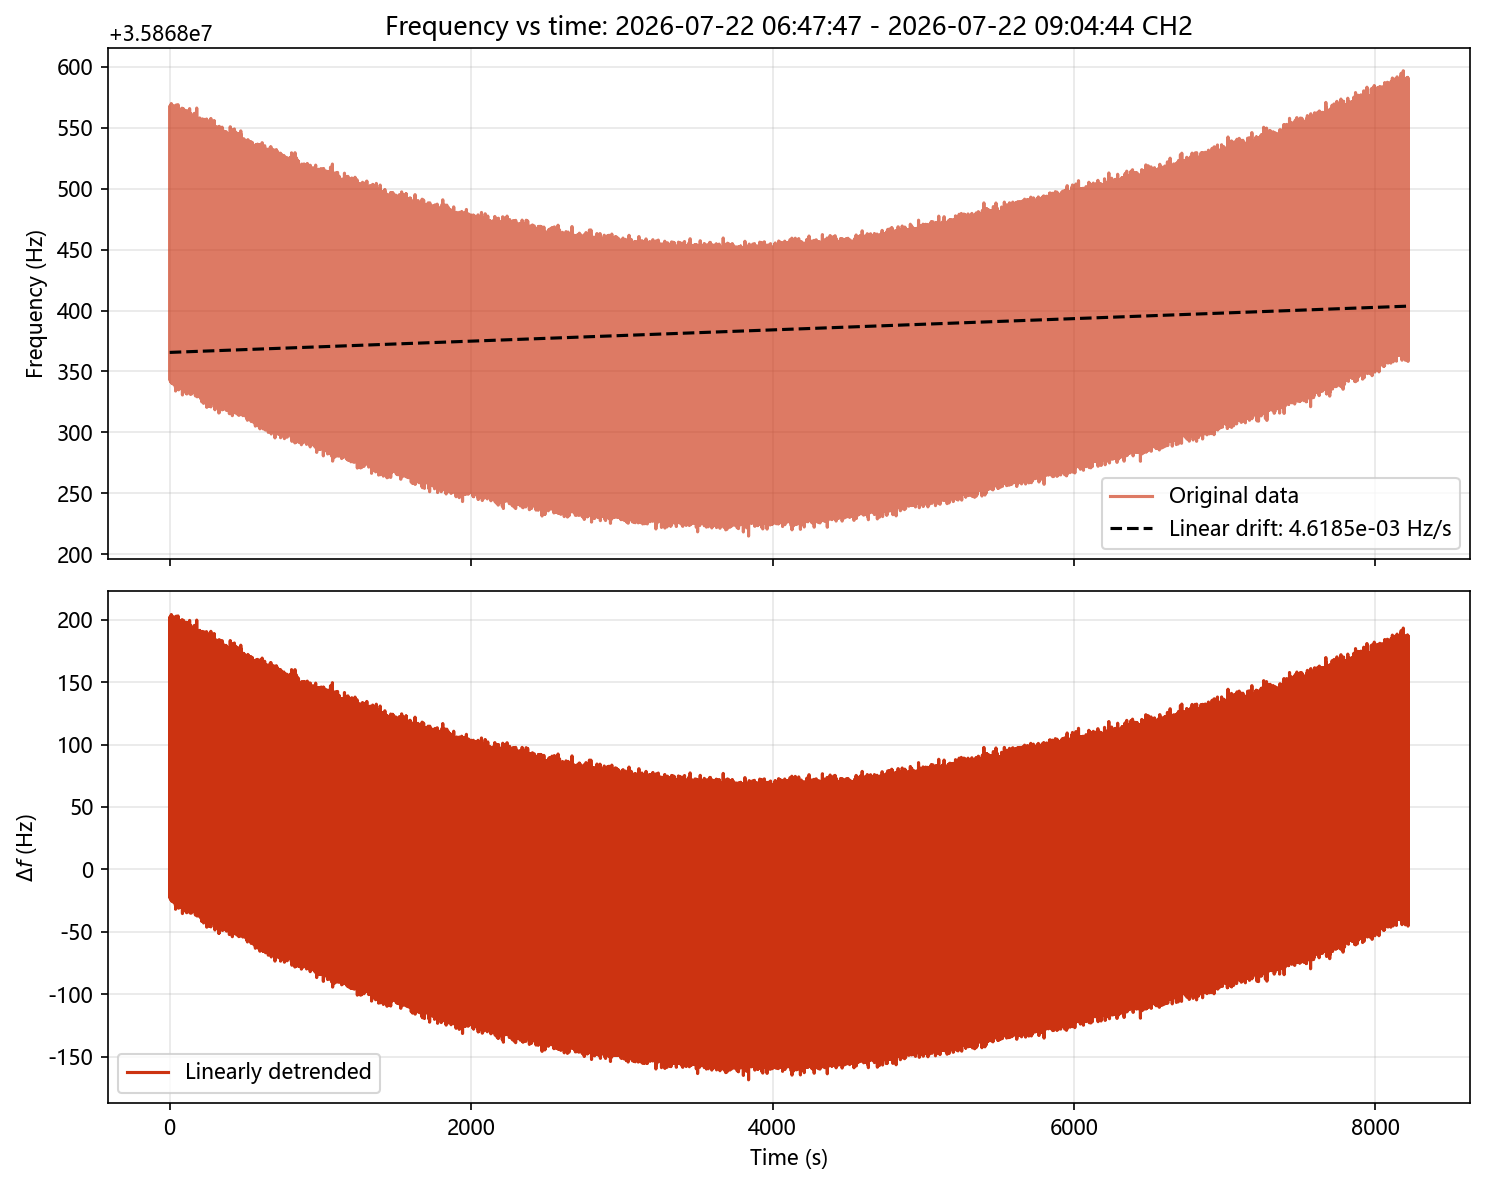

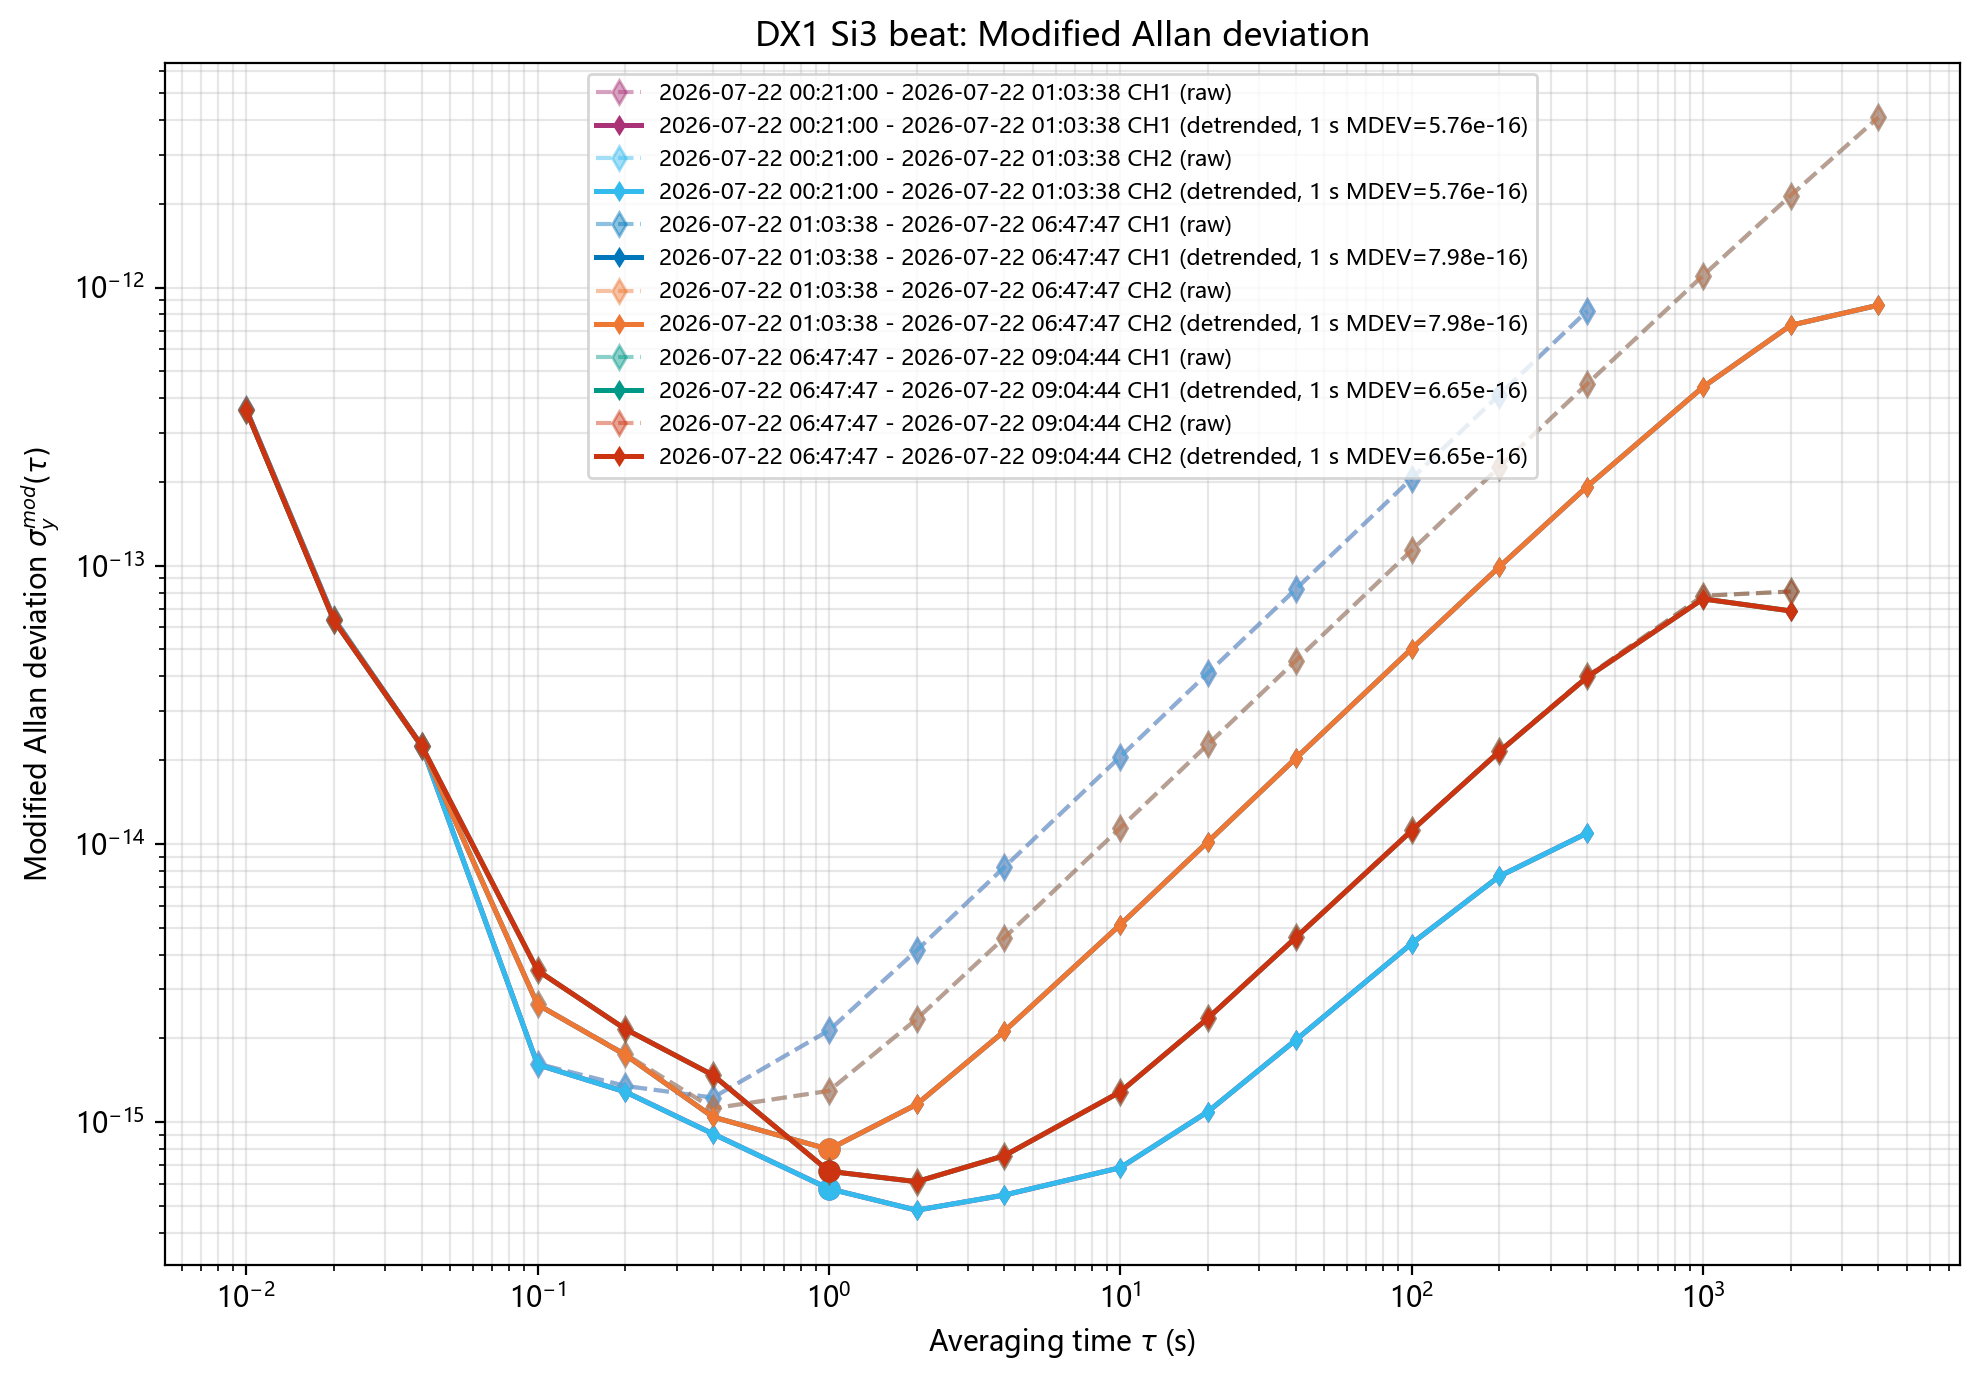

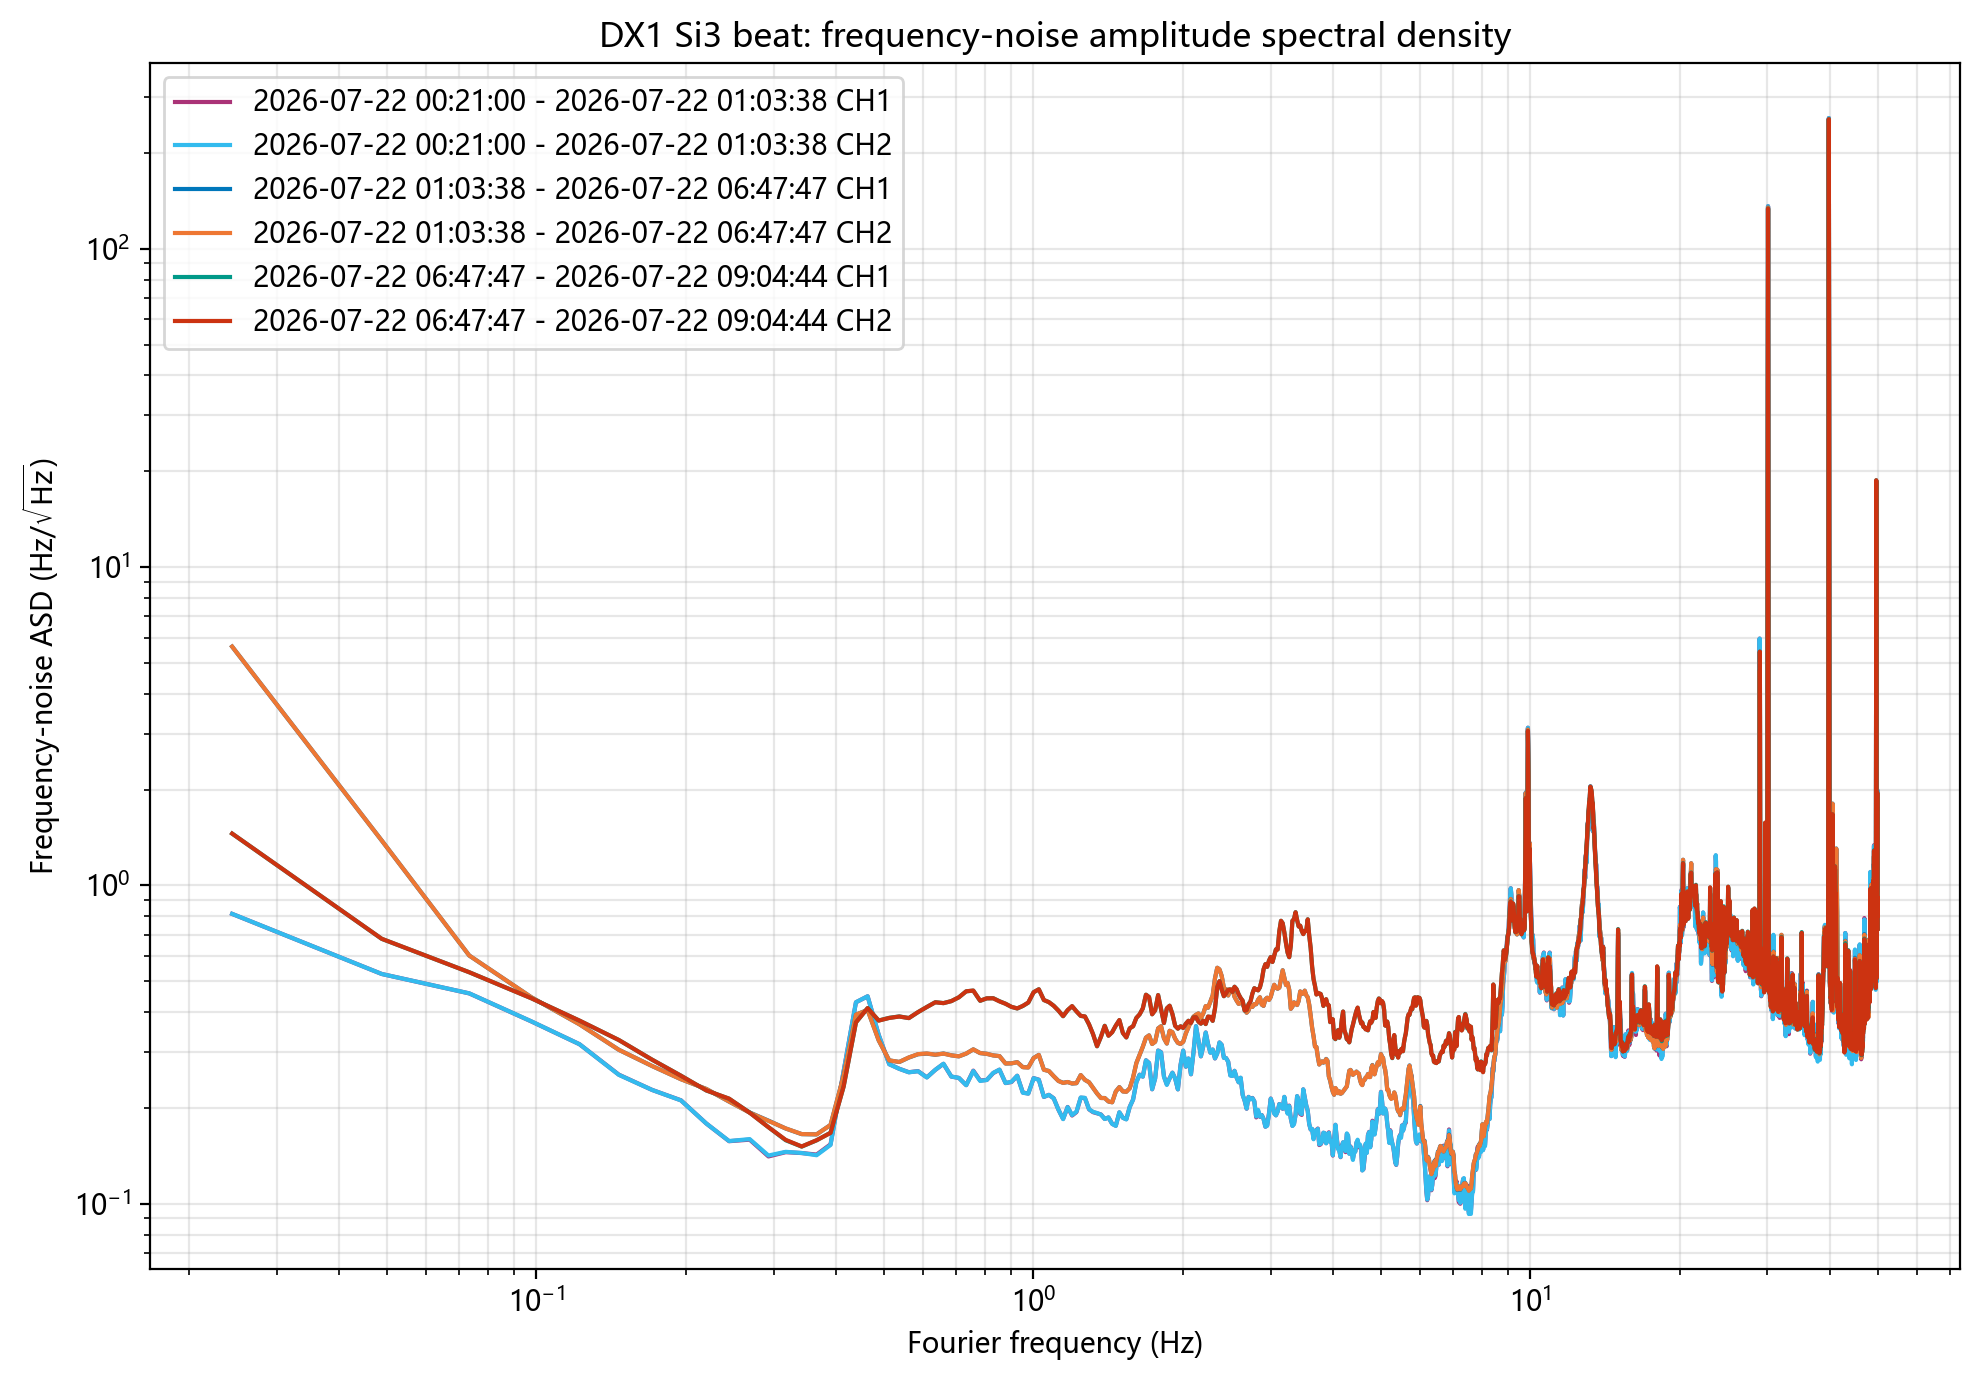

In [7]:
DATA_DIR = FREQUENCY_COUNTER_DATA_ROOT / '20260721-15DX1_Si3_beat'
wavelength_nm = 1397.0
optical_reference_hz = 299792458.0 / (wavelength_nm * 1e-9)
plot_title = 'DX1 Si3 beat'
deviation_type = 'mdev'  # Choose 'adev' or 'mdev'.

data_configs = [
    # {
    #     'file': DATA_DIR / 'Freq_A_1_260721_1.txt',
    #     'format': 'kk',
    #     'channels': [1],  # Use [1, 2] to analyze both K+K channels.
    #     'label': '2026-07-21 22:00:07 - 2026-07-22 00:21:00',
    #     'colors': ['#880000', '#004488'],
    #     'tau': 0.01,
    #     'cut_ratio_lower': 0.0,
    #     'cut_ratio_upper': 1.0,
    #     'psd_nperseg': 4096,
    # },
    {
        'file': DATA_DIR / 'Freq_A_1_260721_2.txt',
        'format': 'kk',
        'channels': [1, 2],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-22 00:21:00 - 2026-07-22 01:03:38',
        'colors': ['#AA3377', '#33BBEE'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    {
        'file': DATA_DIR / 'Freq_A_1_260722_1.txt',
        'format': 'kk',
        'channels': [1, 2],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-22 01:03:38 - 2026-07-22 06:47:47',
        'colors': ['#0077BB', '#EE7733'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    {
        'file': DATA_DIR / 'Freq_A_1_260722_2.txt',
        'format': 'kk',
        'channels': [1, 2],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-22 06:47:47 - 2026-07-22 09:04:44',
        'colors': ['#009988', '#CC3311'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
]

results = run_frequency_counter_analysis(
    data_configs=data_configs,
    plot_title=plot_title,
    optical_reference_hz=optical_reference_hz,
    wavelength_nm=wavelength_nm,
    deviation_type=deviation_type,
)

# 20260722-20260723 频率计数据
Freq_A_1_260722_3.txt  2026/07/22 22:10:38 — 2026/07/23 01:03:39
Freq_A_1_260723_1.txt  2026/07/23 01:03:39 — 2026/07/23 06:47:48
Freq_A_1_260723_2.txt  2026/07/23 06:47:48 — 2026/07/23 12:31:57

2026-07-22 22:10:38 - 2026-07-23 01:03:39 CH1: 570952 points, tau=0.01 s, MDEV(1 s)=1.181e-15, PSD nperseg=4096
2026-07-22 22:10:38 - 2026-07-23 01:03:39 CH2: 570952 points, tau=0.01 s, MDEV(1 s)=1.181e-15, PSD nperseg=4096
2026-07-23 01:03:39 - 2026-07-23 06:47:48 CH1: 2064889 points, tau=0.01 s, MDEV(1 s)=1.084e-15, PSD nperseg=4096
2026-07-23 01:03:39 - 2026-07-23 06:47:48 CH2: 2064889 points, tau=0.01 s, MDEV(1 s)=1.084e-15, PSD nperseg=4096
2026-07-23 06:47:48 - 2026-07-23 12:31:57 CH1: 1342177 points, tau=0.01 s, MDEV(1 s)=1.080e-11, PSD nperseg=4096
2026-07-23 06:47:48 - 2026-07-23 12:31:57 CH2: 1342177 points, tau=0.01 s, MDEV(1 s)=1.080e-11, PSD nperseg=4096


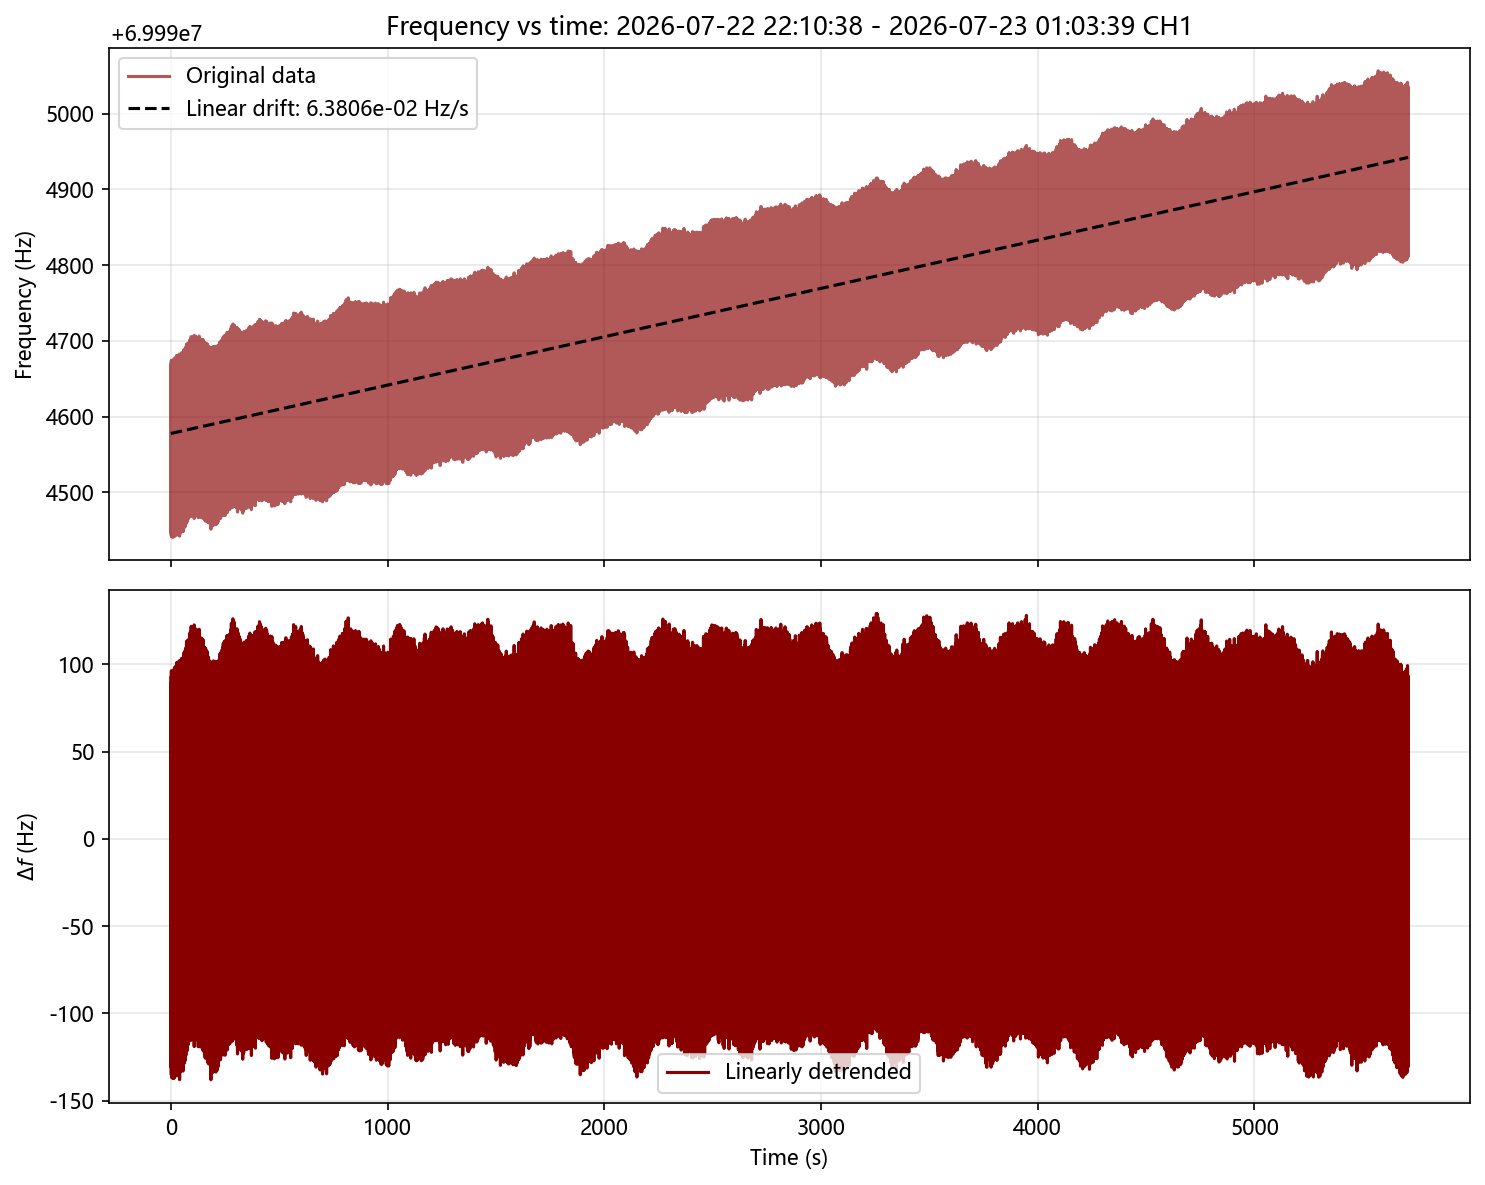

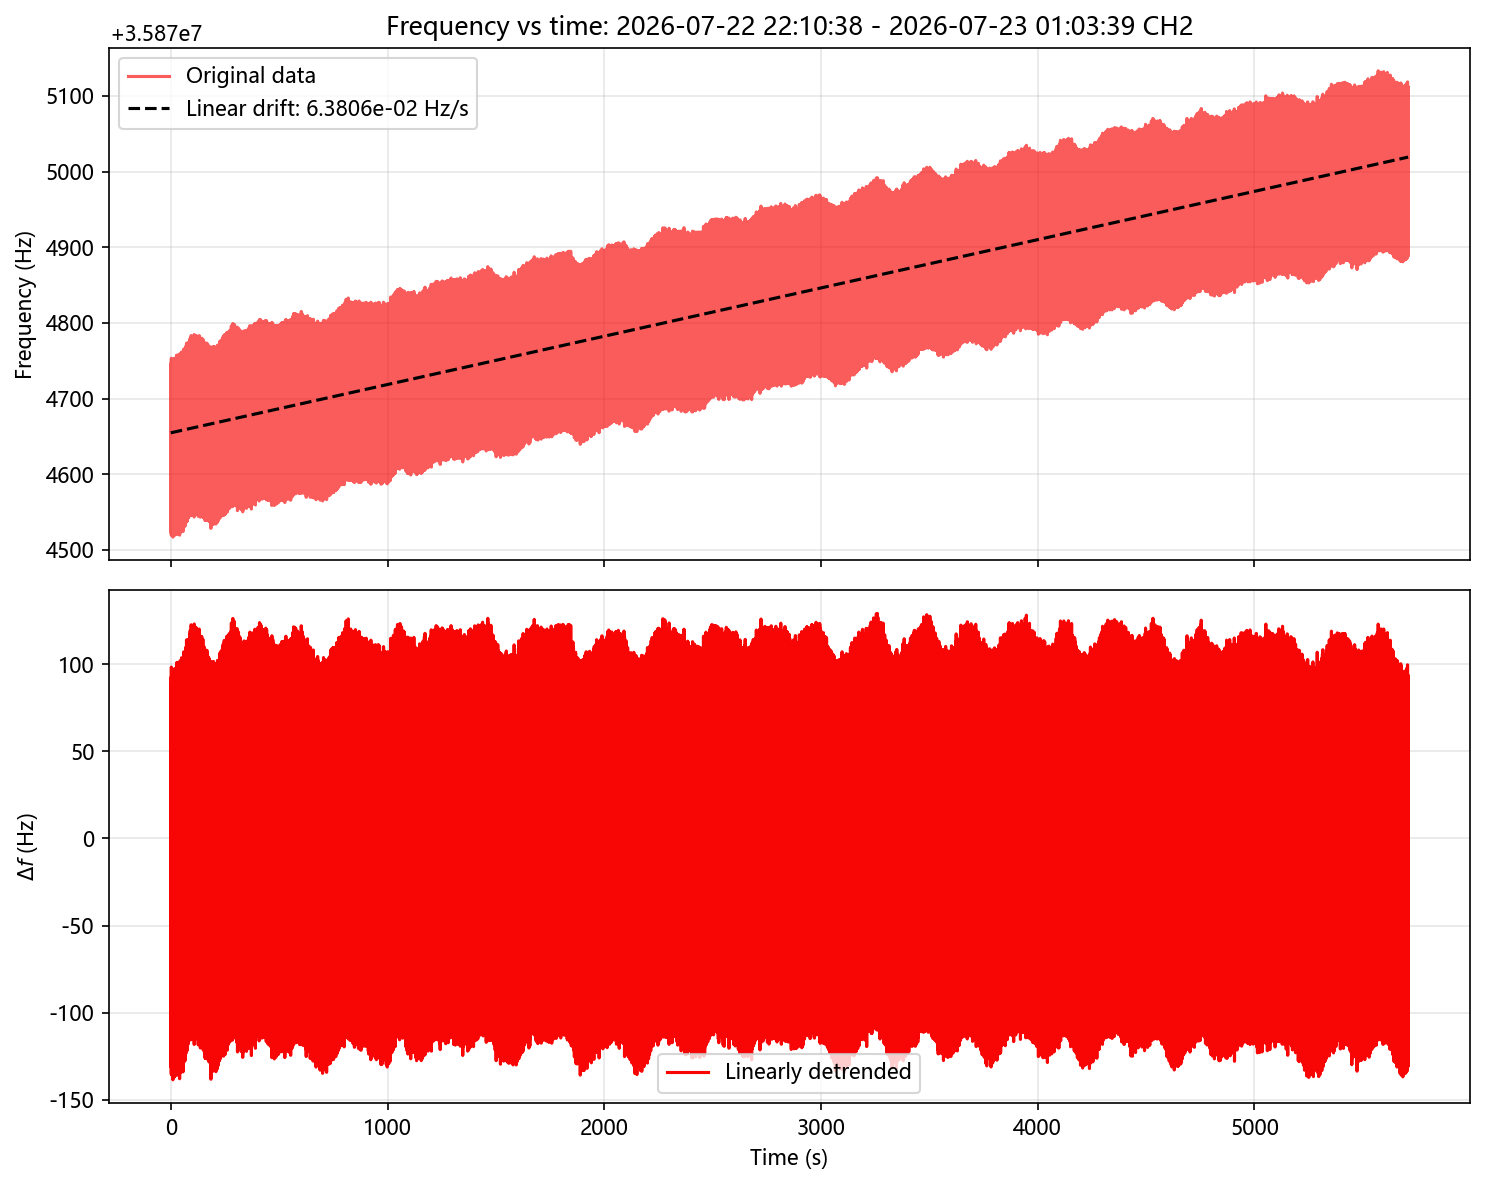

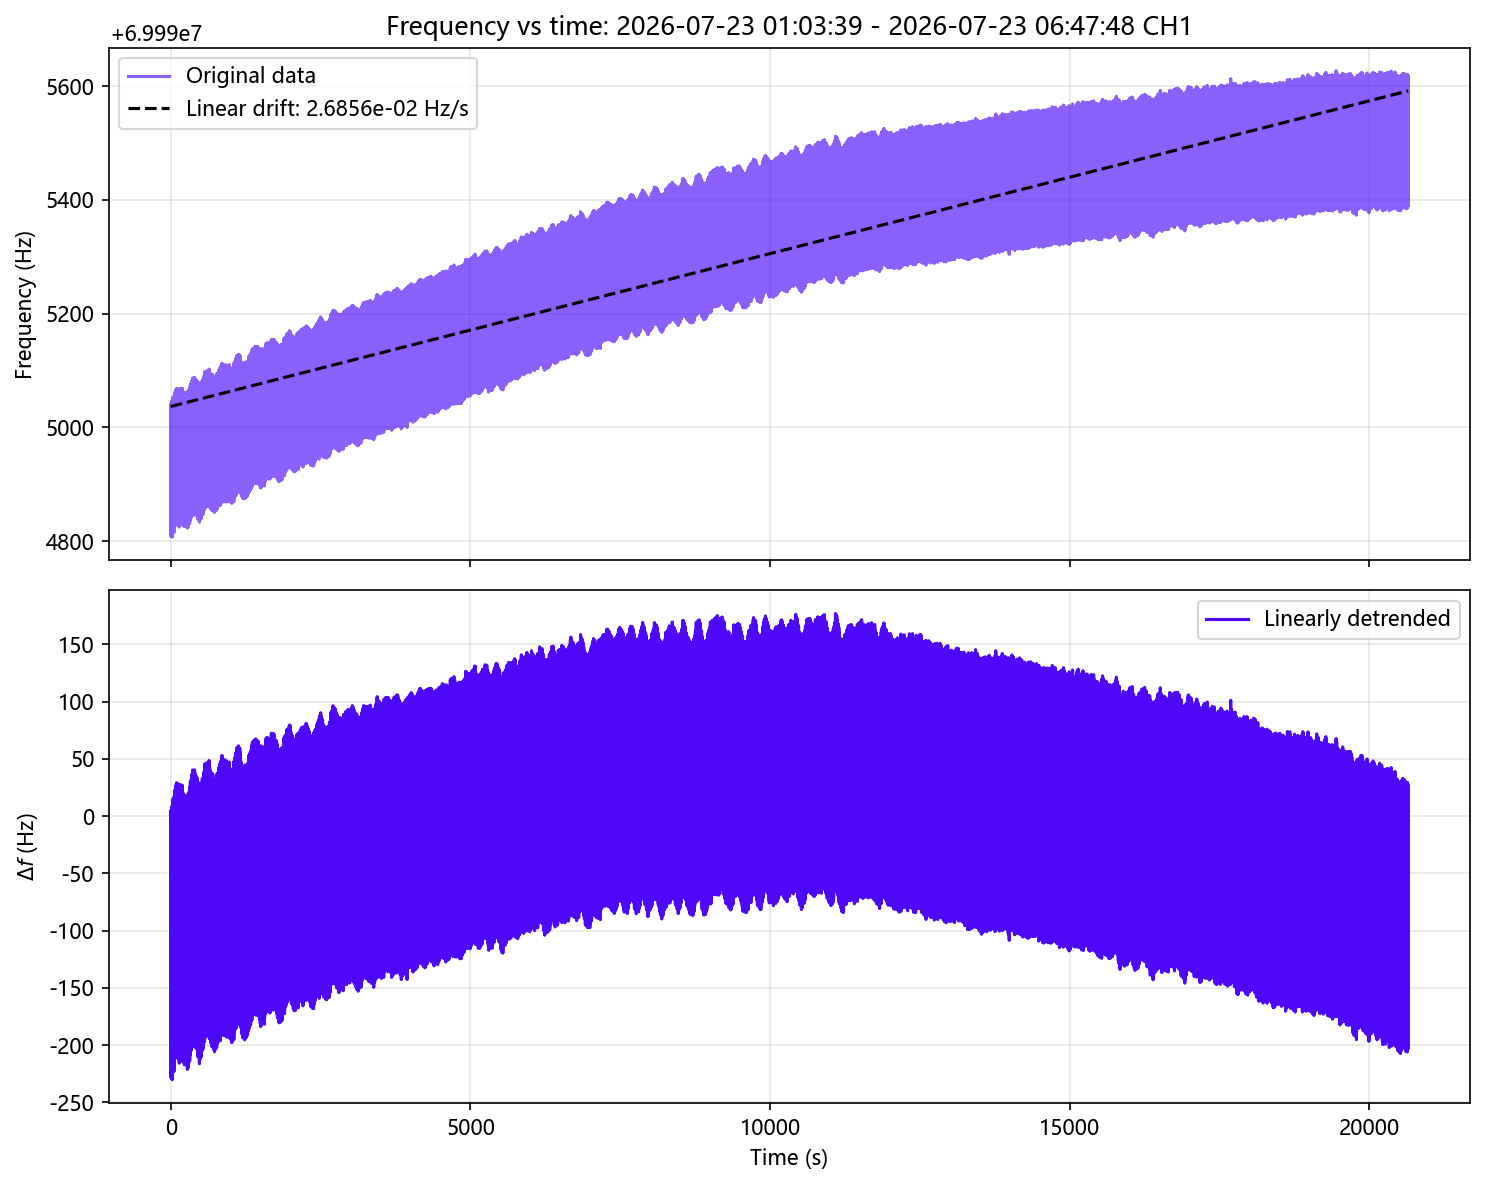

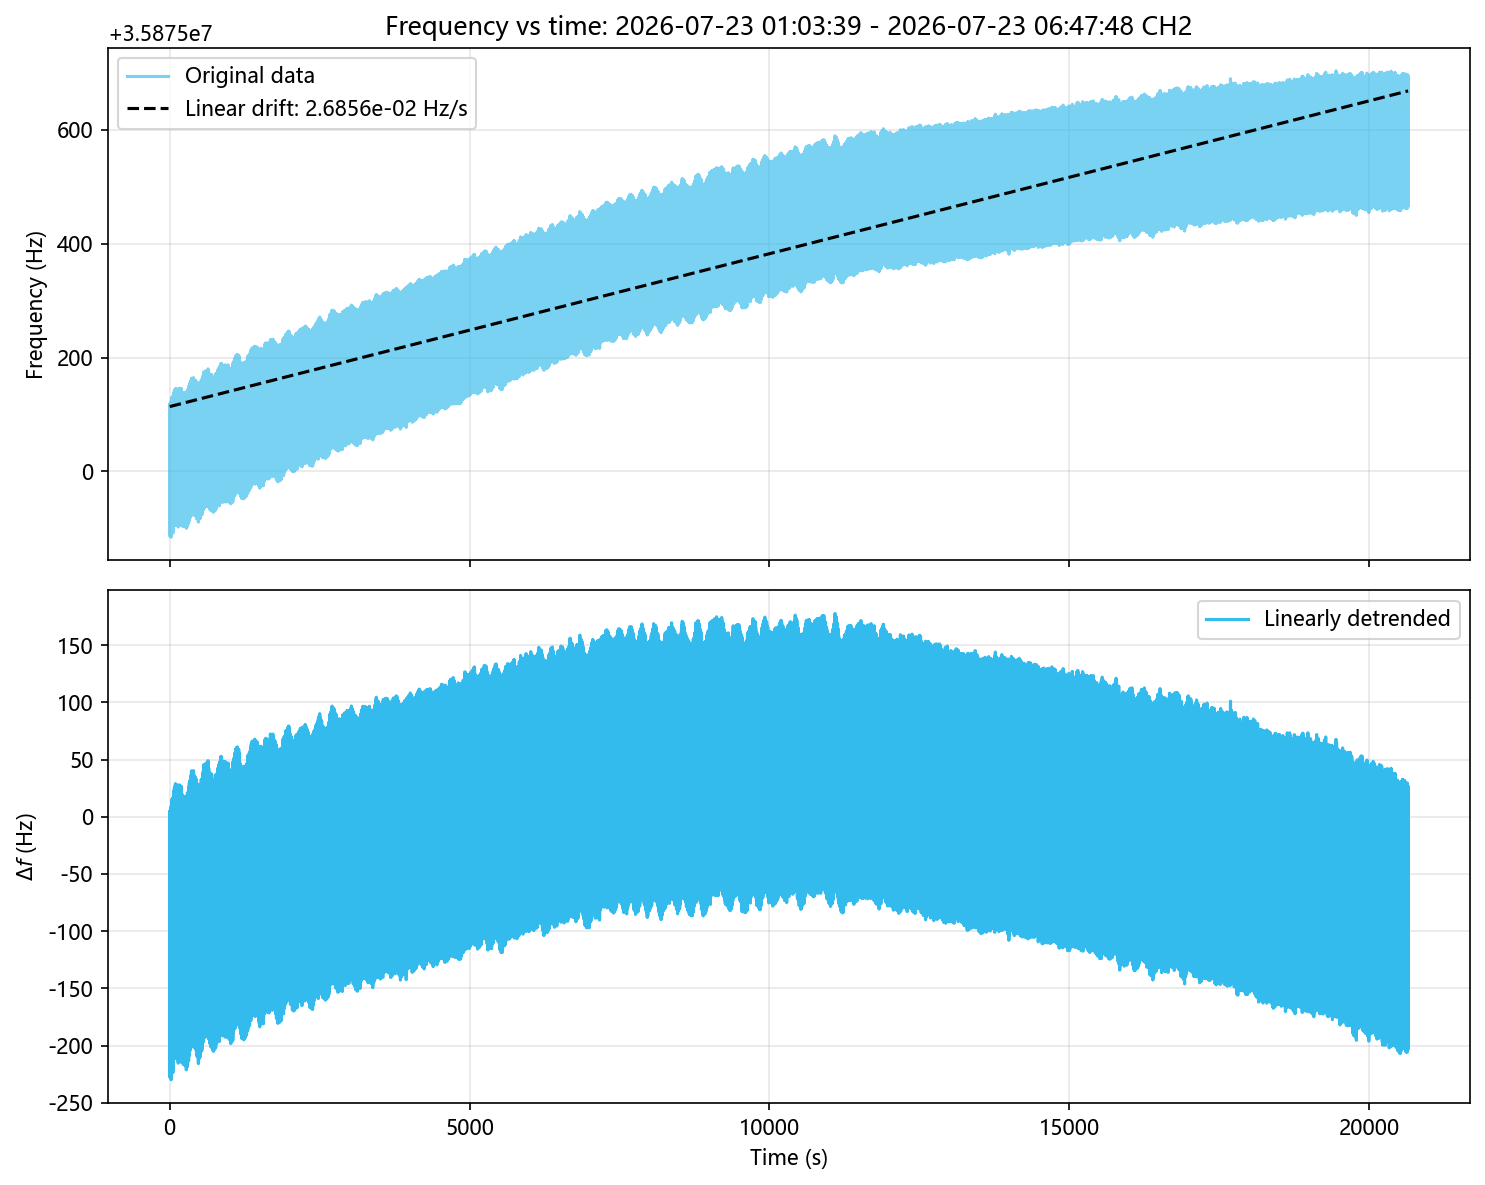

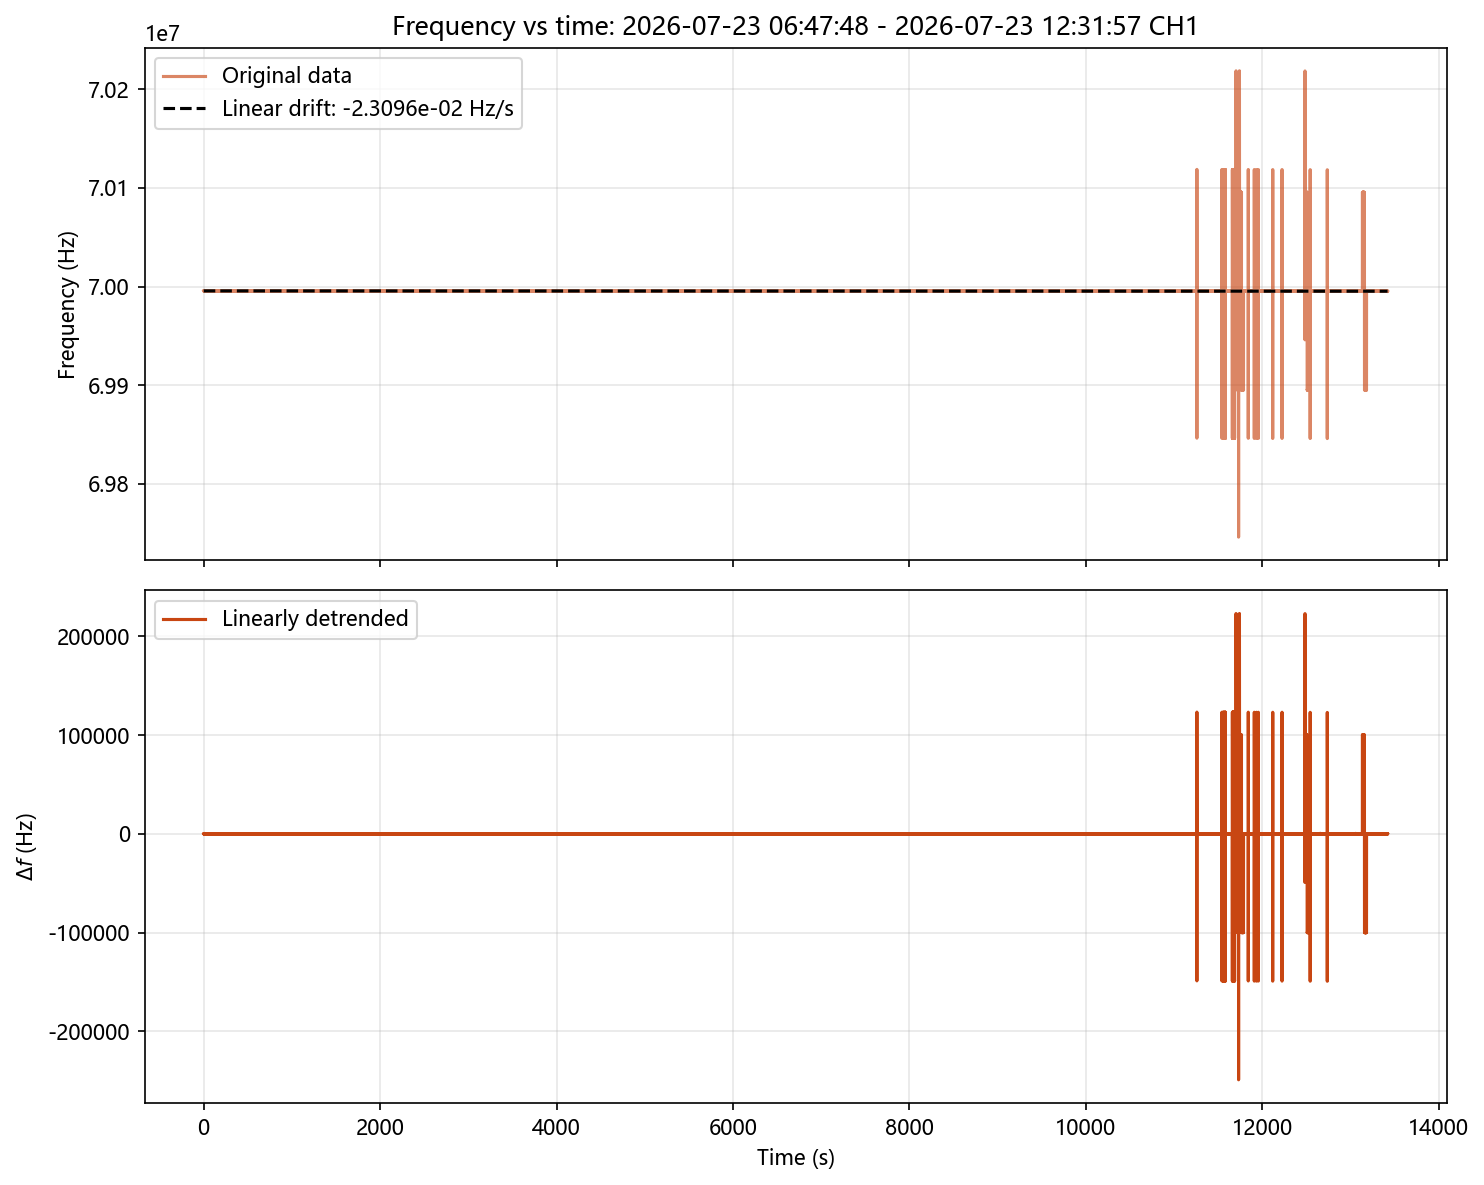

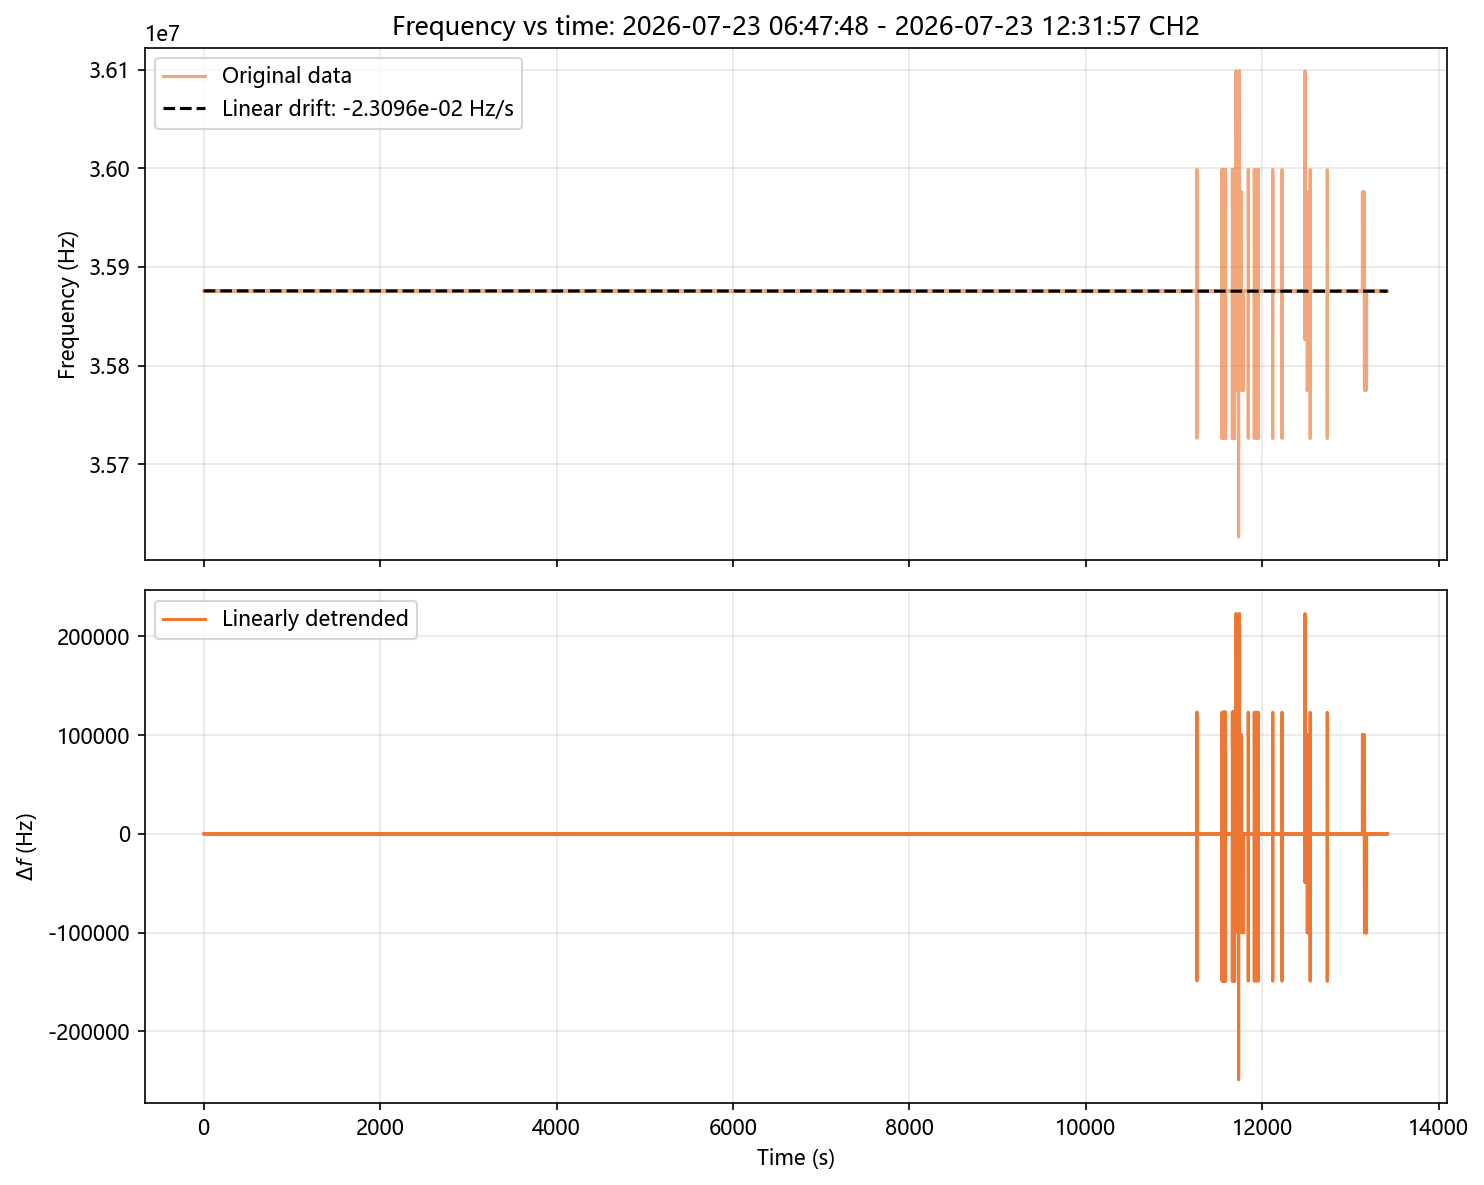

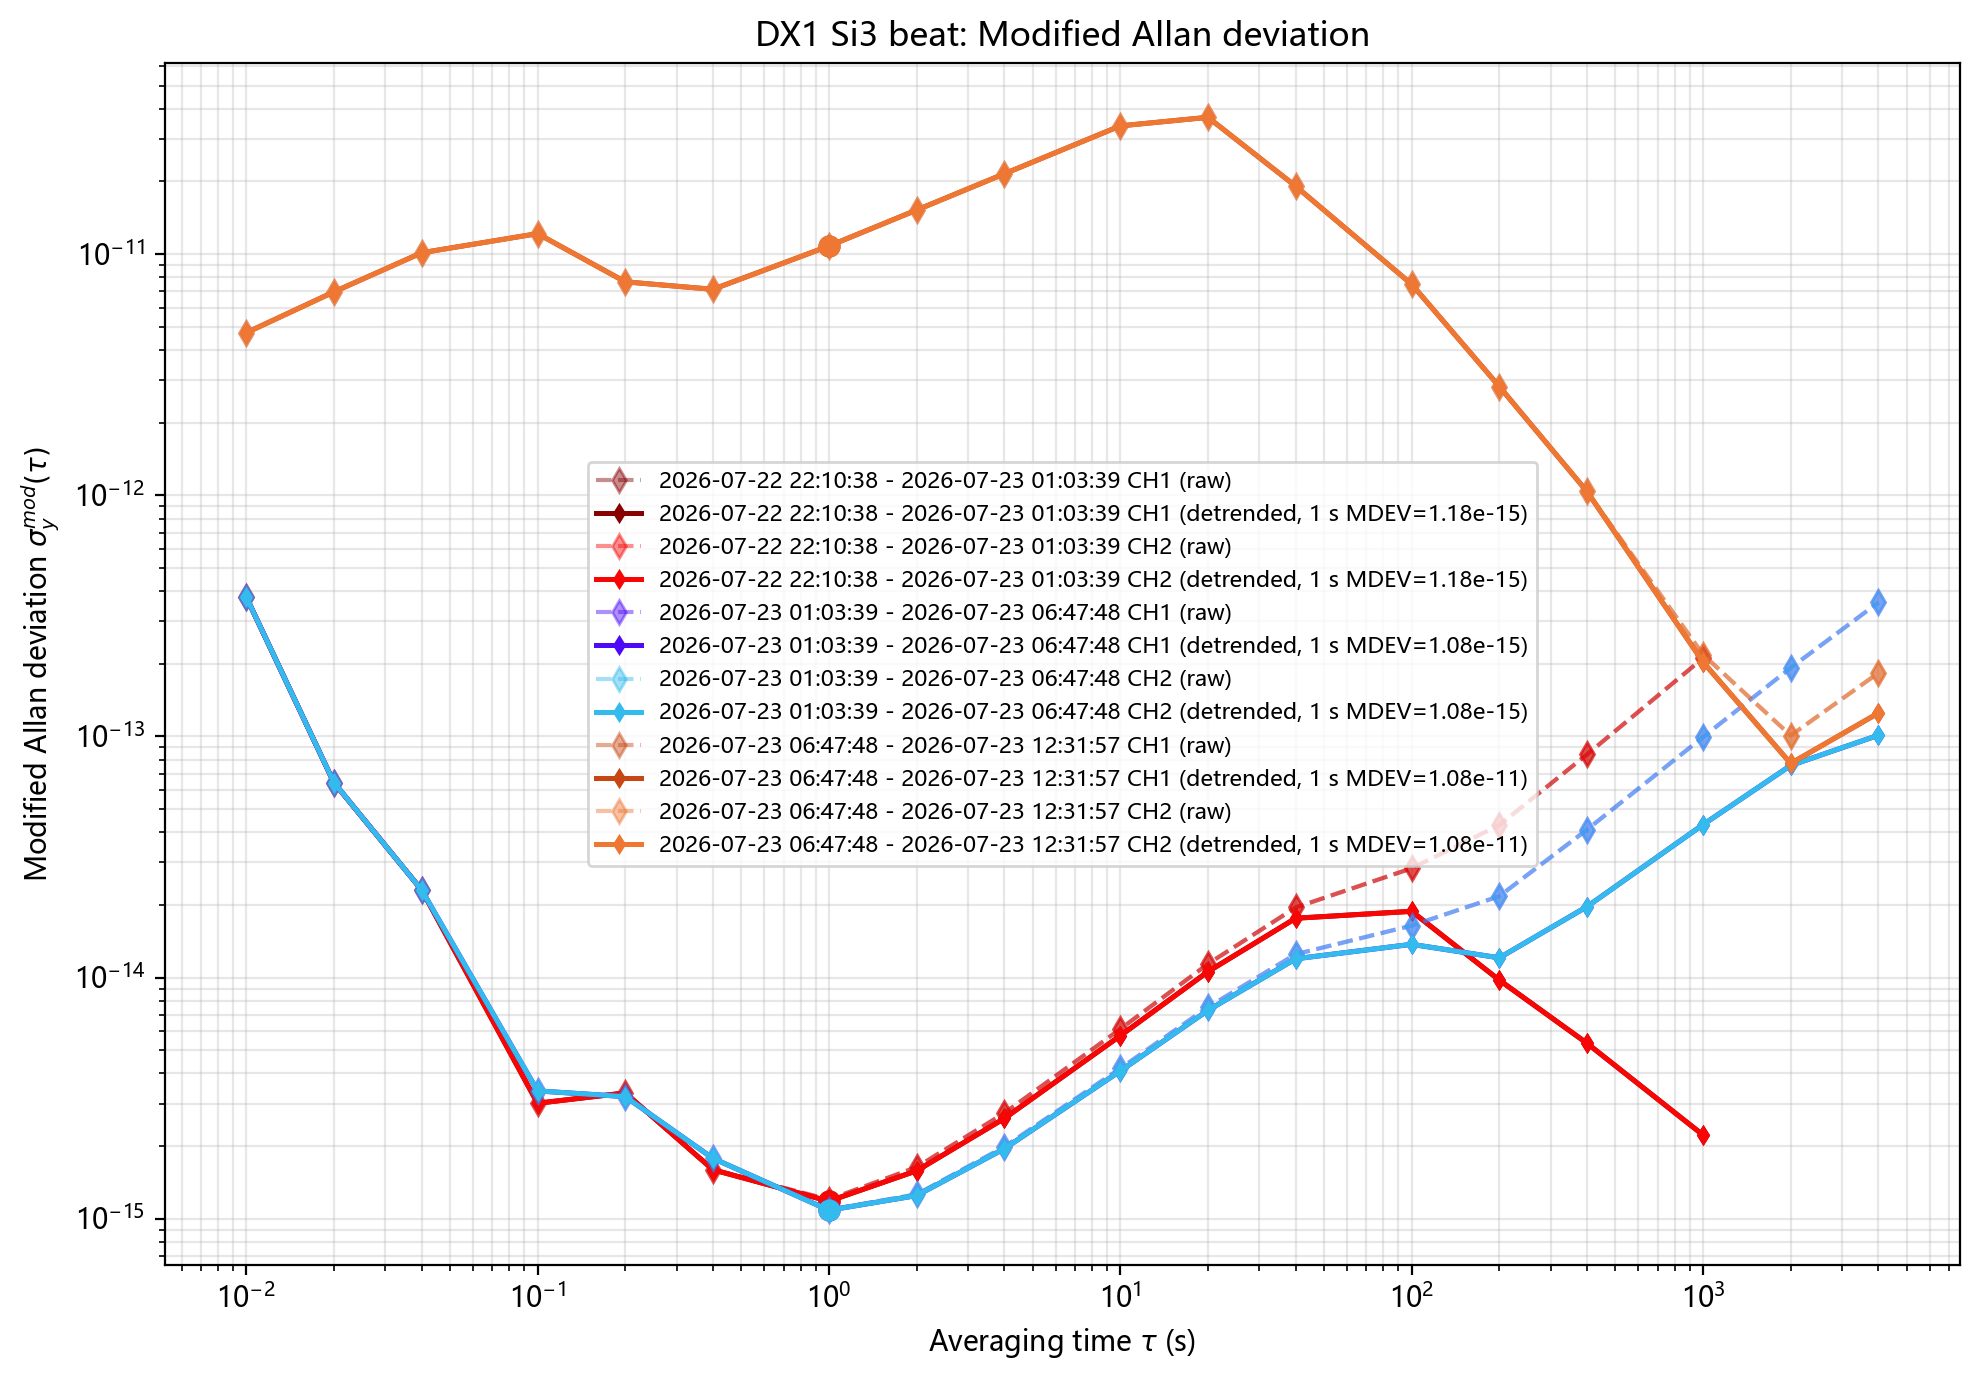

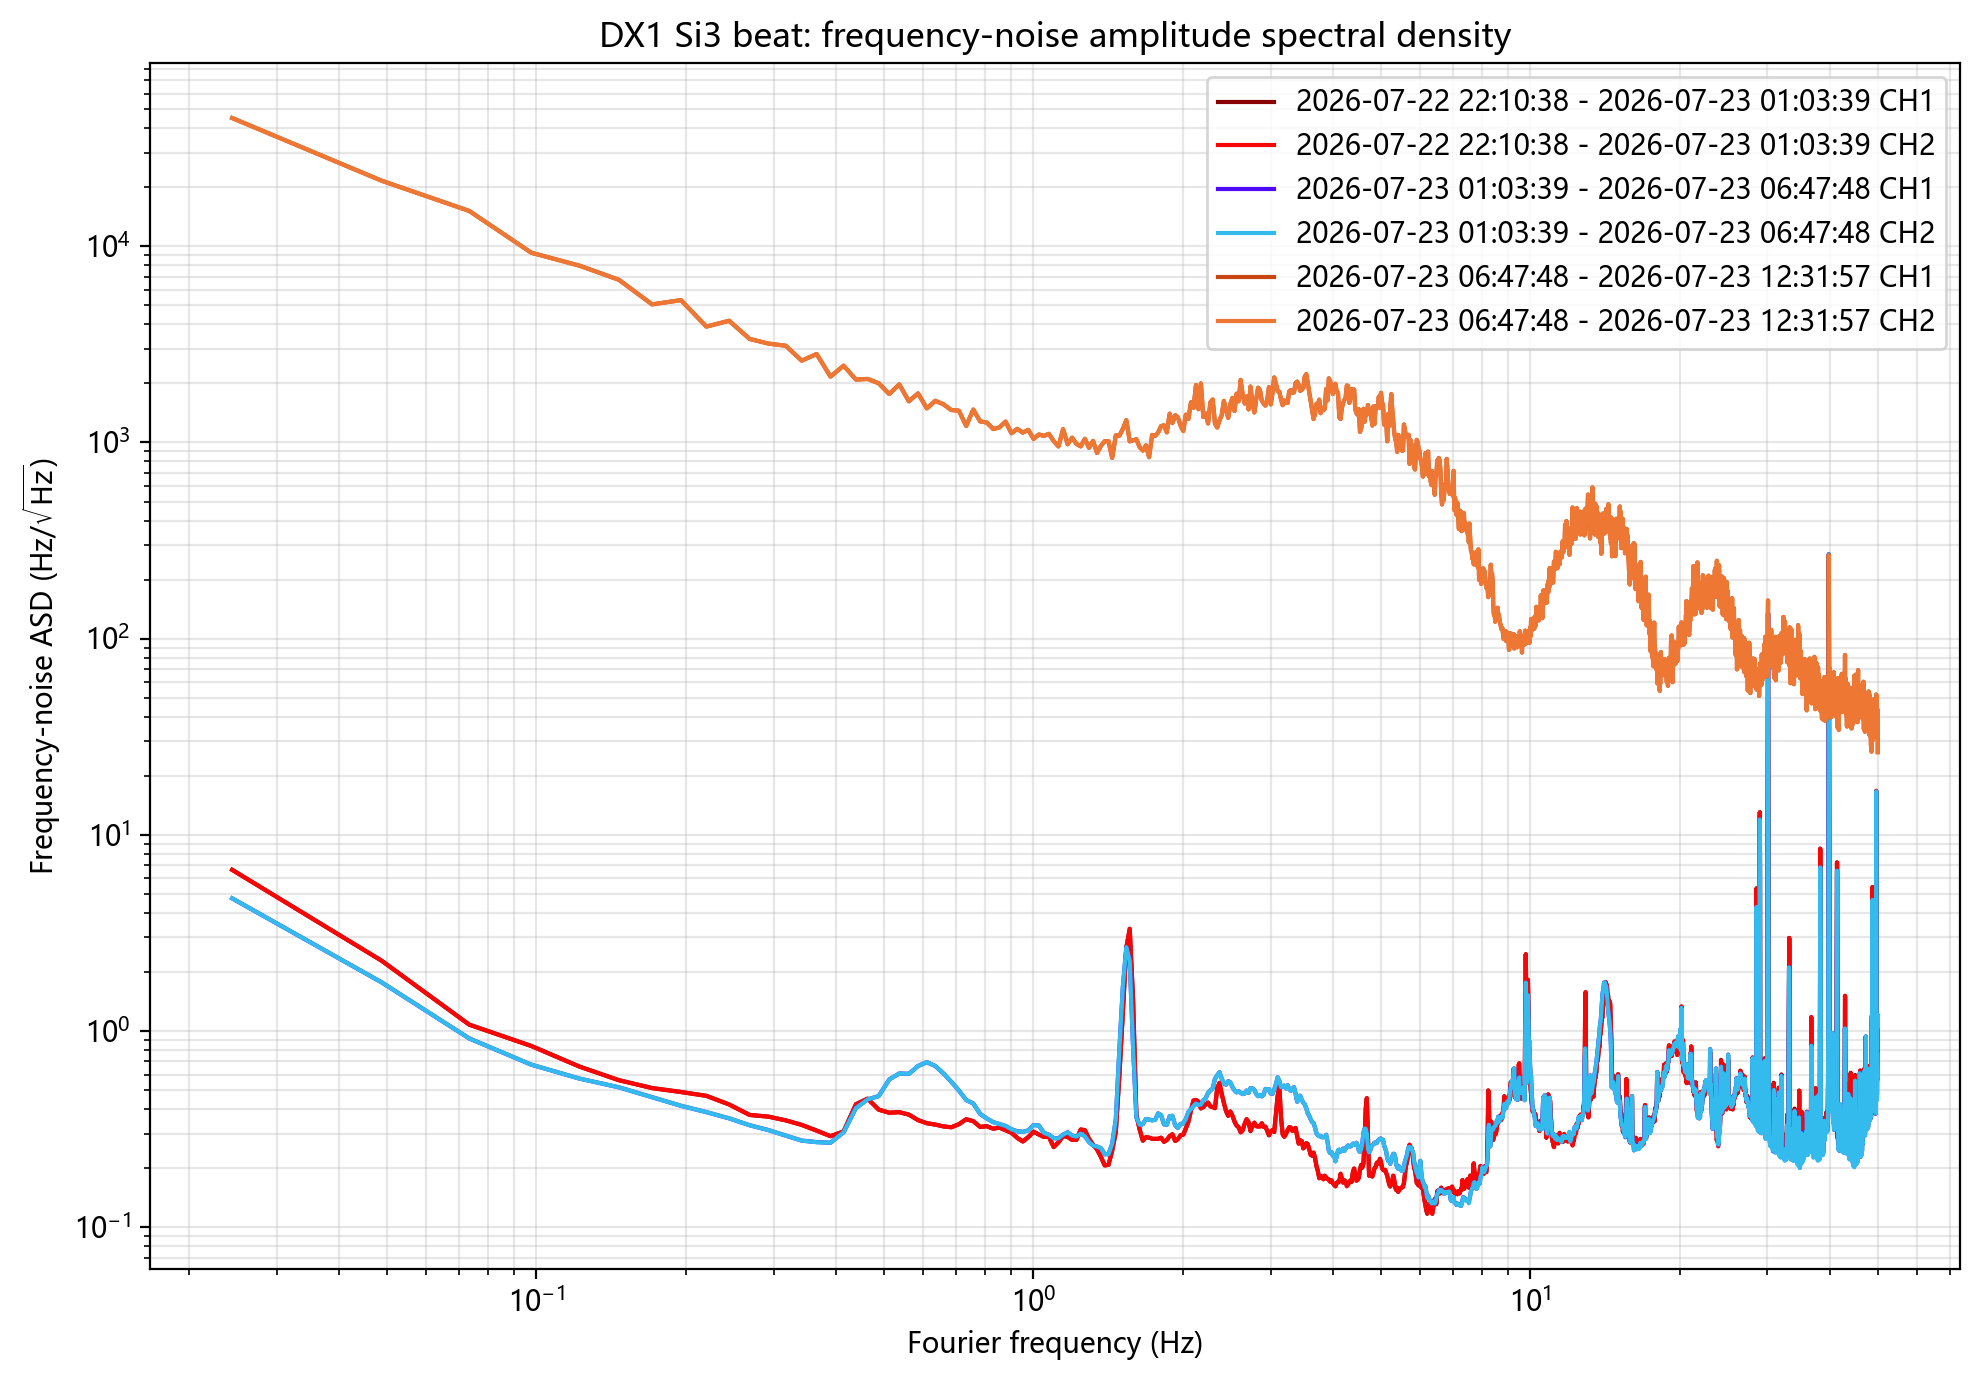

In [6]:
DATA_DIR = FREQUENCY_COUNTER_DATA_ROOT / '20260722-15DX1_Si3_beat'
wavelength_nm = 1397.0
optical_reference_hz = 299792458.0 / (wavelength_nm * 1e-9)
plot_title = 'DX1 Si3 beat'
deviation_type = 'mdev'  # Choose 'adev' or 'mdev'.

data_configs = [
    {
        'file': DATA_DIR / 'Freq_A_1_260722_3.txt',
        'format': 'kk',
        'channels': [1,2],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-22 22:10:38 - 2026-07-23 01:03:39',
        'colors': ['#880000', "#F80505"],
        'tau': 0.01,
        'cut_ratio_lower': 0.45,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    {
        'file': DATA_DIR / 'Freq_A_1_260723_1.txt',
        'format': 'kk',
        'channels': [1, 2],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-23 01:03:39 - 2026-07-23 06:47:48',
        'colors': ["#4D09F8", '#33BBEE'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 1.0,
        'psd_nperseg': 4096,
    },
    {
        'file': DATA_DIR / 'Freq_A_1_260723_2.txt',
        'format': 'kk',
        'channels': [1, 2],  # Use [1, 2] to analyze both K+K channels.
        'label': '2026-07-23 06:47:48 - 2026-07-23 12:31:57',
        'colors': ["#C84612", '#EE7733'],
        'tau': 0.01,
        'cut_ratio_lower': 0.0,
        'cut_ratio_upper': 0.65,
        'psd_nperseg': 4096,
    },
]

results = run_frequency_counter_analysis(
    data_configs=data_configs,
    plot_title=plot_title,
    optical_reference_hz=optical_reference_hz,
    wavelength_nm=wavelength_nm,
    deviation_type=deviation_type,
)